<div style="border:solid Green 2px; border-radius: 10px;  padding: 40px">
<b>Привет, Андрей!👋</b>
    
Меня зовут Зуева Юлия, можно просто Юля 😏 Я буду ревьюером твоего проекта. Предлагаю обращаться на "ты", но если это неудобно, пожалуйста, скажи об этом! 
    
Моя основная цель - помочь тебе стать компетентным Data Scientist'ом: вместе преодолеть трудности и еще больше развить твои сильные навыки 💪 В твоей работе я оставила комментарии, которые должны в этом помочь. Для твоего удобства комментарии раскрашены разными цветами: 
<br/>
<div style="border-radius: 10px" class="alert alert-success">
<b>Отлично ✅:</b> В случае корректного решения (или отдельных его моментов). На такие решения можно опираться в будущем.
</div>
<div style="border-radius: 10px" class="alert alert-warning">
<b>Рекомендации💡:</b> Если есть возможность как-либо улучшить решение. Ты можешь учесть эти комментарии при доработке проекта, однако для зачета это не обязательно.
</div>
<div style="border-radius: 10px" class="alert alert-block alert-danger">
<b>Нужно доработать ❌:</b> Если решение требует внесения правок. Проект не может быть принят, если остались не отработанные комментарии данного типа.
</div>

Чтобы наша с тобой работа была еще эффективнее, ты точно так же можешь оставлять комментарии и задавать мне вопросы. Для таких случаев, пожалуйста, выбери собственное оформление комментариев, которое будет отличаться от моего, чтобы не создавалась путаница. По этой же причине попрошу тебя не удалять и не изменять мои комментарии. Все это позволит лучше ориентироваться в нашем с тобой диалоге, а повторную проверку (в случае ее необходимости) выполнять оперативнее 🚀
    
Не спеши расстраиваться, если что-то не удалось с первого раза. Вместе мы обязательно разберемся со всеми трудностями! 🤓


</span><br><span style="color: purple; font-weight: bold">Привет, Юля!</span>

## https://github.com/2Myaka2/DataScience_projects

### работал в репозитории

# Поведенческий скоринг клиентов банка: прогноз риска просрочки 90+ дней

## Подготовка рабочего пространства

* Дайте этой тетрадке Jupyter название, которое корректно отражает суть проекта.
* Опишите постановку задачи своими словами, коротко зафиксировав основной смысл.
* Опишите данные, которые даны для решения задачи.

## Подготовка рабочего пространства

### Постановка задачи

В рамках проекта решается задача поведенческого скоринга клиентов банка. Необходимо построить модель, которая по данным о клиенте на конкретную дату скоринга будет прогнозировать вероятность возникновения просрочки платежа по кредиту длительностью 90 дней и более.

Объектом моделирования является не клиент в целом, а пара «клиент — месяц наблюдения». Для каждого клиента в каждый месяц необходимо определить, возникнет ли у него просрочка 90+ дней в течение следующих 12 месяцев. Если такая просрочка возникает, целевая переменная принимает значение `1`, если не возникает — `0`.

Практический смысл задачи состоит в том, чтобы заранее выявлять клиентов с повышенным риском дефолта. Это позволит банку точнее управлять кредитным риском, резервами и ликвидностью: не пропускать действительно рискованных клиентов, но при этом не относить к зоне риска слишком большую долю надёжных клиентов.

### Описание данных

Для решения задачи предоставлены несколько таблиц с данными о клиентах, кредитах, транзакциях, просрочках и макроэкономических условиях.

| Таблица | Содержание |
|---|---|
| `ds_15_cohort_grid.csv` | Даты проведения поведенческого скоринга. Содержит идентификатор клиента `ID` и дату скоринга `score_date`. Эта таблица задаёт базовую сетку наблюдений «клиент — месяц». |
| `ds_15_loan_payment_credit.csv` | Данные о просрочках платежей: идентификатор клиента, дата начала периода просрочки и количество дней просрочки. На основе этой таблицы будет формироваться целевая переменная. |
| `ds_15_transactions.csv` | Помесячные транзакции клиента по MCC-кодам: траты в маркетплейсах, фастфуде, ресторанах, супермаркетах, сервисах Яндекса, магазинах бытовой техники, ЖКУ и прочих категориях. |
| `ds_15_client_description.csv` | Социально-демографическое описание клиента на момент регистрации в банке: возраст, семейное положение, наличие иждивенцев, дата регистрации. |
| `ds_15_credit_description.csv` | Описание кредита: месячный доход клиента и сумма выданного кредита. |
| `ds_15_mortgage_presence.csv` | Информация о наличии ипотеки: дата открытия ипотеки и признак наличия ипотеки. |
| `ds_15_credit_rating.csv` | Динамика кредитного рейтинга клиента по датам. |
| `ds_15_macro_data.csv` | Макроэкономические показатели по месяцам: учётная ставка, уровень безработицы и инфляция. |

Перед моделированием все источники данных будут объединены в единую таблицу наблюдений. При объединении будет важно учитывать временную структуру данных: в признаках для каждой строки должны использоваться только те данные, которые были доступны на дату скоринга.

## Перевод бизнес-задачи на язык машинного обучения

* Напишите, что конкретно будете делать, пользуясь терминами машинного обучения:
  * какие модели будете использовать;
  * какие методы работы с данными применять;
  * как планируете решать поставленную задачу.


## Перевод бизнес-задачи на язык машинного обучения

С точки зрения машинного обучения задача является задачей бинарной классификации.

Для каждой строки итоговой таблицы, соответствующей клиенту в конкретный месяц, необходимо предсказать целевую переменную:

- `1` — в течение следующих 12 месяцев у клиента возникнет просрочка платежа длительностью 90 дней и более;
- `0` — в течение следующих 12 месяцев такой просрочки не возникнет.

В качестве признаков будут использоваться социально-демографические характеристики клиента, параметры кредита, история транзакций, сведения об ипотеке, динамика кредитного рейтинга, информация о текущих и прошлых просрочках, а также макроэкономические показатели.

### План решения

Сначала будет проведена загрузка и первичный анализ всех таблиц: проверка типов данных, пропусков, дубликатов, выбросов и временных диапазонов. После этого будет сформирована единая таблица наблюдений на основе `cohort_grid`, где каждая строка соответствует паре «клиент — дата скоринга».

Особое внимание будет уделено корректному формированию целевой переменной. Для каждой даты скоринга будет проверяться, возникла ли у клиента просрочка 90+ дней в течение следующих 12 месяцев. При этом признаки должны строиться только на основе информации, доступной на момент скоринга, чтобы избежать утечки данных из будущего.

Для повышения качества модели будут созданы дополнительные признаки, например:

- отношение суммы кредита к доходу клиента;
- срок жизни клиента в банке на дату скоринга;
- агрегированные признаки по транзакциям;
- признаки динамики кредитного рейтинга;
- признаки, связанные с наличием ипотеки и семейной нагрузкой.

После подготовки данных будет проанализирован баланс классов в целевой переменной. Так как дефолты обычно встречаются существенно реже, чем нормальные платежи, задача, вероятно, будет несбалансированной. Поэтому будут рассмотрены методы балансировки классов: `class_weight`, `RandomOverSampler`, `RandomUnderSampler` или `SMOTE`.

### Модели

На базовом этапе будут обучены и сравнены несколько вариантов моделей:

1. логистическая регрессия без балансировки классов;
2. случайный лес без балансировки классов;
3. логистическая регрессия с балансировкой классов;
4. случайный лес с балансировкой классов.

Для итогового решения будет использована ансамблевая модель `RandomForestClassifier`, так как она способна учитывать нелинейные зависимости между признаками, работает с признаками разного масштаба и позволяет оценить важность признаков через `feature_importances_`.

Подбор гиперпараметров итоговой модели будет выполнен с помощью `Optuna`. Для валидации будет использоваться кросс-валидация на трёх фолдах с учётом временной структуры данных и группировки по клиентам через `GroupTimeSeriesSplit`.

### Оценка качества

Качество моделей будет оцениваться как техническими, так и бизнес-метриками.

В качестве технической метрики для сравнения моделей будет использоваться ROC-AUC или accuracy. Однако основное внимание будет уделено бизнес-метрикам:

- `approval rate` — доля клиентов, которых модель считает надёжными;
- `default rate` — доля фактических дефолтов среди клиентов, признанных моделью надёжными;
- `missed defaults rate` — доля дефолтов, которые модель пропустила.

После обучения лучшей модели будет проведена калибровка вероятностей на отдельной калибровочной выборке. Затем будет подобран порог классификации, при котором одновременно выполняются бизнес-ограничения:

- `approval rate` не менее 65%;
- `default rate` не более 2%;
- `missed defaults rate` не более 4%.

Финальная проверка качества будет выполнена на тестовой выборке, которая не будет использоваться ни при обучении модели, ни при подборе гиперпараметров, ни при калибровке, ни при выборе порога. Это позволит оценить, насколько стабильно модель работает на новых данных.

<div style="border:solid #D3D3D3 2px; border-radius: 10px; padding: 15px">
<h3> Комментарий ревьюера <a class="tocSkip"></h3>
<h4> Вводная часть <a class="tocSkip"></h4>

<div style="border-radius: 10px" class="alert alert-success">
<b>Отлично ✅:</b> 
    
Здорово, что оформляешь вводную часть проекта. Она помогает быстро понять цель, контекст и структуру работы - это удобно и для тебя при возвращении к проекту спустя время, и для любого другого читателя, особенно если проект публикуется в портфолио или используется как пример практической работы. Полезно воспринимать такую тетрадку не просто как выполнение домашнего задания, а как полноценный исследовательский или аналитический проект. 
    
<br/>
    
<details> <summary> <span style='color:blue' > Что обычно отмечают во введении (тык) </span> </summary>

* название и краткое описание проблемы, которую хотим решить, бизнес-контекст;
* постановку задачи и формулирование цели исследования, ожидаемого результата и практической ценности;
* описание данных: источник, объем, период, основные особенности и ограничения;
* используемые подходы, инструменты или методы анализа;
* важные допущения, ограничения и особенности поставленной задачи;
* краткий план работы и основные этапы исследования.

</details>
    
По сути, вводная часть отвечает на несколько базовых вопросов: что мы делаем, зачем, с какими данными работаем, какими методами будем решать задачу и в каких условиях проводится анализ. Хорошо оформленное введение делает проект более цельным, профессиональным и значительно упрощает навигацию по работе.

</div>

## Загрузка необходимых библиотек

* Загрузите все библиотеки, необходимые для выполнения проекта.

In [1]:
%%writefile requirements.txt
numpy==1.26.4
pandas==2.2.3
scipy==1.13.1

scikit-learn==1.6.1
imbalanced-learn==0.13.0
mlxtend==0.23.4

matplotlib==3.10.8
seaborn==0.13.2
phik==0.12.4

joblib==1.5.3
ipykernel==6.29.5
optuna==4.4.0

Overwriting requirements.txt


In [2]:
%pip install -q -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [3]:
# Базовые библиотеки
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import joblib

# Визуализация
import matplotlib.pyplot as plt
import seaborn as sns

# Корреляционный анализ
import phik

# sklearn: базовые инструменты
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# Кросс-валидация с учётом групп и времени
from mlxtend.evaluate import GroupTimeSeriesSplit

# sklearn: предобработка
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# sklearn: признаки
from sklearn.feature_selection import VarianceThreshold

# sklearn: модели классификации
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Балансировка классов
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.under_sampling import RandomUnderSampler

# sklearn: калибровка вероятностей
from sklearn.calibration import CalibratedClassifierCV, calibration_curve

# sklearn: метрики классификации
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    brier_score_loss
)

# Optuna
import optuna
from optuna.samplers import TPESampler

# Настройки отображения
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:.3f}".format)

sns.set_theme(style="whitegrid")

# Константы проекта
RANDOM_STATE = 42
CV_FOLDS = 3

TARGET = "target"
ID_COL = "ID"
SCORE_DATE_COL = "score_date"

DEFAULT_START_COL = "дата_начала_периода"
DEFAULT_DAYS_COL = "просрочка_дней"

HORIZON_MONTHS = 12
CALIBRATION_MONTHS = 12
TEST_MONTHS = 12
DEFAULT_DAYS_THRESHOLD = 90

# Бизнес-ограничения по итоговому порогу
MIN_APPROVAL_RATE = 0.65
MAX_DEFAULT_RATE = 0.02
MAX_MISSED_DEFAULTS_RATE = 0.04

# Пути к данным
DATA_DIR = Path("datasets")

/home/andre/DS/DataScience_projects/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<div style="border:solid #D3D3D3 2px; border-radius: 10px; padding: 15px">
<h3> Комментарий ревьюера <a class="tocSkip"></h3>
<h4> Импорты <a class="tocSkip"></h4>

<div style="border-radius: 10px" class="alert alert-success">
<b>Отлично ✅:</b> 
    
* Здорово, что все необходимые библиотеки подгружаешь сразу в начале проекта! Это соответствует стандартам оформления кода <a href='https://pyplanet.ru/article/pep-0008.html'>PEP 8</a>. Такой подход позволяет сразу видеть, какое окружение необходимо для запуска проекта, избежать дублирования импортов в разных частях кода, а также облегчить отладку и переносимость проекта.


* Упорядочивание импортов является хорошей практикой! PEP 8 рекомендует сначала подгружать стандартные python-библиотеки, затем сторонние. Но для удобства каждую их этих групп также можно структурировать по тематике. Например, библиотеки для работы с данными, для работы с графиками и т.д. Так удобнее поддерживать порядок в импортах от проекта к проекту, не подгружать лишнее.

</div>

<div style="border-radius: 10px" class="alert alert-warning">
    
<b>Рекомендации💡:</b> 

* Напомню, что перед отправкой проекта важно сбрасывать ядро (очищать память от созданных объектов) и заново запускать проект с самого начала, чтобы проверить на наличие ошибок в коде при последовательном исполнении ячеек. Сейчас этого сделано не было, нумерация ячеек начинается не с 1, идет непоследовательно.


* Чтобы при установке новой библиотеки не выводилась информация о процессе и зависимостях, можно добавлять опцию `--quiet` или просто `-q`.
    
</div>


</span><br><span style="color: purple; font-weight: bold">Поправил!</span>

## Загрузка данных

* Загрузите предоставленные датасеты. Обратите внимание на то, как загрузятся данные, в каком формате представлены таблицы. Пути к данным:
  * `'/datasets/ds_15_loan_payment_credit.csv'`;
  * `'/datasets/ds_15_transactions.csv'`;
  * `'/datasets/ds_15_client_description.csv'`;
  * `'/datasets/ds_15_credit_description.csv'`;
  * `'/datasets/ds_15_mortgage_presence.csv'`;
  * `'/datasets/ds_15_credit_rating.csv'`;
  * `'/datasets/ds_15_macro_data.csv'`;
  * `'/datasets/ds_15_cohort_grid.csv'`.
* Посмотрите на содержимое таблиц. Сделайте первые выводы о них.

In [4]:
REMOTE_DATA_URL = "https://code.s3.yandex.net/datasets/"

file_names = {
    "cohort_grid": "ds_15_cohort_grid.csv",
    "loan_payment_credit": "ds_15_loan_payment_credit.csv",
    "transactions": "ds_15_transactions.csv",
    "client_description": "ds_15_client_description.csv",
    "credit_description": "ds_15_credit_description.csv",
    "mortgage_presence": "ds_15_mortgage_presence.csv",
    "credit_rating": "ds_15_credit_rating.csv",
    "macro_data": "ds_15_macro_data.csv",
}

dataframes = {}

for name, file_name in file_names.items():
    local_path = DATA_DIR / file_name                  # локальная папка проекта
    practicum_path = Path("/datasets") / file_name     # путь на платформе Практикума
    remote_path = REMOTE_DATA_URL + file_name          # удалённый путь
    
    try:
        dataframes[name] = pd.read_csv(local_path)
        print(f"{name}: загружен из локальной папки {local_path}")
    except FileNotFoundError:
        try:
            dataframes[name] = pd.read_csv(practicum_path)
            print(f"{name}: загружен из папки Практикума {practicum_path}")
        except FileNotFoundError:
            dataframes[name] = pd.read_csv(remote_path)
            print(f"{name}: загружен из удалённого хранилища")

cohort_grid: загружен из локальной папки datasets/ds_15_cohort_grid.csv
loan_payment_credit: загружен из локальной папки datasets/ds_15_loan_payment_credit.csv
transactions: загружен из локальной папки datasets/ds_15_transactions.csv
client_description: загружен из локальной папки datasets/ds_15_client_description.csv
credit_description: загружен из локальной папки datasets/ds_15_credit_description.csv
mortgage_presence: загружен из локальной папки datasets/ds_15_mortgage_presence.csv
credit_rating: загружен из локальной папки datasets/ds_15_credit_rating.csv
macro_data: загружен из локальной папки datasets/ds_15_macro_data.csv


In [5]:
cohort_grid = dataframes["cohort_grid"]
loan_payment_credit = dataframes["loan_payment_credit"]
transactions = dataframes["transactions"]
client_description = dataframes["client_description"]
credit_description = dataframes["credit_description"]
mortgage_presence = dataframes["mortgage_presence"]
credit_rating = dataframes["credit_rating"]
macro_data = dataframes["macro_data"]

In [6]:
# Словарь с исходными таблицами проекта
df_mains = {
    "cohort_grid": cohort_grid,
    "loan_payment_credit": loan_payment_credit,
    "transactions": transactions,
    "client_description": client_description,
    "credit_description": credit_description,
    "mortgage_presence": mortgage_presence,
    "credit_rating": credit_rating,
    "macro_data": macro_data,
}

In [7]:
def show_df_info(name, df, head_rows=5):
    print("=" * 100)
    print(f"Датасет: {name}")
    print("=" * 100)

    print("\nИнформация о типах данных:")
    df.info()

    print("\nПервые строки:")
    display(df.head(head_rows))

    print("\nСводка по столбцам:")
    columns_info = pd.DataFrame({
        "column": df.columns,
        "dtype": df.dtypes.astype(str).values,
        "non_null_values": df.notna().sum().values,
        "missing_values": df.isna().sum().values,
        "missing_percent": (df.isna().mean() * 100).round(2).values,
        "unique_values": df.nunique(dropna=False).values,
    })

    display(columns_info)

    print("\nПропуски:")
    missing_info = columns_info[columns_info["missing_values"] > 0].copy()

    if missing_info.empty:
        print("Пропусков не обнаружено.")
    else:
        display(
            missing_info[
                ["column", "missing_values", "missing_percent"]
            ].sort_values("missing_percent", ascending=False)
        )

    print("\nКоличество явных дубликатов:")
    duplicated_count = df.duplicated().sum()
    duplicated_percent = duplicated_count / len(df) * 100 if len(df) > 0 else 0
    print(f"{duplicated_count} строк ({duplicated_percent:.2f}%)")

    if ID_COL in df.columns:
        print("\nИнформация по ID:")
        print(f"Уникальных клиентов: {df[ID_COL].nunique()}")
        print(f"Всего строк: {len(df)}")
        print(f"Среднее количество строк на клиента: {len(df) / df[ID_COL].nunique():.2f}")

    date_like_columns = [
        col for col in df.columns
        if col.lower() in ["date", "score_date"] or "дата" in col.lower()
    ]

    if date_like_columns:
        print("\nПроверка столбцов с датами:")
        for col in date_like_columns:
            parsed_dates = pd.to_datetime(df[col], errors="coerce")
            parse_errors = parsed_dates.isna().sum() - df[col].isna().sum()

            print(f"\nСтолбец: {col}")
            print(f"Минимальная дата: {parsed_dates.min()}")
            print(f"Максимальная дата: {parsed_dates.max()}")
            print(f"Не удалось распарсить значений: {parse_errors}")

    numeric_columns = df.select_dtypes(include=np.number).columns

    if len(numeric_columns) > 0:
        print("\nОписательная статистика по числовым признакам:")
        display(df[numeric_columns].describe().T)

    categorical_columns = df.select_dtypes(include=["object", "category", "bool"]).columns

    low_cardinality_info = []

    for col in categorical_columns:
        unique_count = df[col].nunique(dropna=False)

        if unique_count <= 20:
            values = df[col].dropna().unique().tolist()
            low_cardinality_info.append({
                "column": col,
                "unique_values_count": unique_count,
                "values": values,
            })

    if low_cardinality_info:
        print("\nКатегориальные признаки с небольшим числом уникальных значений:")
        display(pd.DataFrame(low_cardinality_info))

    print("\n")

    return {
        "dataset": name,
        "rows": df.shape[0],
        "columns": df.shape[1],
        "missing_total": df.isna().sum().sum(),
        "duplicated_rows": duplicated_count,
        "memory_mb": df.memory_usage(deep=True).sum() / 1024**2,
    }

In [8]:
datasets_summary = []

for name, df in df_mains.items():
    summary = show_df_info(name, df)
    datasets_summary.append(summary)

datasets_summary = pd.DataFrame(datasets_summary)

print("=" * 100)
print("Общая сводка по исходным таблицам")
print("=" * 100)

display(datasets_summary)

Датасет: cohort_grid

Информация о типах данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 577494 entries, 0 to 577493
Data columns (total 2 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   ID          577494 non-null  object
 1   score_date  577494 non-null  object
dtypes: object(2)
memory usage: 8.8+ MB

Первые строки:


,ID,score_date
0,IDF55109846,2013-05-01
1,IDF55109846,2013-06-01
2,IDF55109846,2013-07-01
3,IDF55109846,2013-08-01
4,IDF55109846,2013-09-01



Сводка по столбцам:


,column,dtype,non_null_values,missing_values,missing_percent,unique_values
0,ID,object,577494,0,0.000,13500
1,score_date,object,577494,0,0.000,84



Пропуски:
Пропусков не обнаружено.

Количество явных дубликатов:
0 строк (0.00%)

Информация по ID:
Уникальных клиентов: 13500
Всего строк: 577494
Среднее количество строк на клиента: 42.78

Проверка столбцов с датами:

Столбец: score_date
Минимальная дата: 2013-01-01 00:00:00
Максимальная дата: 2019-12-01 00:00:00
Не удалось распарсить значений: 0


Датасет: loan_payment_credit

Информация о типах данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5500 entries, 0 to 5499
Data columns (total 3 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   ID                   5500 non-null   object
 1   дата_начала_периода  5500 non-null   object
 2   просрочка_дней       5500 non-null   int64 
dtypes: int64(1), object(2)
memory usage: 129.0+ KB

Первые строки:


...

,column,dtype,non_null_values,missing_values,missing_percent,unique_values
0,date,object,84,0,0.000,84
1,учетная_ставка,float64,84,0,0.000,40
2,уровень_безработицы,float64,84,0,0.000,18
3,инфляция,float64,84,0,0.000,62



Пропуски:
Пропусков не обнаружено.

Количество явных дубликатов:
0 строк (0.00%)

Проверка столбцов с датами:

Столбец: date
Минимальная дата: 2013-01-01 00:00:00
Максимальная дата: 2019-12-01 00:00:00
Не удалось распарсить значений: 0

Описательная статистика по числовым признакам:


,count,mean,std,min,25%,50%,75%,max
учетная_ставка,84.000,8.639,2.466,5.500,7.250,7.750,10.330,17.000
уровень_безработицы,84.000,5.175,0.409,4.300,4.900,5.200,5.500,6.000
инфляция,84.000,0.528,0.570,-0.540,0.263,0.425,0.635,3.850




Общая сводка по исходным таблицам


,dataset,rows,columns,missing_total,duplicated_rows,memory_mb
0,cohort_grid,577494,2,0,0,65.538
1,loan_payment_credit,5500,3,0,0,0.666
2,transactions,577494,10,0,0,100.786
3,client_description,13500,5,0,0,3.107
4,credit_description,13500,3,0,0,0.979
5,mortgage_presence,6609,3,0,0,0.801
6,credit_rating,577494,3,0,0,69.944
7,macro_data,84,4,0,0,0.007


### Вывод по первичному анализу исходных таблиц

На этапе первичного анализа были загружены и проверены 8 исходных таблиц проекта. В данных не обнаружено явных дубликатов и пропусков: во всех таблицах количество пропущенных значений равно нулю. Это упрощает дальнейшую предобработку, однако часть дат сейчас хранится в формате `object`, поэтому перед объединением таблиц необходимо привести все календарные признаки к типу `datetime`.

Основная таблица наблюдений `cohort_grid` содержит 577 494 строки и 13 500 уникальных клиентов. Каждая строка соответствует клиенту на конкретную дату скоринга. Даты скоринга находятся в диапазоне с января 2013 года по декабрь 2019 года. В среднем на одного клиента приходится около 43 месячных наблюдений, что подтверждает временную структуру данных.

Таблицы `transactions` и `credit_rating` также содержат 577 494 строки и 13 500 уникальных клиентов. Это значит, что по каждой строке из сетки скоринга, вероятно, можно будет присоединить помесячные транзакции и кредитный рейтинг. В таблице транзакций представлены траты по нескольким MCC-категориям. Все признаки числовые, пропусков нет, но распределения расходов имеют заметный разброс: максимальные значения существенно выше медианных, поэтому на следующем этапе стоит проверить выбросы и, возможно, создать агрегированные признаки по общим тратам и долям категорий.

Таблицы `client_description` и `credit_description` содержат по 13 500 строк и по одной записи на каждого клиента. Эти таблицы можно использовать как статические признаки клиента: возраст, семейное положение, наличие иждивенцев, дату регистрации, доход и сумму кредита. Возраст клиентов находится в диапазоне от 18 до 69 лет, а семейное положение имеет три категории: `разведённые`, `нет семьи`, `есть семья`.

Таблица `mortgage_presence` содержит 6 609 клиентов, причём признак `наличие_ипотеки` всегда равен 1. Следовательно, в этой таблице представлены только клиенты, у которых есть ипотека. При объединении с основной таблицей отсутствие клиента в `mortgage_presence` нужно будет интерпретировать как отсутствие ипотеки, то есть заполнить соответствующий признак значением 0. Также важно учитывать дату открытия ипотеки: признак наличия ипотеки должен быть равен 1 только для тех месяцев скоринга, которые не раньше даты открытия.

Таблица `loan_payment_credit` содержит 5 500 клиентов с информацией о просрочках. Количество дней просрочки находится в диапазоне от 80 до 150 дней, среднее значение составляет около 115 дней. Эта таблица будет использоваться для формирования целевой переменной. При этом нельзя просто взять факт наличия клиента в таблице как таргет: для каждой даты скоринга необходимо проверить, возникнет ли просрочка 90+ дней в горизонте следующих 12 месяцев.

Таблица `macro_data` содержит 84 строки, что соответствует помесячным макроэкономическим данным за период с января 2013 года по декабрь 2019 года. В ней представлены учётная ставка, уровень безработицы и инфляция. Эти признаки можно присоединить к основной таблице по месяцу скоринга.

Таким образом, структура данных выглядит согласованной: основная сетка наблюдений, транзакции и кредитный рейтинг имеют одинаковое количество строк и покрывают один и тот же временной диапазон. На следующем этапе необходимо привести даты к типу `datetime`, затем корректно объединить таблицы в единую витрину признаков с учётом временной логики и недопущением утечки данных из будущего.

<div style="border:solid #D3D3D3 2px; border-radius: 10px; padding: 15px">
<h3> Комментарий ревьюера <a class="tocSkip"></h3>
<h4> Загрузка данных <a class="tocSkip"></h4>
<div style="border-radius: 10px" class="alert alert-success">
<b>Отлично ✅:</b> 
    
* Хорошо, что убеждаешься в корректности данных! Если при подгрузке возникли проблемы (использовали неверный разделитель, неверно распознались типы, бала выбрана неверная кодировка), а мы их не обнаружим, все последующие расчеты могут быть искажены. 

    
* Круто, что не забываешь зафиксировать промежуточные наблюдения в выводах! Если потребуется вернуться к проекту спустя время, будет проще освежить в памяти все ключевые этапы работы, что и почему мы делали, что получили.

</div>

## Исследовательский анализ данных

* Проведите первичный анализ данных:
    * Проверьте разные характеристики данных.
    * Исследуйте с помощью графиков количественные и категориальные данные.
    * Рекомендуем создать для этого функции, но это необязательное требование.

* Сделайте выводы о выбросах, пропусках, дубликатах и иных аномалиях в данных из каждой таблицы.

* Предобработка данных или их трансформация в этом проекте необязательны — кроме действий, необходимых для объединения таблиц.

In [9]:
def get_date_columns(df):
    date_columns = []

    for col in df.columns:
        col_lower = col.lower()

        if col_lower in ["date", "score_date"] or "дата" in col_lower:
            date_columns.append(col)

    return date_columns


def plot_date_coverage(name, df):
    date_columns = get_date_columns(df)

    if not date_columns:
        return

    for col in date_columns:
        dates = pd.to_datetime(df[col], errors="coerce")
        month_counts = dates.dt.to_period("M").value_counts().sort_index()

        if month_counts.empty:
            continue

        x_values = month_counts.index.to_timestamp()

        plt.figure(figsize=(14, 4))
        plt.plot(x_values, month_counts.values, marker="o")
        plt.title(f"{name}: количество записей по месяцам ({col})")
        plt.xlabel("Месяц")
        plt.ylabel("Количество записей")
        plt.xticks(rotation=45)
        plt.grid(True)
        plt.show()

def plot_numeric_boxplots(name, df, max_cols=12, sample_size=50_000):
    numeric_columns = df.select_dtypes(include=np.number).columns.tolist()

    if not numeric_columns:
        return

    numeric_columns = numeric_columns[:max_cols]
    sample = df[numeric_columns].sample(
        n=min(len(df), sample_size),
        random_state=RANDOM_STATE
    )

    plot_data = pd.DataFrame()

    for col in numeric_columns:
        values = sample[col].dropna()

        if values.empty:
            continue

        skew_value = values.skew()
        use_log = (
            values.min() >= 0
            and pd.notna(skew_value)
            and abs(skew_value) > 2
        )

        new_col_name = f"log1p({col})" if use_log else col
        plot_data[new_col_name] = np.log1p(sample[col]) if use_log else sample[col]

    if plot_data.empty:
        return

    plt.figure(figsize=(14, max(4, 0.6 * len(plot_data.columns))))
    sns.boxplot(data=plot_data, orient="h")
    plt.title(f"{name}: boxplot числовых признаков")
    plt.xlabel("Значение")
    plt.ylabel("Признак")
    plt.show()


def get_categorical_columns(df, max_unique=20):
    date_columns = get_date_columns(df)

    object_columns = [
        col for col in df.select_dtypes(include=["object", "category", "bool"]).columns
        if col != ID_COL and col not in date_columns
    ]

    low_cardinality_numeric_columns = [
        col for col in df.select_dtypes(include=np.number).columns
        if df[col].nunique(dropna=False) <= max_unique
    ]

    categorical_columns = object_columns + low_cardinality_numeric_columns

    return list(dict.fromkeys(categorical_columns))


def plot_categorical_distributions(name, df, max_unique=20, top_n=20):
    categorical_columns = get_categorical_columns(df, max_unique=max_unique)

    if not categorical_columns:
        return

    for col in categorical_columns:
        value_counts = (
            df[col]
            .astype("object")
            .fillna("Пропуск")
            .value_counts()
            .head(top_n)
        )

        plt.figure(figsize=(10, 4))
        sns.barplot(x=value_counts.index.astype(str), y=value_counts.values)
        plt.title(f"{name}: распределение категориального признака {col}")
        plt.xlabel(col)
        plt.ylabel("Количество")
        plt.xticks(rotation=45, ha="right")
        plt.show()

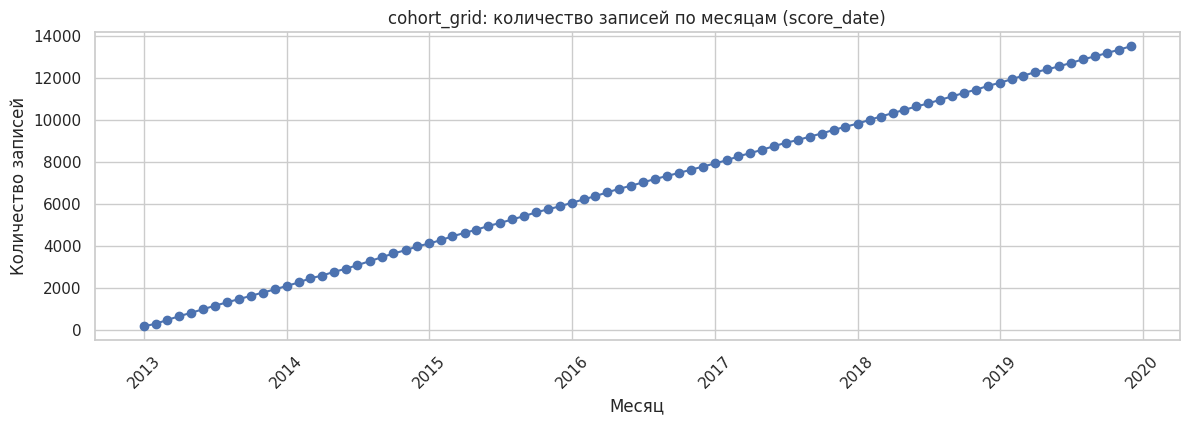

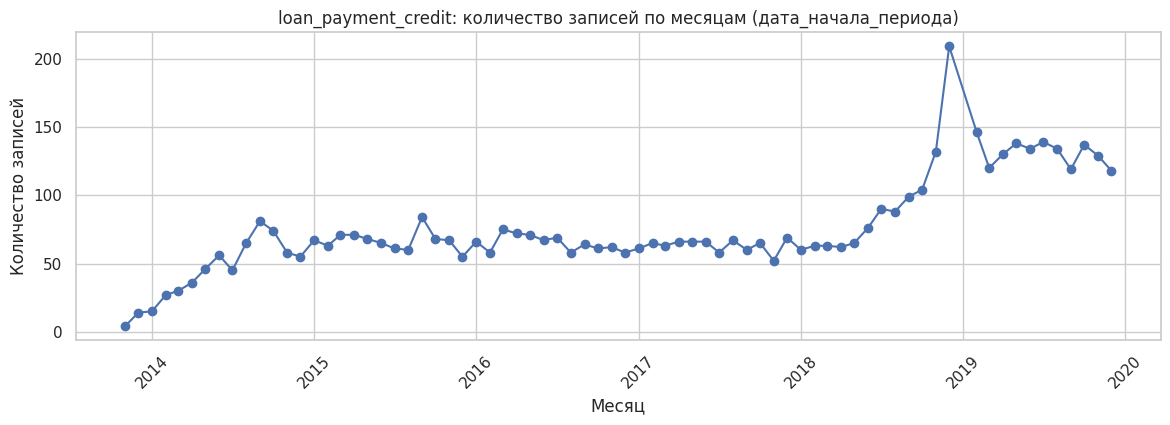

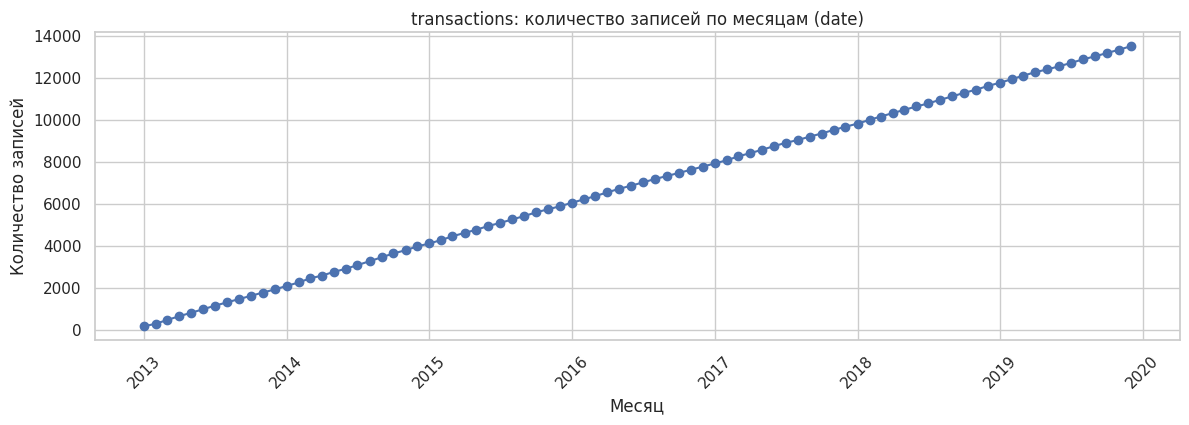

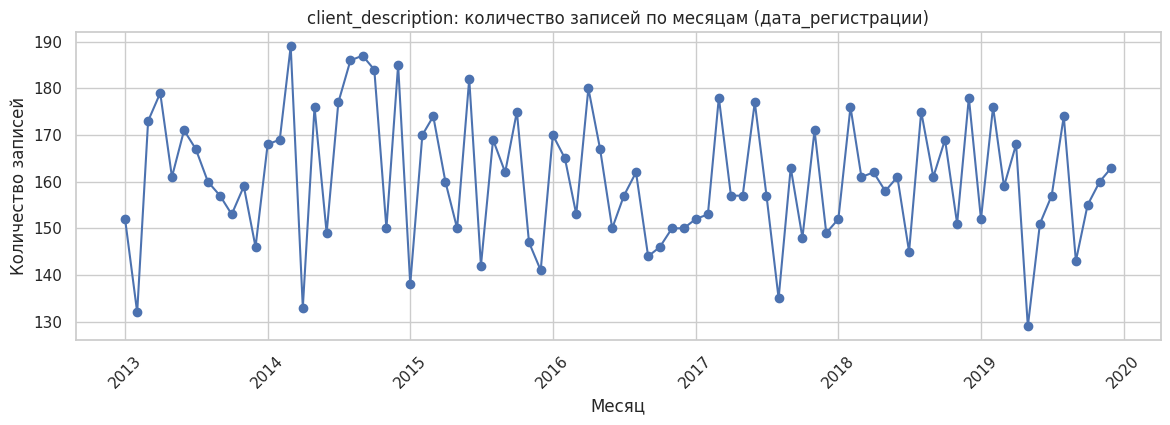

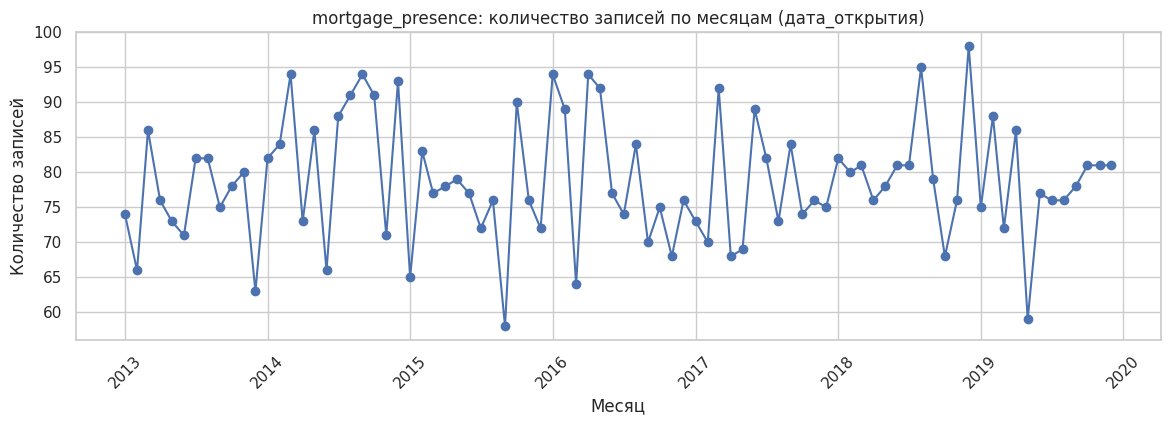

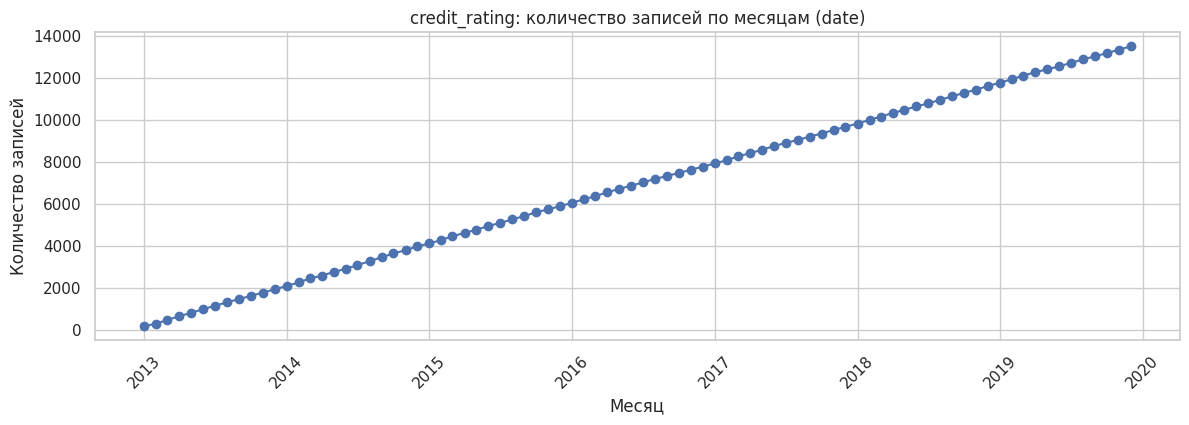

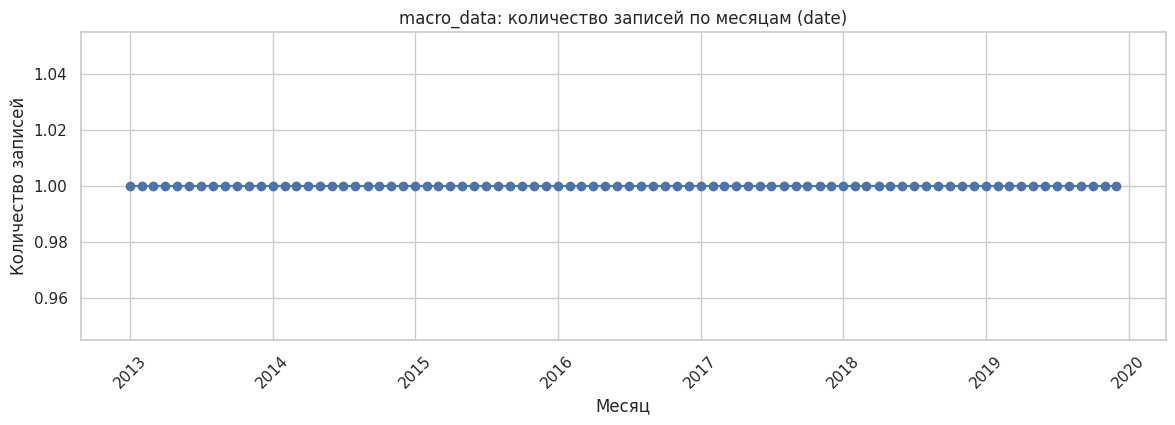

In [10]:
for name, df in df_mains.items():
    plot_date_coverage(name, df)

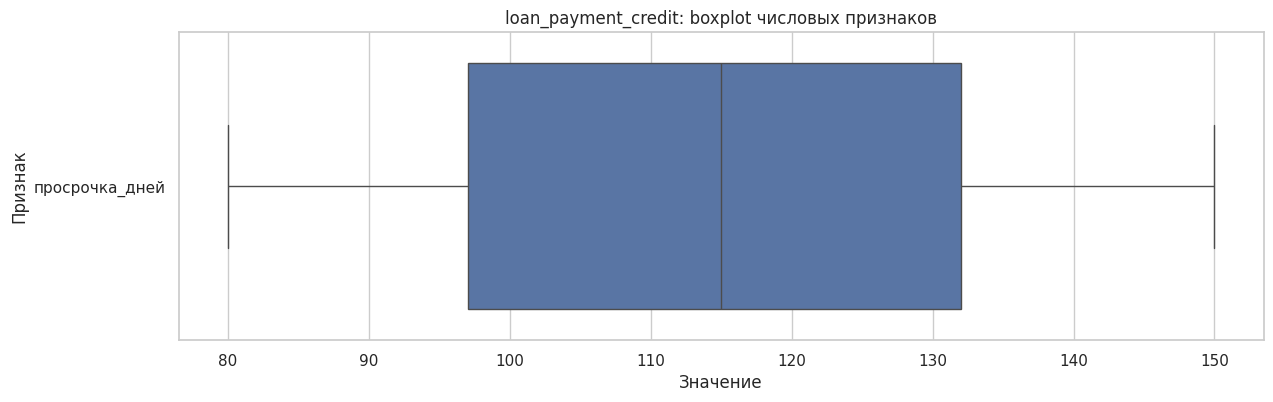

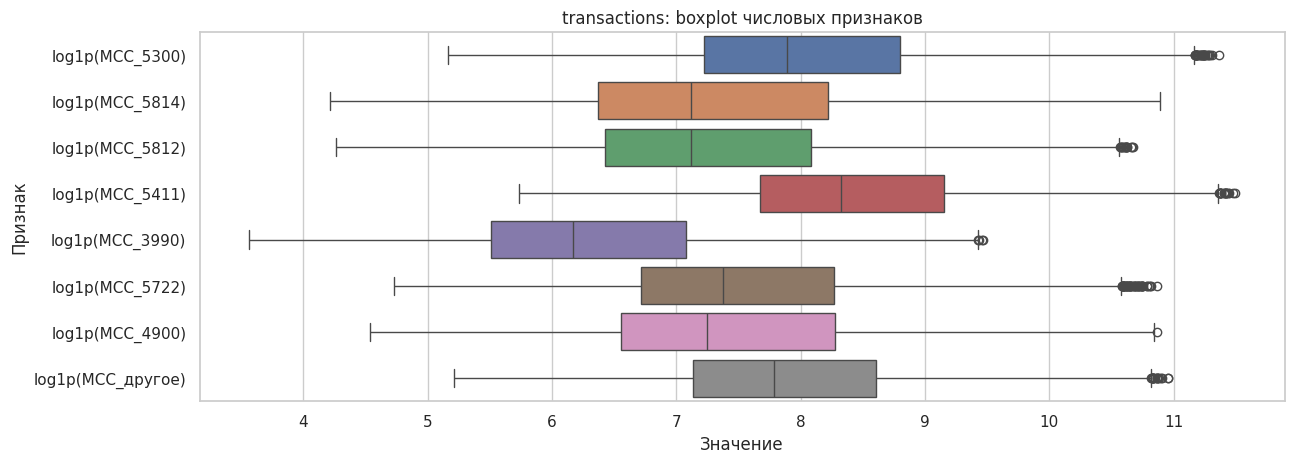

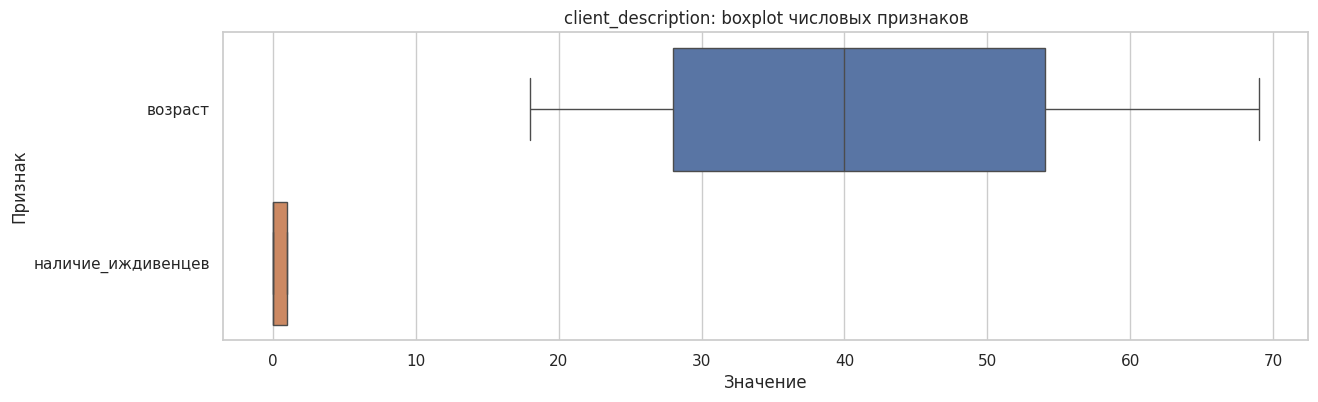

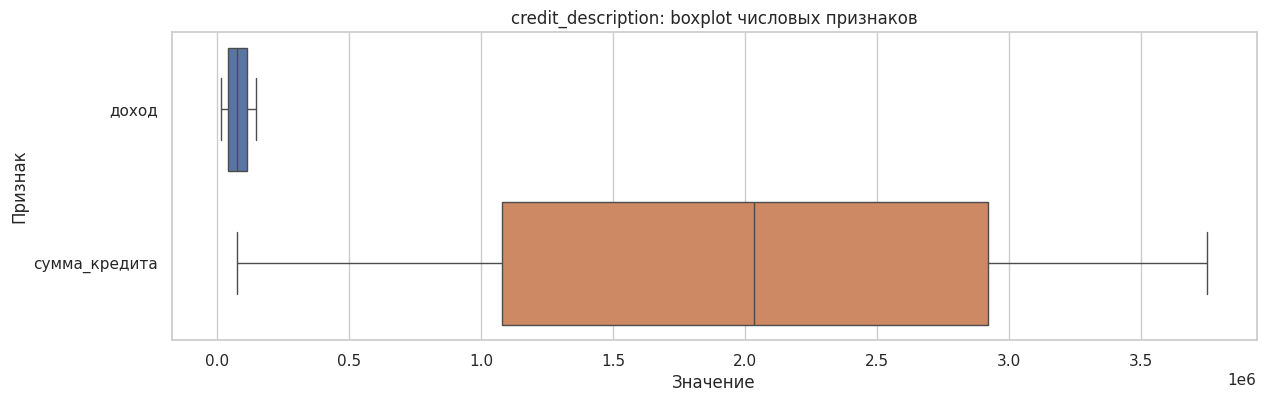

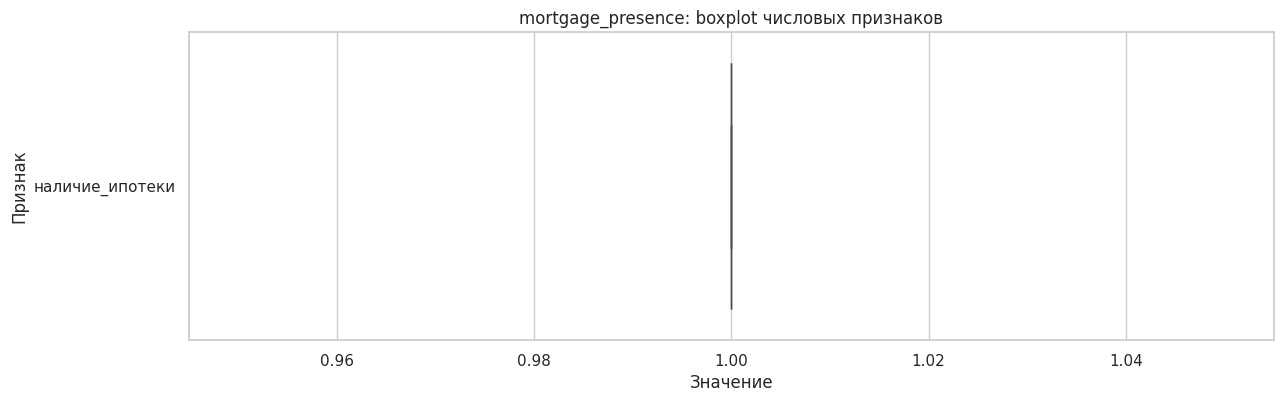

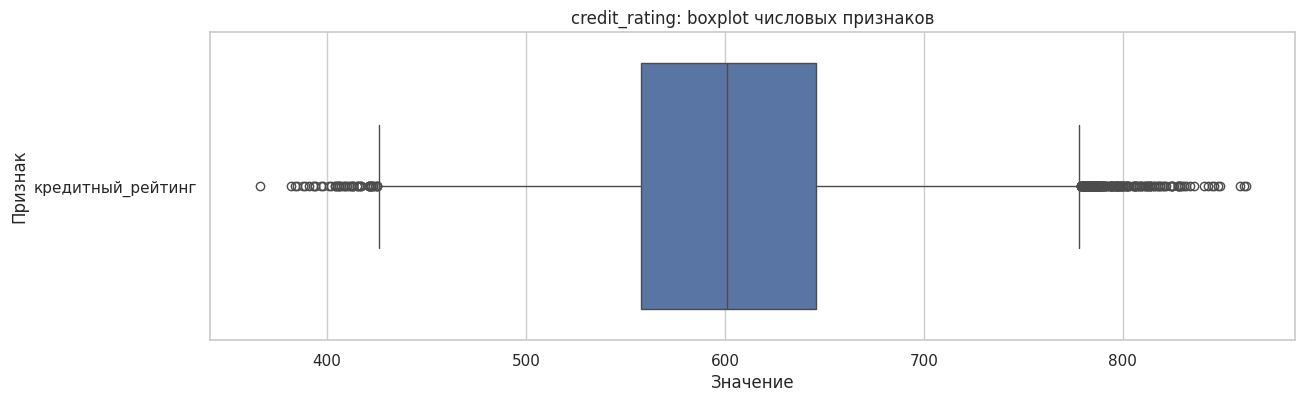

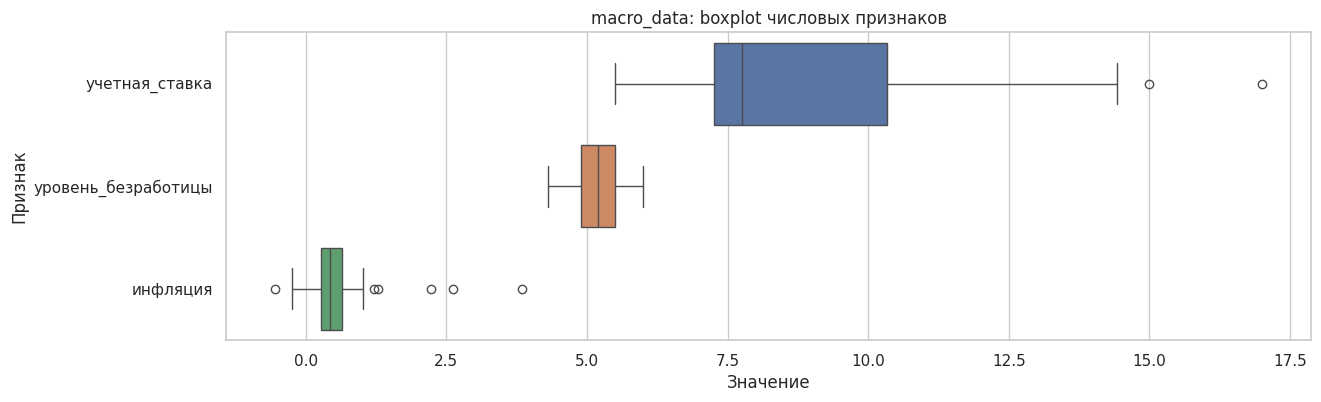

In [11]:
for name, df in df_mains.items():
    plot_numeric_boxplots(name, df)

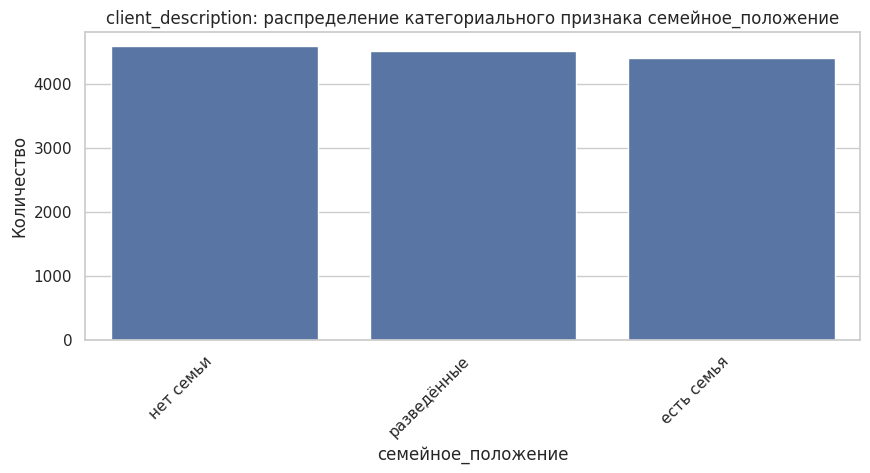

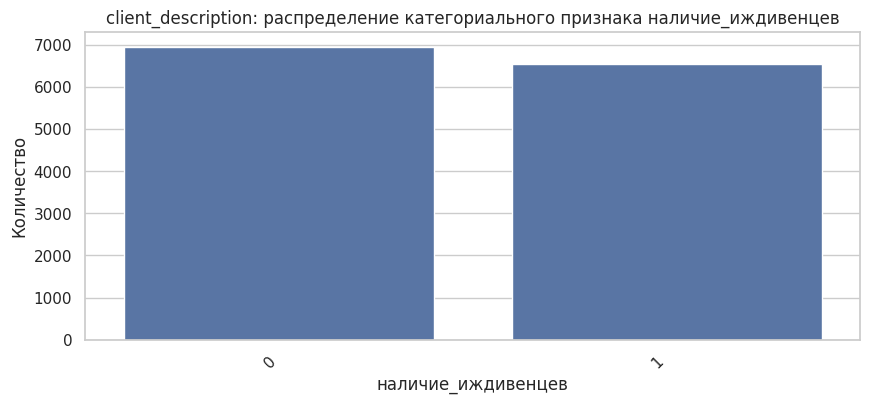

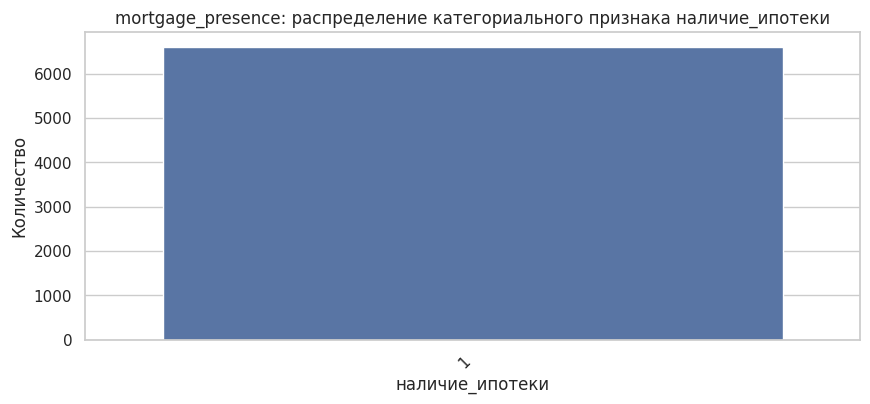

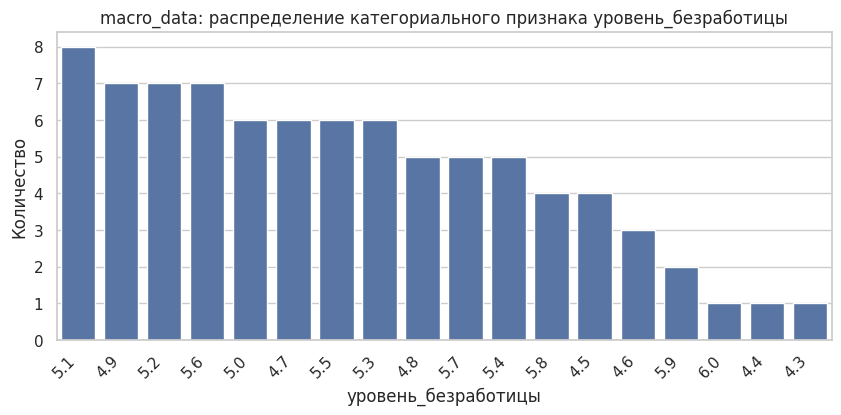

In [12]:
for name, df in df_mains.items():
    plot_categorical_distributions(name, df)

In [13]:
# Проверка дублирования по ключам таблиц, которые должны идентифицировать запись (дата, клиент, дата + клиент)

def check_duplicates(df, keys, name):
    dup_count = df.duplicated(subset=keys).sum()
    print(f'{name}: дубликатов по ключам {keys}: {dup_count}')
    
    if dup_count > 0:
        display(
            df[df.duplicated(subset=keys, keep=False)]
            .sort_values(keys)
            .head(10)
        )

In [14]:
check_duplicates(cohort_grid, ['ID', 'score_date'], 'cohort_grid')
check_duplicates(transactions, ['ID', 'date'], 'transactions')
check_duplicates(credit_rating, ['ID', 'date'], 'credit_rating')
check_duplicates(macro_data, ['date'], 'macro_data')

check_duplicates(client_description, ['ID'], 'client_description')
check_duplicates(credit_description, ['ID'], 'credit_description')

check_duplicates(mortgage_presence, ['ID', 'дата_открытия'], 'mortgage_presence')
check_duplicates(loan_payment_credit, ['ID', 'дата_начала_периода'], 'loan_payment_credit')

cohort_grid: дубликатов по ключам ['ID', 'score_date']: 0
transactions: дубликатов по ключам ['ID', 'date']: 0
credit_rating: дубликатов по ключам ['ID', 'date']: 0
macro_data: дубликатов по ключам ['date']: 0
client_description: дубликатов по ключам ['ID']: 0
credit_description: дубликатов по ключам ['ID']: 0
mortgage_presence: дубликатов по ключам ['ID', 'дата_открытия']: 0
loan_payment_credit: дубликатов по ключам ['ID', 'дата_начала_периода']: 0


### Вывод по исследовательскому анализу данных

В ходе исследовательского анализа были изучены все исходные таблицы проекта. Для каждой таблицы были проверены размеры, типы данных, количество пропусков, явные дубликаты, число уникальных значений, диапазоны дат и распределения числовых признаков. Также были построены графики для анализа временного покрытия, количественных и категориальных признаков.

Во всех таблицах отсутствуют пропуски и явные дубликаты. Это означает, что на текущем этапе не требуется удалять строки или заполнять пропущенные значения. Однако календарные признаки после загрузки имеют тип `object`, поэтому перед объединением таблиц их необходимо привести к типу `datetime`.

Основная таблица `cohort_grid` содержит сетку наблюдений «клиент — дата скоринга». Она включает 577 494 строки и 13 500 уникальных клиентов. Даты скоринга покрывают период с января 2013 года по декабрь 2019 года. Таблицы `transactions` и `credit_rating` имеют такое же количество строк и клиентов, что говорит о согласованности этих источников с основной сеткой наблюдений.

В таблице транзакций все MCC-признаки являются числовыми. Их распределения имеют выраженную правостороннюю асимметрию: медианные значения заметно ниже максимальных. Это ожидаемо для финансовых расходов клиентов, так как отдельные клиенты могут совершать крупные траты в отдельных категориях. Такие значения не следует автоматически считать ошибками данных, но при построении модели стоит учитывать возможное влияние выбросов и создать агрегированные признаки по тратам.

Таблицы `client_description` и `credit_description` содержат по одной записи на каждого клиента. В них не выявлено дубликатов по `ID`. Возраст клиентов находится в реалистичном диапазоне от 18 до 69 лет. Признак `семейное_положение` содержит три категории, а `наличие_иждивенцев` является бинарным признаком.

Таблица `mortgage_presence` содержит только клиентов с ипотекой: признак `наличие_ипотеки` во всех строках равен 1. Поэтому отсутствие клиента в этой таблице при объединении нужно будет интерпретировать как отсутствие ипотеки. Также необходимо учитывать дату открытия ипотеки, чтобы не присвоить клиенту ипотеку раньше фактической даты её появления.

Таблица `loan_payment_credit` содержит 5 500 записей о клиентах с просрочками. Значения длительности просрочки лежат в диапазоне от 80 до 150 дней. Эта таблица является событийной и будет использоваться для формирования целевой переменной. Её нельзя напрямую присоединять как обычный признак без учёта временной логики, так как это может привести к утечке информации из будущего.

Таблица `macro_data` содержит помесячные макроэкономические показатели за тот же период, что и основная временная сетка. Её можно будет присоединить к итоговой таблице по месяцу скоринга.

Дополнительно перед объединением таблиц была проверена уникальность ключей, по которым в дальнейшем будут выполняться соединения. Для таблиц с помесячными наблюдениями проверялись пары `ID` + дата (`score_date` или `date`), для таблиц с одной записью на клиента — ключ `ID`, для макроэкономических данных — ключ `date`, для событийных таблиц — пары `ID` + дата события. Дубликатов по ключам объединения не обнаружено: во всех проверенных таблицах количество таких дубликатов равно 0. Это снижает риск некорректного many-to-many объединения и непреднамеренного увеличения числа строк в итоговой таблице.

В целом данные выглядят согласованными и пригодными для дальнейшей работы. Основные особенности, которые нужно учесть на следующих этапах: приведение дат к типу `datetime`, аккуратное объединение таблиц по временной логике, корректное формирование целевой переменной в горизонте 12 месяцев и недопущение утечки будущей информации в признаки.

<div style="border:solid #D3D3D3 2px; border-radius: 10px; padding: 15px">
<h3> Комментарий ревьюера <a class="tocSkip"></h3>
<h4> Первичный анализ данных <a class="tocSkip"></h4>

<div style="border-radius: 10px" class="alert alert-success">
<b>Отлично ✅:</b> 
    
Здесь все супер! Перед началом работы важно убеждаться в пригодности данных для дальнейших шагов, что наши результаты не будут искажены.

</div>
    
<div style="border-radius: 10px" class="alert alert-warning">
<b>Рекомендации💡:</b> 

Далее нам предостоит объединять таблицы. Поэтому важно проверить дублирование по ключам таблиц, которые должны идентифицировать запись (дата, клиент, дата + клиент).


</div>


</span><br><span style="color: purple; font-weight: bold">Добавил проверку на дублирование + обновил вывод</span>

## Объединение таблиц

Соберите все источники данных о клиентах в единую таблицу наблюдений.

### Формирование целевой переменной

1. Значение бинарной целевой переменной нужно определить для каждой строки со столбцами `ID` и `score_date` в таблице `cohort_grid`.

2. Таргет равен 1 при соблюдении двух условий:
    * Если значение в поле `просрочка_дней` больше или равно 90.
    * Если для клиента существует строка в таблице `loan_payment_credit`, где значение в поле `дата_начала_периода` попадает в интервал `[score_date, score_date + 365 дней)`.

>Важно: у клиента может быть несколько эпизодов с просрочками от 90 дней. Вам нужно взять первый по времени возникновения эпизод в таблице с просрочками.

3. После расчёта целевой переменной удалите строки, где дефолт уже произошёл к моменту скоринга, то есть `дата_начала_периода < score_date`. Это необходимо, так как для корректной работы с временной структурой важно учитывать дефолты, произошедшие в прошлом относительно даты скоринга.

### Создание итоговой таблицы

1. В качестве признаков можно использовать только информацию о прошлом, то есть она должна быть доступна к дате скоринга. Иными словами, в каждой строке нужно присоединить данные о поведении клиента за предыдущие периоды относительно даты скоринга, иначе произойдёт утечка данных из будущего.

>К примеру, `score_date = 2024-01-15`. Тогда:
>* транзакции за декабрь 2023 г. — можем использовать;
>* транзакции за ноябрь 2023 г. — можем использовать;
>* транзакции 16 января 2024 г. — **не** можем использовать.

2. Присоедините остальные данные по клиенту, помимо указанных выше данных о макроэкономике и транзакциях клиента.

> Рекомендации:
>* Не забывайте проверять правильность каждого этапа сбора данных в единую таблицу. Это можно отслеживать на одном из клиентов.
>* При формировании таблицы следите за тем, чтобы в ней была корректно проведена работа со временем:
  >   * Отследите, не упущены ли какие-то данные из прошлого;
  >   * Проконтролируйте, верно ли рассчитана целевая переменная, которая зависит от дефолта в будущем.
>* Помните, что даты в исходных таблицах указаны на первое число месяца. Учитывайте период, который они описывают.

Сделайте выводы о получившейся таблице.

In [15]:
# Приводим даты к datetime
cohort_grid[SCORE_DATE_COL] = pd.to_datetime(
    cohort_grid[SCORE_DATE_COL],
    errors="coerce"
)

loan_payment_credit[DEFAULT_START_COL] = pd.to_datetime(
    loan_payment_credit[DEFAULT_START_COL],
    errors="coerce"
)

# Проверим, что даты распарсились корректно
print("Пропуски в score_date после преобразования:")
print(cohort_grid[SCORE_DATE_COL].isna().sum())

print("\nПропуски в дате начала периода просрочки после преобразования:")
print(loan_payment_credit[DEFAULT_START_COL].isna().sum())

Пропуски в score_date после преобразования:
0

Пропуски в дате начала периода просрочки после преобразования:
0


In [16]:
# Отбираем только дефолтные эпизоды: просрочка 90+ дней
default_events = loan_payment_credit[
    loan_payment_credit[DEFAULT_DAYS_COL] >= DEFAULT_DAYS_THRESHOLD
].copy()

# Если у клиента несколько дефолтных эпизодов, берём первый по времени
first_default_events = (
    default_events
    .sort_values([ID_COL, DEFAULT_START_COL])
    .groupby(ID_COL, as_index=False)
    .first()
    .rename(
        columns={
            DEFAULT_START_COL: "first_default_90plus_date",
            DEFAULT_DAYS_COL: "first_default_90plus_days",
        }
    )
)

print(f"Всего записей в таблице просрочек: {len(loan_payment_credit)}")
print(f"Эпизодов с просрочкой 90+ дней: {len(default_events)}")
print(f"Клиентов с хотя бы одним эпизодом 90+ дней: {first_default_events[ID_COL].nunique()}")

display(first_default_events.head())

Всего записей в таблице просрочек: 5500
Эпизодов с просрочкой 90+ дней: 4712
Клиентов с хотя бы одним эпизодом 90+ дней: 4712


,ID,first_default_90plus_date,first_default_90plus_days
0,IDF54896351,2014-10-01,93
1,IDF54896494,2019-07-01,137
2,IDF54896677,2017-09-01,90
3,IDF54896685,2017-11-01,136
4,IDF54896744,2019-02-01,97


In [17]:
# Базовая таблица наблюдений: каждая строка — клиент на дату скоринга
df_target_base = cohort_grid.merge(
    first_default_events[
        [ID_COL, "first_default_90plus_date", "first_default_90plus_days"]
    ],
    on=ID_COL,
    how="left"
)

# Конец горизонта прогнозирования: [score_date, score_date + 12 месяцев)
df_target_base["forecast_end_date"] = (
    df_target_base[SCORE_DATE_COL] + pd.DateOffset(months=HORIZON_MONTHS)
)

# Сколько дней осталось до первого дефолта 90+
df_target_base["days_to_first_default"] = (
    df_target_base["first_default_90plus_date"] - df_target_base[SCORE_DATE_COL]
).dt.days

# Таргет равен 1, если первый дефолт 90+ попадает в горизонт [score_date, score_date + 365 дней)
df_target_base[TARGET] = (
    df_target_base["first_default_90plus_date"].notna()
    & (df_target_base["first_default_90plus_date"] >= df_target_base[SCORE_DATE_COL])
    & (df_target_base["first_default_90plus_date"] < df_target_base["forecast_end_date"])
).astype(int)

display(df_target_base.head())

,ID,score_date,first_default_90plus_date,first_default_90plus_days,forecast_end_date,days_to_first_default,target
0,IDF55109846,2013-05-01,2014-12-01,120.000,2014-05-01,579.000,0
1,IDF55109846,2013-06-01,2014-12-01,120.000,2014-06-01,548.000,0
2,IDF55109846,2013-07-01,2014-12-01,120.000,2014-07-01,518.000,0
3,IDF55109846,2013-08-01,2014-12-01,120.000,2014-08-01,487.000,0
4,IDF55109846,2013-09-01,2014-12-01,120.000,2014-09-01,456.000,0


In [18]:
# Строки, где первый дефолт уже случился к моменту скоринга
past_default_mask = (
    df_target_base["first_default_90plus_date"].notna()
    & (df_target_base["first_default_90plus_date"] < df_target_base[SCORE_DATE_COL])
)

print(f"Размер до удаления строк с уже произошедшим дефолтом: {df_target_base.shape}")
print(f"Строк к удалению: {past_default_mask.sum()}")

# Удаляем такие строки
df_observations = df_target_base.loc[~past_default_mask].copy()

print(f"Размер после удаления строк с уже произошедшим дефолтом: {df_observations.shape}")
print(f"Удалено строк: {df_target_base.shape[0] - df_observations.shape[0]}")

Размер до удаления строк с уже произошедшим дефолтом: (577494, 7)
Строк к удалению: 139115


Размер после удаления строк с уже произошедшим дефолтом: (438379, 7)
Удалено строк: 139115


In [19]:
# Проверка: нет ли дубликатов по паре ID + score_date
duplicated_pairs = df_observations.duplicated([ID_COL, SCORE_DATE_COL]).sum()
print(f"Дубликатов по паре ID + score_date: {duplicated_pairs}")

# Проверка: после фильтрации не должно остаться строк, где дефолт уже был в прошлом
past_defaults_left = (
    df_observations["first_default_90plus_date"].notna()
    & (df_observations["first_default_90plus_date"] < df_observations[SCORE_DATE_COL])
).sum()

print(f"Строк с дефолтом в прошлом после фильтрации: {past_defaults_left}")

# Проверка значений таргета
print("\nРаспределение целевой переменной:")
target_distribution = (
    df_observations[TARGET]
    .value_counts(dropna=False)
    .rename("count")
    .to_frame()
)

target_distribution["percent"] = (
    target_distribution["count"] / len(df_observations) * 100
).round(2)

display(target_distribution)

# Контрольные assert
assert duplicated_pairs == 0
assert past_defaults_left == 0
assert df_observations[TARGET].isin([0, 1]).all()

Дубликатов по паре ID + score_date: 0
Строк с дефолтом в прошлом после фильтрации: 0

Распределение целевой переменной:


,count,percent
target,,
0,389015,88.740
1,49364,11.260


,score_date,observations,target_1_count,target_1_share
0,2013-01-01,152,10,0.066
1,2013-02-01,284,24,0.085
2,2013-03-01,457,48,0.105
3,2013-04-01,636,71,0.112
4,2013-05-01,797,98,0.123


,score_date,observations,target_1_count,target_1_share
79,2019-08-01,8714,333,0.038
80,2019-09-01,8737,266,0.030
81,2019-10-01,8790,225,0.026
82,2019-11-01,8839,160,0.018
83,2019-12-01,8888,100,0.011


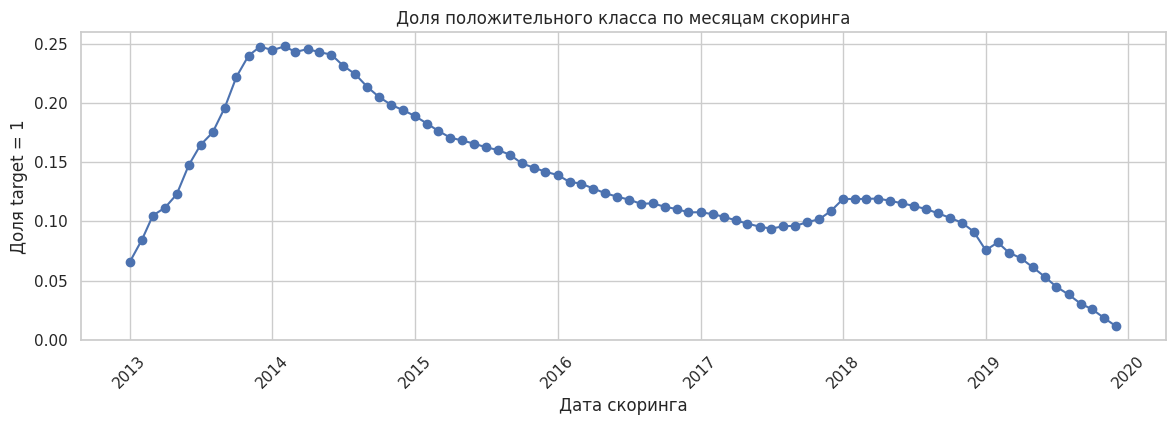

In [20]:
target_by_month = (
    df_observations
    .groupby(SCORE_DATE_COL)[TARGET]
    .agg(["count", "sum", "mean"])
    .rename(
        columns={
            "count": "observations",
            "sum": "target_1_count",
            "mean": "target_1_share",
        }
    )
    .reset_index()
)

display(target_by_month.head())
display(target_by_month.tail())

plt.figure(figsize=(14, 4))
plt.plot(
    target_by_month[SCORE_DATE_COL],
    target_by_month["target_1_share"],
    marker="o"
)
plt.title("Доля положительного класса по месяцам скоринга")
plt.xlabel("Дата скоринга")
plt.ylabel("Доля target = 1")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

### Промежуточный вывод по формированию целевой переменной

На этом этапе была сформирована бинарная целевая переменная `target` для каждой строки из таблицы `cohort_grid`, то есть для каждой пары «клиент — дата скоринга». Перед расчётом таргета даты в таблицах `cohort_grid` и `loan_payment_credit` были приведены к типу `datetime`. Ошибок преобразования дат не обнаружено: пропуски после преобразования отсутствуют.

В таблице просрочек содержится 5 500 записей. Из них 4 712 эпизодов соответствуют условию дефолта, то есть имеют длительность просрочки 90 дней и более. Для каждого клиента был выбран первый по времени эпизод просрочки 90+ дней, так как именно он используется для корректного определения будущего дефолта относительно даты скоринга.

Для каждой строки из `cohort_grid` был рассчитан горизонт прогнозирования: интервал от `score_date` до `score_date + 365 дней`. Целевая переменная получила значение `1`, если первый дефолт клиента попадал в этот интервал, и `0` — если дефолт не попадал в горизонт прогнозирования или у клиента не было дефолта 90+ дней.

После расчёта таргета были удалены строки, в которых дефолт уже произошёл до даты скоринга. Это необходимо, потому что такие наблюдения не соответствуют задаче прогнозирования будущего риска: на момент скоринга дефолт уже известен. До удаления таблица содержала 577 494 строки, после удаления осталось 438 379 строк. Было удалено 139 115 строк с уже произошедшим дефолтом.

Дополнительные проверки показали, что в итоговой таблице наблюдений нет дубликатов по паре `ID` и `score_date`, а также не осталось строк, где дата первого дефолта находится в прошлом относительно даты скоринга. Это подтверждает корректность временной фильтрации.

Распределение целевой переменной показывает дисбаланс классов: положительный класс `target = 1` составляет 49 364 наблюдения, или 11.26% выборки, отрицательный класс `target = 0` — 389 015 наблюдений, или 88.74%. Следовательно, задача является несбалансированной бинарной классификацией. На этапе моделирования потребуется учитывать дисбаланс классов с помощью специальных методов балансировки или весов классов.

Также видно, что доля положительного класса меняется во времени: в начале периода она постепенно растёт, а к концу 2019 года заметно снижается. Это ожидаемо, так как для последних месяцев наблюдений горизонт будущего дефолта ограничен доступными данными. При дальнейшем разбиении выборки и кросс-валидации необходимо учитывать временную структуру данных.

In [21]:
# Копируем базовую таблицу наблюдений с уже рассчитанным target
df_final = df_observations.copy()

print(f"Стартовый размер df_final: {df_final.shape}")
display(df_final.head())

Стартовый размер df_final: (438379, 7)


,ID,score_date,first_default_90plus_date,first_default_90plus_days,forecast_end_date,days_to_first_default,target
0,IDF55109846,2013-05-01,2014-12-01,120.000,2014-05-01,579.000,0
1,IDF55109846,2013-06-01,2014-12-01,120.000,2014-06-01,548.000,0
2,IDF55109846,2013-07-01,2014-12-01,120.000,2014-07-01,518.000,0
3,IDF55109846,2013-08-01,2014-12-01,120.000,2014-08-01,487.000,0
4,IDF55109846,2013-09-01,2014-12-01,120.000,2014-09-01,456.000,0


In [22]:
# Приводим даты к datetime
df_final[SCORE_DATE_COL] = pd.to_datetime(df_final[SCORE_DATE_COL], errors="coerce")

client_description["дата_регистрации"] = pd.to_datetime(
    client_description["дата_регистрации"],
    errors="coerce"
)

mortgage_presence["дата_открытия"] = pd.to_datetime(
    mortgage_presence["дата_открытия"],
    errors="coerce"
)

credit_rating["date"] = pd.to_datetime(
    credit_rating["date"],
    errors="coerce"
)

transactions["date"] = pd.to_datetime(
    transactions["date"],
    errors="coerce"
)

macro_data["date"] = pd.to_datetime(
    macro_data["date"],
    errors="coerce"
)

In [23]:
# Функция для контроля после каждого объединения

def check_merge_result(df_before, df_after, step_name):
    print("=" * 80)
    print(step_name)
    print("=" * 80)

    print(f"Размер до объединения: {df_before.shape}")
    print(f"Размер после объединения: {df_after.shape}")

    row_diff = df_after.shape[0] - df_before.shape[0]
    print(f"Изменение количества строк: {row_diff}")

    duplicated_pairs = df_after.duplicated([ID_COL, SCORE_DATE_COL]).sum()
    print(f"Дубликатов по паре ID + score_date: {duplicated_pairs}")

    if row_diff != 0:
        print("Внимание: количество строк изменилось.")

    if duplicated_pairs != 0:
        print("Внимание: появились дубликаты по ID + score_date.")

    print("\n")

In [24]:
df_before = df_final.copy()

df_final = df_final.merge(
    client_description,
    on=ID_COL,
    how="left",
    validate="many_to_one"
)

check_merge_result(df_before, df_final, "Присоединение client_description")

Присоединение client_description
Размер до объединения: (438379, 7)
Размер после объединения: (438379, 11)
Изменение количества строк: 0
Дубликатов по паре ID + score_date: 0




In [25]:
df_before = df_final.copy()

df_final = df_final.merge(
    credit_description,
    on=ID_COL,
    how="left",
    validate="many_to_one"
)

check_merge_result(df_before, df_final, "Присоединение credit_description")

Присоединение credit_description
Размер до объединения: (438379, 11)
Размер после объединения: (438379, 13)
Изменение количества строк: 0
Дубликатов по паре ID + score_date: 0




In [26]:
df_before = df_final.copy()

mortgage_features = mortgage_presence[
    [ID_COL, "дата_открытия", "наличие_ипотеки"]
].copy()

df_final = df_final.merge(
    mortgage_features,
    on=ID_COL,
    how="left",
    validate="many_to_one"
)

# Если клиента нет в таблице mortgage_presence, считаем, что ипотеки нет.
# Если ипотека открыта после score_date, на момент скоринга её ещё нельзя учитывать.
df_final["наличие_ипотеки"] = (
    df_final["дата_открытия"].notna()
    & (df_final["дата_открытия"] <= df_final[SCORE_DATE_COL])
).astype(int)

# Дату открытия оставляем как исходную информацию.
check_merge_result(df_before, df_final, "Присоединение mortgage_presence")

Присоединение mortgage_presence
Размер до объединения: (438379, 13)
Размер после объединения: (438379, 15)
Изменение количества строк: 0
Дубликатов по паре ID + score_date: 0




In [27]:
df_before = df_final.copy()

credit_rating_for_merge = credit_rating.rename(
    columns={"date": SCORE_DATE_COL}
)

df_final = df_final.merge(
    credit_rating_for_merge,
    on=[ID_COL, SCORE_DATE_COL],
    how="left",
    validate="many_to_one"
)

check_merge_result(df_before, df_final, "Присоединение credit_rating")

Присоединение credit_rating
Размер до объединения: (438379, 15)
Размер после объединения: (438379, 16)
Изменение количества строк: 0
Дубликатов по паре ID + score_date: 0




In [28]:
df_before = df_final.copy()

transactions_for_merge = transactions.copy()

# Транзакции за месяц date используем для следующего месяца скоринга
transactions_for_merge[SCORE_DATE_COL] = (
    transactions_for_merge["date"] + pd.DateOffset(months=1)
)

transactions_for_merge = transactions_for_merge.drop(columns=["date"])

# Чтобы было явно понятно, что это данные прошлого месяца
mcc_columns = [
    col for col in transactions_for_merge.columns
    if col.startswith("MCC_")
]

transactions_for_merge = transactions_for_merge.rename(
    columns={col: f"{col}_prev_month" for col in mcc_columns}
)

df_final = df_final.merge(
    transactions_for_merge,
    on=[ID_COL, SCORE_DATE_COL],
    how="left",
    validate="many_to_one"
)

mcc_prev_columns = [
    f"{col}_prev_month" for col in mcc_columns
]

# Индикатор наличия истории транзакций за предыдущий месяц
df_final["has_prev_month_transactions"] = (
    df_final[mcc_prev_columns].notna().any(axis=1)
).astype(int)

# Если истории за предыдущий месяц нет, считаем траты равными 0.
# При этом отдельный индикатор сообщает модели, что это не обычный ноль,
# а отсутствие доступной истории.
df_final[mcc_prev_columns] = df_final[mcc_prev_columns].fillna(0)

check_merge_result(df_before, df_final, "Присоединение transactions за предыдущий месяц")

Присоединение transactions за предыдущий месяц
Размер до объединения: (438379, 16)
Размер после объединения: (438379, 25)
Изменение количества строк: 0
Дубликатов по паре ID + score_date: 0




In [29]:
df_before = df_final.copy()

macro_for_merge = macro_data.copy()

macro_for_merge = macro_for_merge.rename(
    columns={"date": SCORE_DATE_COL}
)

df_final = df_final.merge(
    macro_for_merge,
    on=SCORE_DATE_COL,
    how="left",
    validate="many_to_one"
)

check_merge_result(df_before, df_final, "Присоединение macro_data за текущий месяц")

Присоединение macro_data за текущий месяц
Размер до объединения: (438379, 25)
Размер после объединения: (438379, 28)
Изменение количества строк: 0
Дубликатов по паре ID + score_date: 0




In [30]:
# Удаляем служебные колонки с утечкой

leakage_columns = [
    "first_default_90plus_date",
    "first_default_90plus_days",
    "forecast_end_date",
    "days_to_first_default",
]

df_model = df_final.drop(columns=leakage_columns)

print(f"Размер таблицы до удаления служебных колонок: {df_final.shape}")
print(f"Размер итоговой таблицы для дальнейшей работы: {df_model.shape}")

display(df_model.head())

Размер таблицы до удаления служебных колонок: (438379, 28)
Размер итоговой таблицы для дальнейшей работы: (438379, 24)


,ID,score_date,target,возраст,семейное_положение,наличие_иждивенцев,дата_регистрации,доход,сумма_кредита,дата_открытия,наличие_ипотеки,кредитный_рейтинг,MCC_5300_prev_month,MCC_5814_prev_month,MCC_5812_prev_month,MCC_5411_prev_month,MCC_3990_prev_month,MCC_5722_prev_month,MCC_4900_prev_month,MCC_другое_prev_month,has_prev_month_transactions,учетная_ставка,уровень_безработицы,инфляция
0,IDF55109846,2013-05-01,0,41,разведённые,1,2013-05-01,27035,1960785,NaT,0,692,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0,5.500,5.400,0.660
1,IDF55109846,2013-06-01,0,41,разведённые,1,2013-05-01,27035,1960785,NaT,0,688,3267.590,1282.110,1457.960,5711.100,647.430,2374.780,4059.860,3657.350,1,5.500,5.300,0.420
2,IDF55109846,2013-07-01,0,41,разведённые,1,2013-05-01,27035,1960785,NaT,0,666,3196.580,2443.370,1334.200,5824.650,1067.550,2187.110,4592.260,3322.610,1,5.500,5.300,0.820
3,IDF55109846,2013-08-01,0,41,разведённые,1,2013-05-01,27035,1960785,NaT,0,692,3550.540,4277.720,1463.750,5209.510,1167.950,2076.540,3605.250,3467.060,1,5.500,5.200,0.140
4,IDF55109846,2013-09-01,0,41,разведённые,1,2013-05-01,27035,1960785,NaT,0,688,3385.980,4530.630,1261.400,5765.960,986.990,2231.770,2209.390,3354.440,1,5.500,5.100,0.210


In [31]:
# Удаляем колонку "дата открытия", чтобы не было утечки

df_model = df_model.drop(columns=["дата_открытия"])

In [32]:
# Итоговая проверка

df_model.info()

print("\nДубликаты по ID + score_date:")
print(df_model.duplicated([ID_COL, SCORE_DATE_COL]).sum())

print("\nРаспределение target:")
target_info = (
    df_model[TARGET]
    .value_counts()
    .to_frame("count")
)

target_info["percent"] = (
    target_info["count"] / len(df_model) * 100
).round(2)

display(target_info)

print("\nПропуски в итоговой таблице:")
missing_final = df_model.isna().sum().to_frame("missing_values")
missing_final["missing_percent"] = (
    missing_final["missing_values"] / len(df_model) * 100
).round(2)

display(
    missing_final
    .query("missing_values > 0")
    .sort_values("missing_percent", ascending=False)
)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 438379 entries, 0 to 438378
Data columns (total 23 columns):
 #   Column                       Non-Null Count   Dtype         
---  ------                       --------------   -----         
 0   ID                           438379 non-null  object        
 1   score_date                   438379 non-null  datetime64[ns]
 2   target                       438379 non-null  int64         
 3   возраст                      438379 non-null  int64         
 4   семейное_положение           438379 non-null  object        
 5   наличие_иждивенцев           438379 non-null  int64         
 6   дата_регистрации             438379 non-null  datetime64[ns]
 7   доход                        438379 non-null  int64         
 8   сумма_кредита                438379 non-null  int64         
 9   наличие_ипотеки              438379 non-null  int64         
 10  кредитный_рейтинг            438379 non-null  int64         
 11  MCC_5300_prev_month       

,count,percent
target,,
0,389015,88.740
1,49364,11.260



Пропуски в итоговой таблице:


,missing_values,missing_percent


In [33]:
df_final[[ID_COL, SCORE_DATE_COL]].duplicated().sum()

0

### Вывод по объединению таблиц

На этапе объединения была сформирована итоговая таблица наблюдений `df_model`. В качестве базовой таблицы использовалась `cohort_grid` с уже рассчитанной целевой переменной `target`. После удаления строк, где дефолт уже произошёл до даты скоринга, в таблице осталось 438 379 наблюдений.

К итоговой таблице были последовательно присоединены данные о клиенте, параметры кредита, информация об ипотеке, кредитный рейтинг, транзакции за предыдущий месяц и макроэкономические показатели за предыдущий месяц. При объединении учитывалась временная структура данных: в признаки включалась только информация, доступная на момент скоринга или ранее. Для транзакций и макроэкономических данных использовались значения предыдущего месяца, чтобы не допустить утечки информации из будущего.

После объединения итоговая таблица содержит 22 столбца. Дубликатов по паре `ID` и `score_date` не обнаружено, следовательно, единица наблюдения сохранена корректно: одна строка соответствует одному клиенту на одну дату скоринга. Распределение целевой переменной также не изменилось: отрицательный класс составляет 88.74%, положительный класс — 11.26%.

В итоговой таблице остались пропуски в признаках транзакций за предыдущий месяц: по 13 500 пропусков в каждом MCC-признаке, что составляет 3.08% данных. Это ожидаемо, так как для первых наблюдений клиентов отсутствует информация за предыдущий месяц. Также есть 152 пропуска в макроэкономических признаках предыдущего месяца, что связано с отсутствием предыдущего периода для самых ранних дат скоринга. Эти пропуски не являются ошибками данных и будут обработаны позже на этапе подготовки признаков к моделированию.

Информация об ипотеке была присоединена с учётом даты скоринга: если ипотека была открыта позже даты скоринга или клиент отсутствовал в таблице ипотек, признак `наличие_ипотеки` принимал значение 0. Дата открытия ипотеки не была оставлена в модельной таблице, чтобы избежать возможной утечки будущей информации.

Таким образом, итоговая таблица собрана корректно: строки не потеряны и не размножены, целевая переменная сохранена, временная логика при присоединении данных соблюдена. Полученная таблица может использоваться для дальнейшего создания новых признаков и подготовки данных к моделированию.

<div style="border:solid #D3D3D3 2px; border-radius: 10px; padding: 15px">
<h3> Комментарий ревьюера <a class="tocSkip"></h3>
<h4> Сборка данных для обучения<a class="tocSkip"></h4>
     
<div style="border-radius: 10px" class="alert alert-success">
<b>Отлично ✅:</b> 

* Сейчас в данных по просрочкам у нас всего по одной записи на клиента, но здорово, что предусматривается возможность появления рецидивов - отбирается первый случай дефолта.


* Верно был обнаружен нюанс с неполным обзором на следующие 12 месяцев для 2019 года! Вероятность дефолта из-за этого искажается, поэтому мы не можем использовать данный период для моделирования.
    
    
* Отлично, что берешь информацию о тратах из прошлого! Мы не можем использовать для моделирования информацию, которая впоследствии на практике к моменту скоринга не будет доступна.


</div>
    
    
<div style="border-radius: 10px" class="alert alert-block alert-danger">
<b>Нужно доработать ❌:</b>    
    
* У нас в рассмотрении 7 лет, то есть мы столкнулись как минимум с 1 високосным годом. Поэтому коррктнее прибавлять не дни, а месяцы, количество которых от года к году не меняется.
    

* В результате сдвига данных по дате у нас образовались пропуски - за прошлый месяц по клиенту нет информации, если это скоринг в январе 2013 или скоринг только что присоединившегося клиента (у которого нет истории). Медиану использовать не можем, это некорректно в отношении временных рядов, искажает динамику. Экстраполяцию на основе будущего производить тоже не можем, это утечка будущего. Два допустимых решения: удалить и уточнить, что наша модель будет предназначена только для наблюдения за клиентами, начиная со второго месяца, либо заполнить нулями (или иными отличающимися значениями), но в обязательном порядке ввести дополнительные признаки-индикаторы: бинарный признак присутствия пропуска, клиентский стаж. Данные признаки дают возможности модели уловить, что клиент только-только взял кредит.


</div>
    
    
<div style="border-radius: 10px" class="alert alert-warning">
<b>Рекомендации💡:</b> 


* В качестве более продвинутой альтернативы ручному сдвигу даты есть довольно удобный метод [merge_asof](https://pandas.pydata.org/docs/reference/api/pandas.merge_asof.html), который может сам вытаскивать значения из прошлого, нужно только грамотно задать настройки. Даже при настройке `direction = backward` данный метод подбирает значение меньше или **равное** текущему, поэтому в нашем случае требуется также скорректировать значение параметра `allow_exact_matches`. 

    
* Макропоказатели и кредитный рейтинг можно брать за текущий месяц. В описании данных отмечено, что дата, указанная в таблицах - это дата актуальности показателей, то есть на момент скоринга они будут нам доступны.

</div>


</span><br><span style="color: purple; font-weight: bold">Поправил, смотри подвывод:</span>

### Промежуточный вывод по объединению таблиц

В разделе объединения таблиц была уточнена временная логика соединения данных. Горизонт прогнозирования для целевой переменной рассчитывается через `pd.DateOffset(months=12)`, а не через фиксированные 365 дней, что корректнее для периода в несколько лет, включая високосный год.

Кредитный рейтинг и макроэкономические показатели присоединяются за текущий месяц скоринга, так как по описанию данных эти значения актуальны и доступны на дату скоринга. Транзакционные признаки присоединяются за предыдущий месяц, чтобы не использовать информацию из будущего.

После сдвига транзакционных данных появились пропуски для наблюдений, у которых нет истории за предыдущий месяц. Такие пропуски не заполнялись медианой, чтобы не искажать временную динамику. Вместо этого транзакционные значения были заполнены нулями, а также добавлен бинарный признак `has_prev_month_transactions`, показывающий наличие или отсутствие транзакционной истории за предыдущий месяц.

После всех объединений была дополнительно проверена уникальность ключа `ID` + `score_date` в итоговой таблице. Дубликатов не обнаружено, число строк не увеличилось некорректно, поэтому many-to-many объединения не возникло.

## Создание новых признаков

* Добавьте в таблицу новые признаки, которые помогли бы описать поведение клиента. Создайте не менее двух новых признаков.
* Сделайте выводы о новых признаках.

In [34]:
df_features = df_model.copy()

print(f"Размер таблицы до создания новых признаков: {df_features.shape}")

Размер таблицы до создания новых признаков: (438379, 23)


In [35]:
new_feature_columns = []

# Стаж клиента в банке на дату скоринга, в месяцах
df_features["client_tenure_months"] = (
    (df_features[SCORE_DATE_COL].dt.year - df_features["дата_регистрации"].dt.year) * 12
    + (df_features[SCORE_DATE_COL].dt.month - df_features["дата_регистрации"].dt.month)
)

new_feature_columns.append("client_tenure_months")

# Отношение суммы кредита к месячному доходу
df_features["credit_to_income_ratio"] = (
    df_features["сумма_кредита"] / df_features["доход"]
)

new_feature_columns.append("credit_to_income_ratio")

# Семейная финансовая нагрузка: есть семья и есть иждивенцы
df_features["family_with_dependents"] = (
    (df_features["семейное_положение"] == "есть семья")
    & (df_features["наличие_иждивенцев"] == 1)
).astype(int)

new_feature_columns.append("family_with_dependents")

print("Созданы признаки клиентского стажа и кредитной нагрузки:")
print(new_feature_columns)

Созданы признаки клиентского стажа и кредитной нагрузки:
['client_tenure_months', 'credit_to_income_ratio', 'family_with_dependents']


In [36]:
mcc_prev_columns = [
    col for col in df_features.columns
    if col.startswith("MCC_") and col.endswith("_prev_month")
]

# Общие траты за предыдущий месяц
df_features["total_spend_prev_month"] = (
    df_features[mcc_prev_columns].sum(axis=1, min_count=1)
)

new_feature_columns.append("total_spend_prev_month")

# Траты на еду: супермаркеты + фастфуд + рестораны
food_columns = [
    "MCC_5411_prev_month",
    "MCC_5814_prev_month",
    "MCC_5812_prev_month",
]

df_features["food_spend_prev_month"] = (
    df_features[food_columns].sum(axis=1, min_count=1)
)

new_feature_columns.append("food_spend_prev_month")

# Обязательные/регулярные траты: продукты + ЖКУ
essential_columns = [
    "MCC_5411_prev_month",
    "MCC_4900_prev_month",
]

df_features["essential_spend_prev_month"] = (
    df_features[essential_columns].sum(axis=1, min_count=1)
)

new_feature_columns.append("essential_spend_prev_month")

# Условно необязательные траты
discretionary_columns = [
    "MCC_5300_prev_month",
    "MCC_5814_prev_month",
    "MCC_5812_prev_month",
    "MCC_3990_prev_month",
    "MCC_5722_prev_month",
    "MCC_другое_prev_month",
]

df_features["discretionary_spend_prev_month"] = (
    df_features[discretionary_columns].sum(axis=1, min_count=1)
)

new_feature_columns.append("discretionary_spend_prev_month")

# Доля трат на еду
df_features["food_spend_share_prev_month"] = (
    df_features["food_spend_prev_month"] / df_features["total_spend_prev_month"]
)

new_feature_columns.append("food_spend_share_prev_month")

# Доля обязательных трат
df_features["essential_spend_share_prev_month"] = (
    df_features["essential_spend_prev_month"] / df_features["total_spend_prev_month"]
)

new_feature_columns.append("essential_spend_share_prev_month")

# Соотношение необязательных и обязательных трат
df_features["discretionary_to_essential_ratio_prev_month"] = (
    df_features["discretionary_spend_prev_month"] / df_features["essential_spend_prev_month"]
)

new_feature_columns.append("discretionary_to_essential_ratio_prev_month")

for col in mcc_prev_columns:
    share_col = col.replace("_prev_month", "_share_prev_month")
    
    df_features[share_col] = (
        df_features[col] / df_features["total_spend_prev_month"]
    )
    
    new_feature_columns.append(share_col)

In [37]:
# Соотношение расходов за предыдущий месяц и месячного дохода
df_features["total_spend_to_income_ratio_prev_month"] = (
    df_features["total_spend_prev_month"] / df_features["доход"]
)

new_feature_columns.append("total_spend_to_income_ratio_prev_month")

# Соотношение обязательных расходов и месячного дохода
df_features["essential_spend_to_income_ratio_prev_month"] = (
    df_features["essential_spend_prev_month"] / df_features["доход"]
)

new_feature_columns.append("essential_spend_to_income_ratio_prev_month")

# Соотношение необязательных расходов и месячного дохода
df_features["discretionary_spend_to_income_ratio_prev_month"] = (
    df_features["discretionary_spend_prev_month"] / df_features["доход"]
)

new_feature_columns.append("discretionary_spend_to_income_ratio_prev_month")

In [38]:
# Rolling-признаки по транзакциям за прошлые месяцы

transactions_features = dataframes["transactions"].copy()

transactions_features["date"] = pd.to_datetime(
    transactions_features["date"],
    errors="coerce"
)

mcc_columns = [
    col for col in transactions_features.columns
    if col.startswith("MCC_")
]

transactions_features = transactions_features.sort_values([ID_COL, "date"])

transactions_features["total_spend"] = (
    transactions_features[mcc_columns].sum(axis=1)
)

# Средние траты за последние 3 месяца до скоринга
transactions_features["total_spend_roll_3m_mean"] = (
    transactions_features
    .groupby(ID_COL)["total_spend"]
    .transform(lambda x: x.rolling(window=3, min_periods=1).mean())
)

# Средние траты за последние 6 месяцев до скоринга
transactions_features["total_spend_roll_6m_mean"] = (
    transactions_features
    .groupby(ID_COL)["total_spend"]
    .transform(lambda x: x.rolling(window=6, min_periods=1).mean())
)

# Стандартное отклонение трат за последние 3 месяца
transactions_features["total_spend_roll_3m_std"] = (
    transactions_features
    .groupby(ID_COL)["total_spend"]
    .transform(lambda x: x.rolling(window=3, min_periods=2).std())
)

# Динамика: насколько траты прошлого месяца отличаются от среднего за последние 3 месяца
transactions_features["total_spend_vs_3m_mean_ratio"] = (
    transactions_features["total_spend"]
    / transactions_features["total_spend_roll_3m_mean"]
)

# Месяц транзакций используем для следующего месяца скоринга
transactions_features[SCORE_DATE_COL] = (
    transactions_features["date"] + pd.DateOffset(months=1)
)

transaction_rolling_columns = [
    "total_spend_roll_3m_mean",
    "total_spend_roll_6m_mean",
    "total_spend_roll_3m_std",
    "total_spend_vs_3m_mean_ratio",
]

transactions_features_for_merge = transactions_features[
    [ID_COL, SCORE_DATE_COL] + transaction_rolling_columns
].copy()

df_before_shape = df_features.shape

df_features = df_features.merge(
    transactions_features_for_merge,
    on=[ID_COL, SCORE_DATE_COL],
    how="left",
    validate="many_to_one"
)

print(f"Размер до присоединения rolling-признаков транзакций: {df_before_shape}")
print(f"Размер после присоединения rolling-признаков транзакций: {df_features.shape}")
print(f"Дубликаты по ID + score_date: {df_features.duplicated([ID_COL, SCORE_DATE_COL]).sum()}")

new_feature_columns.extend(transaction_rolling_columns)

Размер до присоединения rolling-признаков транзакций: (438379, 44)
Размер после присоединения rolling-признаков транзакций: (438379, 48)
Дубликаты по ID + score_date: 0


In [39]:
# Признаки динамики кредитного рейтинга

rating_features = dataframes["credit_rating"].copy()

rating_features["date"] = pd.to_datetime(
    rating_features["date"],
    errors="coerce"
)

rating_features = rating_features.sort_values([ID_COL, "date"])

rating_features["credit_rating_prev_1m"] = (
    rating_features
    .groupby(ID_COL)["кредитный_рейтинг"]
    .shift(1)
)

rating_features["credit_rating_change_1m"] = (
    rating_features["кредитный_рейтинг"]
    - rating_features["credit_rating_prev_1m"]
)

rating_features["credit_rating_roll_3m_mean"] = (
    rating_features
    .groupby(ID_COL)["кредитный_рейтинг"]
    .transform(lambda x: x.rolling(window=3, min_periods=1).mean())
)

rating_features["credit_rating_vs_3m_mean"] = (
    rating_features["кредитный_рейтинг"]
    - rating_features["credit_rating_roll_3m_mean"]
)

rating_features = rating_features.rename(
    columns={"date": SCORE_DATE_COL}
)

rating_feature_columns = [
    "credit_rating_prev_1m",
    "credit_rating_change_1m",
    "credit_rating_roll_3m_mean",
    "credit_rating_vs_3m_mean",
]

rating_features_for_merge = rating_features[
    [ID_COL, SCORE_DATE_COL] + rating_feature_columns
].copy()

df_before_shape = df_features.shape

df_features = df_features.merge(
    rating_features_for_merge,
    on=[ID_COL, SCORE_DATE_COL],
    how="left",
    validate="many_to_one"
)

print(f"Размер до присоединения признаков рейтинга: {df_before_shape}")
print(f"Размер после присоединения признаков рейтинга: {df_features.shape}")
print(f"Дубликаты по ID + score_date: {df_features.duplicated([ID_COL, SCORE_DATE_COL]).sum()}")

new_feature_columns.extend(rating_feature_columns)

Размер до присоединения признаков рейтинга: (438379, 48)
Размер после присоединения признаков рейтинга: (438379, 52)
Дубликаты по ID + score_date: 0


In [40]:
# Бесконечные значения могли появиться в отношениях, если знаменатель равен 0
df_features["total_spend_to_income_ratio_prev_month"] = np.where(
    df_features["доход"] > 0,
    df_features["total_spend_prev_month"] / df_features["доход"],
    np.nan
)

df_features["essential_spend_to_income_ratio_prev_month"] = np.where(
    df_features["доход"] > 0,
    df_features["essential_spend_prev_month"] / df_features["доход"],
    np.nan
)

df_features["discretionary_spend_to_income_ratio_prev_month"] = np.where(
    df_features["доход"] > 0,
    df_features["discretionary_spend_prev_month"] / df_features["доход"],
    np.nan
)

new_feature_columns.extend([
    "total_spend_to_income_ratio_prev_month",
    "essential_spend_to_income_ratio_prev_month",
    "discretionary_spend_to_income_ratio_prev_month",
])

new_feature_columns = list(dict.fromkeys(new_feature_columns))

print(f"Количество созданных новых признаков: {len(new_feature_columns)}")
print(new_feature_columns)

Количество созданных новых признаков: 29
['client_tenure_months', 'credit_to_income_ratio', 'family_with_dependents', 'total_spend_prev_month', 'food_spend_prev_month', 'essential_spend_prev_month', 'discretionary_spend_prev_month', 'food_spend_share_prev_month', 'essential_spend_share_prev_month', 'discretionary_to_essential_ratio_prev_month', 'MCC_5300_share_prev_month', 'MCC_5814_share_prev_month', 'MCC_5812_share_prev_month', 'MCC_5411_share_prev_month', 'MCC_3990_share_prev_month', 'MCC_5722_share_prev_month', 'MCC_4900_share_prev_month', 'MCC_другое_share_prev_month', 'total_spend_to_income_ratio_prev_month', 'essential_spend_to_income_ratio_prev_month', 'discretionary_spend_to_income_ratio_prev_month', 'total_spend_roll_3m_mean', 'total_spend_roll_6m_mean', 'total_spend_roll_3m_std', 'total_spend_vs_3m_mean_ratio', 'credit_rating_prev_1m', 'credit_rating_change_1m', 'credit_rating_roll_3m_mean', 'credit_rating_vs_3m_mean']


In [41]:
new_features_info = pd.DataFrame({
    "feature": new_feature_columns,
    "dtype": df_features[new_feature_columns].dtypes.astype(str).values,
    "missing_values": df_features[new_feature_columns].isna().sum().values,
    "missing_percent": (
        df_features[new_feature_columns].isna().mean() * 100
    ).round(2).values,
    "unique_values": df_features[new_feature_columns].nunique(dropna=False).values,
})

display(
    new_features_info.sort_values("missing_percent", ascending=False)
)

,feature,dtype,missing_values,missing_percent,unique_values
23,total_spend_roll_3m_std,float64,26837,6.120,411535
14,MCC_3990_share_prev_month,float64,13500,3.080,424872
10,MCC_5300_share_prev_month,float64,13500,3.080,424878
17,MCC_другое_share_prev_month,float64,13500,3.080,424876
16,MCC_4900_share_prev_month,float64,13500,3.080,424877
15,MCC_5722_share_prev_month,float64,13500,3.080,424876
22,total_spend_roll_6m_mean,float64,13500,3.080,423446
13,MCC_5411_share_prev_month,float64,13500,3.080,424879
12,MCC_5812_share_prev_month,float64,13500,3.080,424876
11,MCC_5814_share_prev_month,float64,13500,3.080,424877


In [42]:
display(
    df_features[new_feature_columns]
    .describe()
    .T
)

,count,mean,std,min,25%,50%,75%,max
client_tenure_months,438379.000,24.786,19.840,0.000,8.000,20.000,39.000,83.000
credit_to_income_ratio,438379.000,34.797,35.407,0.506,12.463,23.853,42.838,242.971
family_with_dependents,438379.000,0.171,0.376,0.000,0.000,0.000,0.000,1.000
total_spend_prev_month,438379.000,42967.137,51420.291,0.000,9535.360,18804.120,61462.260,309029.080
food_spend_prev_month,438379.000,18943.750,23069.570,0.000,4083.970,8211.100,26702.130,153225.760
essential_spend_prev_month,438379.000,15571.716,18836.211,0.000,3349.540,6703.390,22265.110,120338.710
discretionary_spend_prev_month,438379.000,27395.421,33023.314,0.000,6088.220,12047.050,38659.420,207584.770
food_spend_share_prev_month,424879.000,0.438,0.051,0.327,0.388,0.440,0.488,0.550
essential_spend_share_prev_month,424879.000,0.360,0.049,0.245,0.325,0.349,0.392,0.492
discretionary_to_essential_ratio_prev_month,424879.000,1.825,0.375,1.032,1.549,1.864,2.082,3.083


In [43]:
key_new_features = [
    "client_tenure_months",
    "credit_to_income_ratio",
    "total_spend_prev_month",
    "total_spend_to_income_ratio_prev_month",
    "essential_spend_to_income_ratio_prev_month",
    "discretionary_spend_to_income_ratio_prev_month",
    "food_spend_share_prev_month",
    "essential_spend_share_prev_month",
    "discretionary_to_essential_ratio_prev_month",
    "total_spend_roll_3m_mean",
    "total_spend_vs_3m_mean_ratio",
    "credit_rating_change_1m",
    "credit_rating_roll_3m_mean",
]

In [44]:
print("Размер таблицы после создания новых признаков:")
print(df_features.shape)

print("\nДубликаты по ID + score_date:")
print(df_features.duplicated([ID_COL, SCORE_DATE_COL]).sum())

print("\nРаспределение target:")
display(
    df_features[TARGET]
    .value_counts()
    .to_frame("count")
    .assign(percent=lambda x: (x["count"] / len(df_features) * 100).round(2))
)

print("\nКоличество новых признаков:")
print(len(new_feature_columns))

Размер таблицы после создания новых признаков:
(438379, 52)

Дубликаты по ID + score_date:
0

Распределение target:


,count,percent
target,,
0,389015,88.740
1,49364,11.260



Количество новых признаков:
29


In [45]:
# Эту таблицу будем использовать дальше
df_model_features = df_features.copy()

### Вывод по созданию новых признаков

На этом этапе в итоговую таблицу были добавлены новые признаки, описывающие финансовую нагрузку клиента, его поведение по тратам, структуру расходов и динамику кредитного рейтинга. Всего было создано 27 новых признаков. После их добавления размер таблицы составил 438 379 строк и 49 столбцов.

Были созданы признаки клиентского профиля и кредитной нагрузки: стаж клиента в банке на дату скоринга, отношение суммы кредита к месячному доходу, а также бинарный признак наличия семьи и иждивенцев. Признак отношения суммы кредита к годовому доходу был исключён, так как он является линейным преобразованием признака отношения кредита к месячному доходу и не добавляет новой информации для модели.

Также были сформированы признаки расходов за предыдущий месяц: общая сумма трат, траты на еду, обязательные траты, необязательные траты, доли отдельных MCC-категорий и соотношение необязательных и обязательных расходов. Такие признаки позволяют описать структуру потребительского поведения клиента и потенциальные изменения в его финансовом состоянии.

Дополнительно были добавлены признаки отношения расходов к доходу клиента: общие расходы, обязательные расходы и необязательные расходы за предыдущий месяц, делённые на месячный доход. Для поведенческого скоринга такие признаки важны, так как они отражают финансовую нагрузку клиента и позволяют модели учитывать, какую часть дохода клиент тратит в разных категориях.

Дополнительно были созданы rolling-признаки по транзакциям: средние траты за последние 3 и 6 месяцев, стандартное отклонение трат за последние 3 месяца и отношение трат прошлого месяца к среднему уровню за 3 месяца. Эти признаки помогают учитывать не только уровень расходов, но и их динамику.

Для кредитного рейтинга были добавлены признаки предыдущего значения рейтинга, изменения рейтинга за месяц, среднего рейтинга за последние 3 месяца и отклонения текущего рейтинга от этого среднего значения. Такие признаки могут отражать ухудшение или улучшение кредитного профиля клиента во времени.

В новых признаках есть пропуски, однако они объяснимы. Пропуски в признаках расходов и части признаков кредитного рейтинга составляют 13 500 строк, или 3.08%, что соответствует первым наблюдениям клиентов, для которых нет данных за предыдущий месяц. Пропуски в стандартном отклонении трат за 3 месяца составляют 6.12%, так как для расчёта стандартного отклонения нужно как минимум два прошлых наблюдения. Эти пропуски не являются ошибками данных и будут обработаны позже в пайплайне предобработки.

После создания признаков дубликатов по паре `ID` и `score_date` не появилось, а распределение целевой переменной осталось прежним: положительный класс составляет 11.26%, отрицательный — 88.74%. Это означает, что при создании признаков не были потеряны или размножены наблюдения.

Часть созданных признаков может быть взаимосвязана между собой. Например, признаки отношения кредита к месячному и годовому доходу несут близкую информацию, а доли MCC-категорий связаны со структурой общих расходов. Поэтому окончательную оценку полезности признаков и возможный отбор лучше выполнять позже, после разделения данных на обучающую, калибровочную и тестовую выборки, чтобы избежать утечки информации из тестовой части.

<div style="border:solid #D3D3D3 2px; border-radius: 10px; padding: 15px">
<h3> Комментарий ревьюера <a class="tocSkip"></h3>
<h4> Feature engineering<a class="tocSkip"></h4>
    
<div style="border-radius: 10px" class="alert alert-success">
<b>Отлично ✅:</b> 
    
* Есть интересные идеи!

    
* Здорово, что поясняешь, почему мы решили создать те или иные признаки, действительно ли, в теории, они могут оказывать эффект на таргет, какая логика за этим скрывается, какой именно эффект.

</div>
    
<div style="border-radius: 10px" class="alert alert-warning">
<b>Рекомендации💡:</b> 
    
* Домножение на константу не изменяет вариацию распределения. Признаки с отношением суммы кредида к ежемесячному и к годовому доходу сообщают одну и ту же информацию.
    
    
* Можно еще соотнести расходы / доходы, в поведенческом скоринге это может быть очень сильным паттерном. 
  
</div>


</span><br><span style="color: purple; font-weight: bold">Поправил:</span>

- Удалил "credit_to_annual_income_ratio",
- Добавил:
    "total_spend_to_income_ratio_prev_month",
    "essential_spend_to_income_ratio_prev_month",
    "discretionary_spend_to_income_ratio_prev_month",

## Анализ итоговой таблицы

* Проведите краткий анализ получившейся итоговой таблицы.
* Сделайте вывод о данных для моделирования.
* Проверьте целевую переменную на предмет дисбаланса классов. Сделайте выводы.

In [46]:
print("\nИнформация о таблице:")
df_model_features.info()

# Проверка дубликатов по ключу наблюдения
duplicated_observations = df_model_features.duplicated([ID_COL, SCORE_DATE_COL]).sum()

print(f"Дубликатов по паре {ID_COL} + {SCORE_DATE_COL}: {duplicated_observations}")


Информация о таблице:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 438379 entries, 0 to 438378
Data columns (total 52 columns):
 #   Column                                          Non-Null Count   Dtype         
---  ------                                          --------------   -----         
 0   ID                                              438379 non-null  object        
 1   score_date                                      438379 non-null  datetime64[ns]
 2   target                                          438379 non-null  int64         
 3   возраст                                         438379 non-null  int64         
 4   семейное_положение                              438379 non-null  object        
 5   наличие_иждивенцев                              438379 non-null  int64         
 6   дата_регистрации                                438379 non-null  datetime64[ns]
 7   доход                                           438379 non-null  int64         
 8   сумма_креди

In [47]:
# Анализ пропусков
missing_summary = df_model_features.isna().sum().to_frame("missing_values")

missing_summary["missing_percent"] = (
    missing_summary["missing_values"] / len(df_model_features) * 100
).round(2)

missing_summary = (
    missing_summary
    .query("missing_values > 0")
    .sort_values("missing_percent", ascending=False)
)

display(missing_summary)

,missing_values,missing_percent
total_spend_roll_3m_std,26837,6.120
food_spend_share_prev_month,13500,3.080
MCC_4900_share_prev_month,13500,3.080
credit_rating_prev_1m,13500,3.080
total_spend_vs_3m_mean_ratio,13500,3.080
total_spend_roll_6m_mean,13500,3.080
total_spend_roll_3m_mean,13500,3.080
MCC_другое_share_prev_month,13500,3.080
MCC_5722_share_prev_month,13500,3.080
essential_spend_share_prev_month,13500,3.080


In [48]:
# Временной диапазон итоговой таблицы
print("Минимальная дата скоринга:")
print(df_model_features[SCORE_DATE_COL].min())

print("\nМаксимальная дата скоринга:")
print(df_model_features[SCORE_DATE_COL].max())

print("\nКоличество уникальных клиентов:")
print(df_model_features[ID_COL].nunique())

print("\nСреднее количество наблюдений на клиента:")
print(len(df_model_features) / df_model_features[ID_COL].nunique())

Минимальная дата скоринга:
2013-01-01 00:00:00

Максимальная дата скоринга:
2019-12-01 00:00:00

Количество уникальных клиентов:
13500

Среднее количество наблюдений на клиента:
32.47251851851852


In [49]:
# Распределение целевой переменной
target_distribution = (
    df_model_features[TARGET]
    .value_counts()
    .sort_index()
    .to_frame("count")
)

target_distribution["percent"] = (
    target_distribution["count"] / len(df_model_features) * 100
).round(2)

display(target_distribution)

,count,percent
target,,
0,389015,88.740
1,49364,11.260


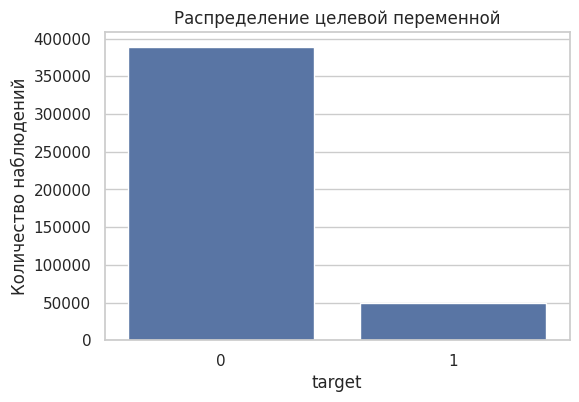

In [50]:
plt.figure(figsize=(6, 4))
sns.barplot(
    x=target_distribution.index.astype(str),
    y=target_distribution["count"]
)
plt.title("Распределение целевой переменной")
plt.xlabel("target")
plt.ylabel("Количество наблюдений")
plt.show()

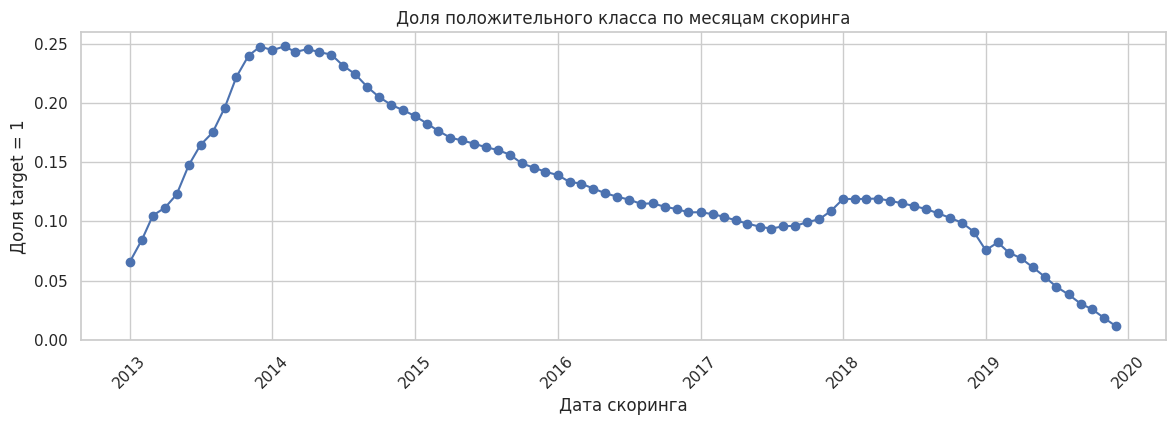

In [51]:
# Доля положительного класса по месяцам
target_by_month = (
    df_model_features
    .groupby(SCORE_DATE_COL)[TARGET]
    .agg(["count", "sum", "mean"])
    .rename(
        columns={
            "count": "observations",
            "sum": "target_1_count",
            "mean": "target_1_share",
        }
    )
    .reset_index()
)

plt.figure(figsize=(14, 4))
plt.plot(
    target_by_month[SCORE_DATE_COL],
    target_by_month["target_1_share"],
    marker="o"
)
plt.title("Доля положительного класса по месяцам скоринга")
plt.xlabel("Дата скоринга")
plt.ylabel("Доля target = 1")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

In [52]:
# Разделим признаки по типам для будущей предобработки
service_columns = [
    ID_COL,
    SCORE_DATE_COL,
    TARGET,
]

date_columns = [
    col for col in df_model_features.columns
    if pd.api.types.is_datetime64_any_dtype(df_model_features[col])
]

categorical_columns = (
    df_model_features
    .drop(columns=service_columns, errors="ignore")
    .select_dtypes(include=["object", "category", "bool"])
    .columns
    .tolist()
)

numeric_columns = (
    df_model_features
    .drop(columns=service_columns + date_columns, errors="ignore")
    .select_dtypes(include=np.number)
    .columns
    .tolist()
)

print(f"Служебные колонки: {service_columns}")
print(f"Колонки с датами: {date_columns}")
print(f"Категориальные признаки: {categorical_columns}")
print(f"Количество числовых признаков: {len(numeric_columns)}")

Служебные колонки: ['ID', 'score_date', 'target']
Колонки с датами: ['score_date', 'дата_регистрации']
Категориальные признаки: ['семейное_положение']
Количество числовых признаков: 47


### Анализ корреляции признаков с помощью phik

Для дополнительной проверки итоговой таблицы оценим корреляцию признаков с помощью коэффициента `phik`.

In [53]:
phik_columns = numeric_columns + categorical_columns + [TARGET]

phik_data = df_model_features[phik_columns].copy()

# Для ускорения расчёта используем сэмпл, если таблица слишком большая
PHIK_SAMPLE_SIZE = 100_000

if len(phik_data) > PHIK_SAMPLE_SIZE:
    phik_data_sample = phik_data.sample(
        n=PHIK_SAMPLE_SIZE,
        random_state=RANDOM_STATE
    )
else:
    phik_data_sample = phik_data.copy()

# Для phik непрерывные признаки нужно передать через interval_cols.
interval_cols = [
    col for col in numeric_columns
    if phik_data_sample[col].nunique(dropna=True) > 10
]

print(f"Размер выборки для phik: {phik_data_sample.shape}")
print(f"Количество interval_cols: {len(interval_cols)}")

phik_matrix = phik_data_sample.phik_matrix(interval_cols=interval_cols)

display(phik_matrix.head())

Размер выборки для phik: (100000, 49)
Количество interval_cols: 43


,возраст,наличие_иждивенцев,доход,сумма_кредита,наличие_ипотеки,кредитный_рейтинг,MCC_5300_prev_month,MCC_5814_prev_month,MCC_5812_prev_month,MCC_5411_prev_month,MCC_3990_prev_month,MCC_5722_prev_month,MCC_4900_prev_month,MCC_другое_prev_month,has_prev_month_transactions,учетная_ставка,уровень_безработицы,инфляция,client_tenure_months,credit_to_income_ratio,family_with_dependents,total_spend_prev_month,food_spend_prev_month,essential_spend_prev_month,discretionary_spend_prev_month,food_spend_share_prev_month,essential_spend_share_prev_month,discretionary_to_essential_ratio_prev_month,MCC_5300_share_prev_month,MCC_5814_share_prev_month,MCC_5812_share_prev_month,MCC_5411_share_prev_month,MCC_3990_share_prev_month,MCC_5722_share_prev_month,MCC_4900_share_prev_month,MCC_другое_share_prev_month,total_spend_to_income_ratio_prev_month,essential_spend_to_income_ratio_prev_month,discretionary_spend_to_income_ratio_prev_month,total_spend_roll_3m_mean,total_spend_roll_6m_mean,total_spend_roll_3m_std,total_spend_vs_3m_mean_ratio,credit_rating_prev_1m,credit_rating_change_1m,credit_rating_roll_3m_mean,credit_rating_vs_3m_mean,семейное_положение,target
возраст,1.000,0.022,0.099,0.099,0.059,0.081,0.060,0.059,0.053,0.068,0.067,0.061,0.060,0.069,0.029,0.029,0.020,0.013,0.085,0.087,0.039,0.076,0.075,0.074,0.074,0.010,0.000,0.000,0.013,0.010,0.000,0.000,0.000,0.000,0.003,0.000,0.090,0.090,0.089,0.079,0.071,0.026,0.048,0.082,0.009,0.086,0.011,0.042,0.201
наличие_иждивенцев,0.022,1.000,0.034,0.028,0.041,0.028,0.012,0.003,0.000,0.014,0.012,0.008,0.011,0.015,0.009,0.000,0.008,0.003,0.026,0.052,0.660,0.025,0.017,0.020,0.022,0.000,0.000,0.000,0.000,0.000,0.001,0.007,0.002,0.004,0.012,0.000,0.025,0.028,0.021,0.026,0.022,0.013,0.015,0.030,0.011,0.031,0.000,0.024,0.049
доход,0.099,0.034,1.000,0.110,0.051,0.071,0.399,0.349,0.361,0.525,0.473,0.449,0.377,0.526,0.007,0.028,0.027,0.011,0.049,0.733,0.031,0.587,0.531,0.570,0.550,0.011,0.003,0.000,0.000,0.011,0.024,0.000,0.000,0.002,0.000,0.000,0.057,0.056,0.055,0.654,0.700,0.323,0.029,0.072,0.000,0.072,0.007,0.061,0.130
сумма_кредита,0.099,0.028,0.110,1.000,0.040,0.065,0.024,0.022,0.015,0.037,0.028,0.023,0.031,0.037,0.014,0.009,0.015,0.000,0.047,0.594,0.032,0.041,0.038,0.037,0.038,0.000,0.000,0.000,0.000,0.000,0.010,0.000,0.013,0.000,0.000,0.000,0.047,0.046,0.044,0.046,0.045,0.000,0.023,0.065,0.009,0.068,0.011,0.067,0.103
наличие_ипотеки,0.059,0.041,0.051,0.040,1.000,0.017,0.018,0.007,0.015,0.016,0.008,0.015,0.010,0.014,0.003,0.015,0.009,0.000,0.010,0.046,0.010,0.020,0.017,0.019,0.022,0.000,0.009,0.009,0.016,0.017,0.008,0.010,0.000,0.007,0.011,0.000,0.013,0.013,0.014,0.012,0.012,0.009,0.008,0.024,0.000,0.021,0.000,0.006,0.029


In [54]:
# Признаки, наиболее связанные с целевой переменной по phik

target_phik = (
    phik_matrix[TARGET]
    .drop(TARGET)
    .sort_values(ascending=False)
)

display(
    target_phik
    .head(20)
    .to_frame("phik_with_target")
)

,phik_with_target
total_spend_to_income_ratio_prev_month,0.592
discretionary_spend_to_income_ratio_prev_month,0.591
essential_spend_to_income_ratio_prev_month,0.571
client_tenure_months,0.474
total_spend_prev_month,0.447
discretionary_spend_prev_month,0.442
total_spend_roll_3m_mean,0.438
essential_spend_prev_month,0.435
food_spend_prev_month,0.431
MCC_5411_prev_month,0.420


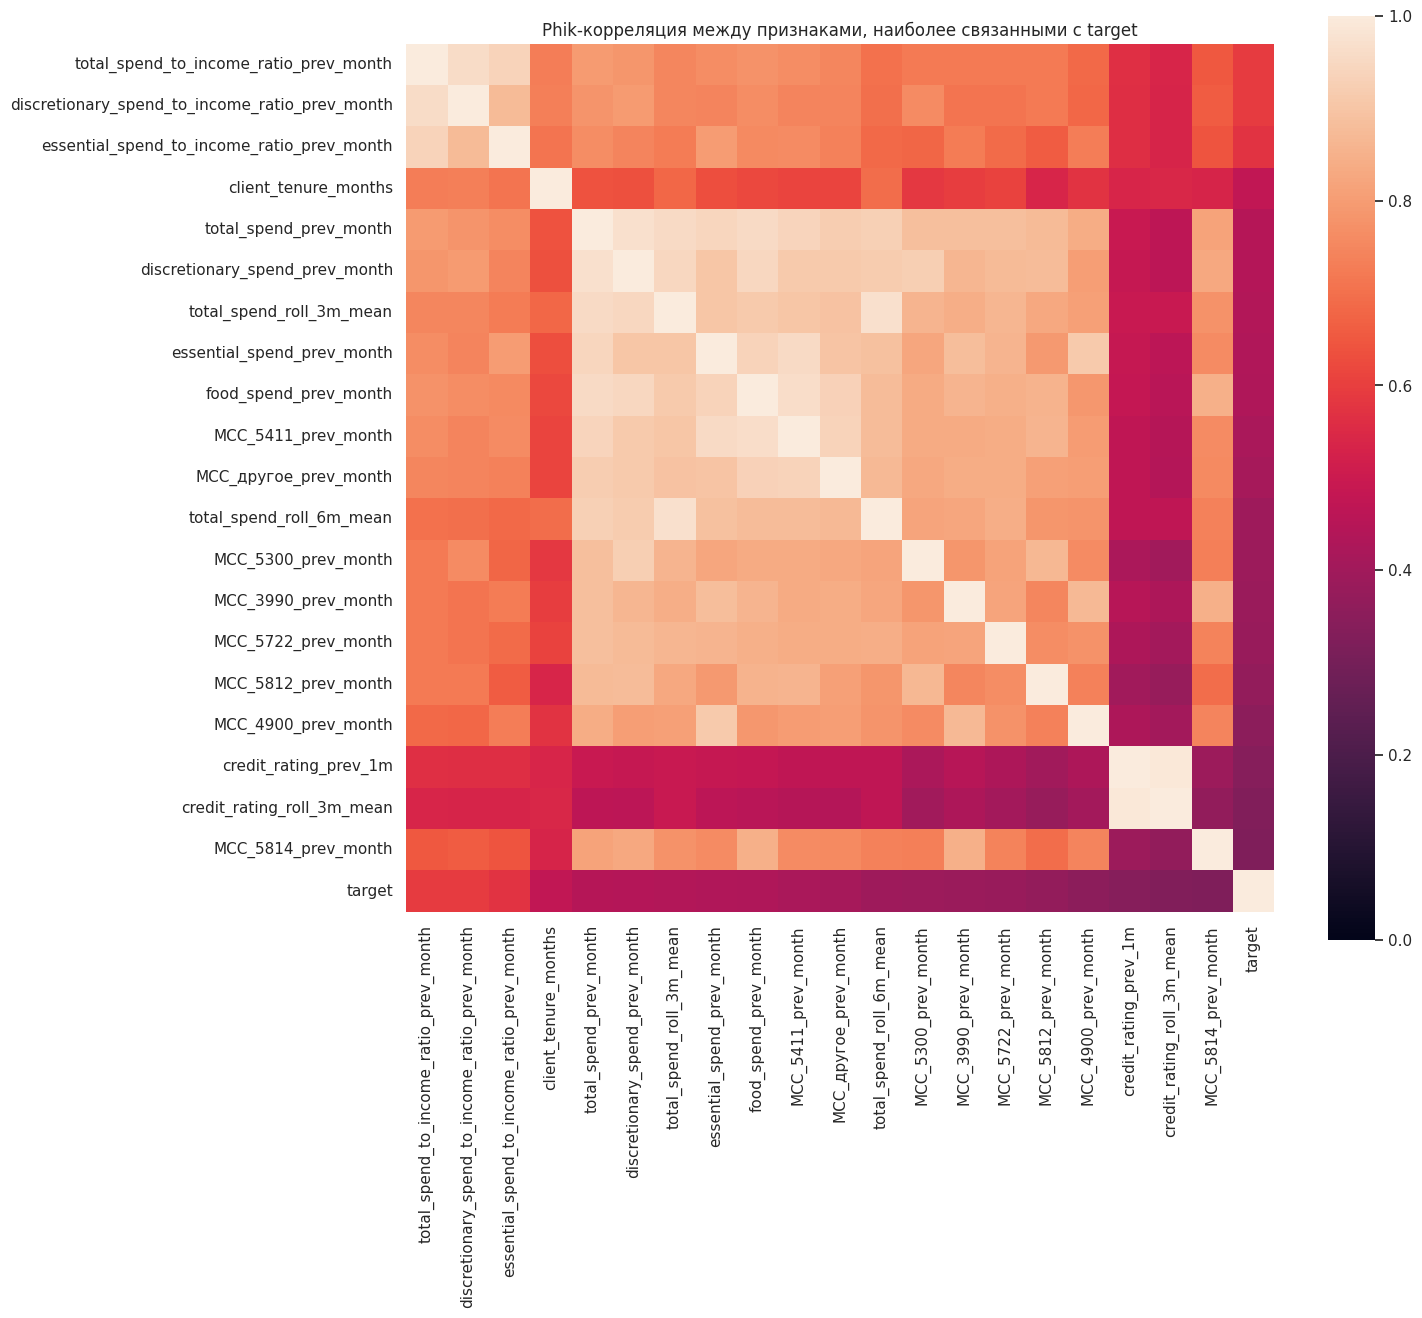

In [55]:
top_phik_features = target_phik.head(20).index.tolist()
heatmap_columns = top_phik_features + [TARGET]

plt.figure(figsize=(14, 12))
sns.heatmap(
    phik_matrix.loc[heatmap_columns, heatmap_columns],
    vmin=0,
    vmax=1,
    annot=False,
    square=True
)

plt.title("Phik-корреляция между признаками, наиболее связанными с target")
plt.show()

In [56]:
HIGH_PHIK_THRESHOLD = 0.90

feature_phik_matrix = phik_matrix.drop(
    index=TARGET,
    columns=TARGET,
    errors="ignore"
)

upper_phik = feature_phik_matrix.where(
    np.triu(np.ones(feature_phik_matrix.shape), k=1).astype(bool)
)

high_phik_pairs = (
    upper_phik
    .stack()
    .reset_index()
)

high_phik_pairs.columns = [
    "feature_1",
    "feature_2",
    "phik_value"
]

high_phik_pairs = (
    high_phik_pairs
    .query("phik_value >= @HIGH_PHIK_THRESHOLD")
    .sort_values("phik_value", ascending=False)
)

print(f"Количество пар признаков с phik >= {HIGH_PHIK_THRESHOLD}: {len(high_phik_pairs)}")

display(high_phik_pairs.head(30))

Количество пар признаков с phik >= 0.9: 29


,feature_1,feature_2,phik_value
1102,credit_rating_prev_1m,credit_rating_roll_3m_mean,0.992
264,кредитный_рейтинг,credit_rating_roll_3m_mean,0.986
880,essential_spend_share_prev_month,discretionary_to_essential_ratio_prev_month,0.971
762,total_spend_prev_month,discretionary_spend_prev_month,0.971
1075,total_spend_roll_3m_mean,total_spend_roll_6m_mean,0.971
262,кредитный_рейтинг,credit_rating_prev_1m,0.969
399,MCC_5411_prev_month,food_spend_prev_month,0.963
1046,total_spend_to_income_ratio_prev_month,discretionary_spend_to_income_ratio_prev_month,0.959
777,total_spend_prev_month,total_spend_roll_3m_mean,0.954
760,total_spend_prev_month,food_spend_prev_month,0.954


### Вывод по phik-корреляции

Анализ `phik` показал, что наиболее сильную связь с целевой переменной имеют признаки, связанные с отношением расходов к доходу клиента: `total_spend_to_income_ratio_prev_month`, `discretionary_spend_to_income_ratio_prev_month`, `essential_spend_to_income_ratio_prev_month`. Это подтверждает полезность добавленных признаков финансовой нагрузки клиента.

Также среди важных признаков оказались стаж клиента, общие расходы за предыдущий месяц, агрегированные расходы по категориям, rolling-признаки расходов и признаки кредитного рейтинга. Это соответствует логике поведенческого скоринга: модель должна учитывать как текущую финансовую нагрузку, так и динамику поведения клиента.

При этом были обнаружены пары признаков с высокой взаимной связью. Например, сильно связаны признаки кредитного рейтинга между собой, rolling-средние расходов за 3 и 6 месяцев, а также агрегированные расходы и отдельные MCC-категории. Это может создавать информационную избыточность и размывать оценку важности признаков.

На данном этапе признаки не удаляются автоматически по результатам `phik`, так как анализ проведён на всей итоговой таблице и используется только как диагностический. Удаление признаков на основе связи с целевой переменной корректнее выполнять после разбиения данных и только на обучающей выборке. Кроме того, ансамблевая модель Random Forest обычно устойчива к скоррелированным признакам, хотя их наличие может усложнять интерпретацию feature importance.

### Вывод по анализу итоговой таблицы

После объединения исходных данных и создания новых признаков была получена итоговая таблица `df_model_features`, содержащая 438 379 наблюдений и 49 столбцов. Каждая строка соответствует паре «клиент — дата скоринга», то есть одному клиенту в конкретный месяц наблюдения.

Дубликатов по паре `ID` и `score_date` не обнаружено. Это означает, что единица наблюдения сохранена корректно: при объединении таблиц и создании признаков строки не были размножены.

В таблице представлены числовые, категориальные и временные признаки. К служебным колонкам относятся `ID`, `score_date` и `target`. Колонка `ID` будет использоваться для группировки наблюдений по клиентам, `score_date` — для учёта временной структуры данных, а `target` — как целевая переменная. Напрямую подавать `ID` и даты в модель как обычные признаки не следует.

В данных есть пропуски в признаках, связанных с предыдущими периодами. Пропуски в MCC-признаках и признаках динамики кредитного рейтинга составляют около 3.08% и связаны с первыми наблюдениями клиентов, для которых отсутствует предыдущий месяц. Пропуски в стандартном отклонении трат за 3 месяца составляют около 6.12%, так как для расчёта стандартного отклонения требуется минимум два предыдущих наблюдения. Эти пропуски являются ожидаемыми и будут обработаны позже в пайплайне предобработки с помощью импьютации.

Целевая переменная имеет выраженный дисбаланс классов. Класс `0`, соответствующий отсутствию дефолта в горизонте прогнозирования, включает 389 015 наблюдений, или 88.74% выборки. Класс `1`, соответствующий появлению просрочки 90+ дней в течение следующих 12 месяцев, включает 49 364 наблюдения, или 11.26% выборки. Соотношение классов составляет примерно 7.9 к 1 в пользу отрицательного класса.

Таким образом, задача является несбалансированной бинарной классификацией. На этапе моделирования необходимо учитывать дисбаланс классов: сравнить модели без балансировки и с применением методов балансировки, например `class_weight`, `RandomOverSampler`, `RandomUnderSampler` или `SMOTE`. Также при оценке качества нельзя ориентироваться только на accuracy, так как высокая точность может быть достигнута за счёт преобладающего класса. Основное внимание нужно уделить бизнес-метрикам: `approval rate`, `default rate` и `missed defaults rate`.

<div style="border:solid #D3D3D3 2px; border-radius: 10px; padding: 15px">
<h3> Комментарий ревьюера <a class="tocSkip"></h3>
<h4> Анализ итоговой таблицы для обучения<a class="tocSkip"></h4>

<div style="border-radius: 10px" class="alert alert-success">
<b>Отлично ✅:</b>  Верно, что выполняешь проверку на баланс классов! При работе с классификаторами это важный шаг, от него зависят наши дальнейшие действия и результаты.
    
</div>

    
<div style="border-radius: 10px" class="alert alert-warning">
<b>Рекомендации💡:</b>

На этом этапе также можно оценить корреляцию (в нашем случае лучше всего подойдет phik), чтобы проверить данные на наличие информационной избыточности. Информационная избыточность (высокая скоррелированность факторов между собой) для всех моделей создает лишнюю нагрузку без заметного улучшения самой модели, а также смазывает оценку важности (скоррелированные признаки объясняют один и тот же эффект, поэтому важность данного эффекта делится между признаками, из-за чего они теряют позиции в рейтинге).

</div>

</span><br><span style="color: purple; font-weight: bold">Добавил подраздел с Корреляцией</span>

## Моделирование

### Базовые модели

1. Подготовьте обучающую, калибровочную и тестовую выборки. Разбейте обучающую на три фолда для последующего использования кросс-валидации. Для оценки качества и калибровки используйте размер выборки, равный 12 месяцам.


2. При необходимости проведите категоризацию данных, применив нужный Encoder и использовав пайплайн.

3. Обучите базовые модели с кросс-валидацией по трём фолдам:
    * Две базовые модели — логистическую регрессию и случайный лес — без балансировки классов в целевой переменной.
    * Логистическую регрессию и случайный лес с балансировкой классов. Выберите метод балансировки самостоятельно. Обязательно примените хотя бы один метод. Можно попробовать несколько и выбрать лучший.
    * Сделайте выводы о работе всех четырёх моделей.

4. Случайный лес с настройками по умолчанию легко переобучается, потому что запоминает обучающую выборку, из-за чего модель может терять в качестве на новых данных. Логистическая регрессия же сразу готова к работе за счёт встроенной L2-регуляризации, которая автоматически контролирует сложность модели.

   Чтобы исправить проблемы модели Random Forest, вам нужно подобрать для неё гиперпараметры с помощью  Optuna. Количество гиперпараметров должно быть не менее трёх. Для оптимизации используйте метрику missed defaults rate.

5. Сравните все полученные модели.

6. Для оценки моделей используйте метрики:
   * accuracy или ROC-AUC,
   * approval rate,
   * default rate,
   * missed defaults rate.

7. Сделайте вывод о работе, проделанной в этом разделе.

### Шаг 1

In [57]:
df = df_model_features.copy()

# Сортируем данные по времени и клиенту
df = (
    df
    .sort_values([SCORE_DATE_COL, ID_COL])
    .reset_index(drop=True)
)

In [58]:
# Для корректного обучения оставляем только те даты скоринга,
# для которых можно полностью наблюдать горизонт дефолта 12 месяцев.
# Иначе распределение Target сильно "плавает" (от 5% на train до 15% на test)

default_events = dataframes["loan_payment_credit"].copy()
default_events["дата_начала_периода"] = pd.to_datetime(
    default_events["дата_начала_периода"],
    errors="coerce"
)

default_events_90plus = default_events[
    default_events["просрочка_дней"] >= DEFAULT_DAYS_THRESHOLD
].copy()

max_default_event_date = default_events_90plus["дата_начала_периода"].max()

# Так как даты указаны первым числом месяца,
# для score_date = 2019-01-01 горизонт включает месяцы до 2019-12-01 включительно.
last_valid_score_date = max_default_event_date - pd.DateOffset(months=11)

print(f"Максимальная дата дефолта 90+: {max_default_event_date}")
print(f"Последняя дата скоринга с полностью наблюдаемым горизонтом: {last_valid_score_date}")

print(f"Размер df до фильтрации по полному горизонту: {df.shape}")

df = df[
    df[SCORE_DATE_COL] <= last_valid_score_date
].copy()

print(f"Размер df после фильтрации по полному горизонту: {df.shape}")
print(f"Диапазон дат скоринга после фильтрации: {df[SCORE_DATE_COL].min()} — {df[SCORE_DATE_COL].max()}")

Максимальная дата дефолта 90+: 2019-12-01 00:00:00
Последняя дата скоринга с полностью наблюдаемым горизонтом: 2019-01-01 00:00:00
Размер df до фильтрации по полному горизонту: (438379, 52)
Размер df после фильтрации по полному горизонту: (342993, 52)
Диапазон дат скоринга после фильтрации: 2013-01-01 00:00:00 — 2019-01-01 00:00:00


In [59]:
# Получим отсортированный список уникальных месяцев скоринга
unique_score_months = (
    df[SCORE_DATE_COL]
    .drop_duplicates()
    .sort_values()
    .reset_index(drop=True)
)

# Последние 12 месяцев — test
test_months = unique_score_months.iloc[-TEST_MONTHS:]

# Предыдущие 12 месяцев — calibration
calibration_months = unique_score_months.iloc[
    -(TEST_MONTHS + CALIBRATION_MONTHS):-TEST_MONTHS
]

# Всё, что раньше — train
train_months = unique_score_months.iloc[
    :-(TEST_MONTHS + CALIBRATION_MONTHS)
]

print(f"Train: {train_months.min()} — {train_months.max()}, месяцев: {len(train_months)}")
print(f"Calibration: {calibration_months.min()} — {calibration_months.max()}, месяцев: {len(calibration_months)}")
print(f"Test: {test_months.min()} — {test_months.max()}, месяцев: {len(test_months)}")

Train: 2013-01-01 00:00:00 — 2017-01-01 00:00:00, месяцев: 49
Calibration: 2017-02-01 00:00:00 — 2018-01-01 00:00:00, месяцев: 12
Test: 2018-02-01 00:00:00 — 2019-01-01 00:00:00, месяцев: 12


In [60]:
# Разделяем данные на train / calibration / test по месяцам скоринга
df_train = df[
    df[SCORE_DATE_COL].isin(train_months)
].copy()

df_calibration = df[
    df[SCORE_DATE_COL].isin(calibration_months)
].copy()

df_test = df[
    df[SCORE_DATE_COL].isin(test_months)
].copy()

print("Размеры выборок:")
print(f"train:       {df_train.shape}")
print(f"calibration: {df_calibration.shape}")
print(f"test:        {df_test.shape}")

print("\nПроверка суммы строк:")
print(len(df_train) + len(df_calibration) + len(df_test))
print(len(df))

Размеры выборок:
train:       (166990, 52)
calibration: (80691, 52)
test:        (95312, 52)

Проверка суммы строк:
342993
342993


In [61]:
def show_split_info(name, df):
    target_info = (
        df[TARGET]
        .value_counts()
        .sort_index()
        .to_frame("count")
    )

    target_info["percent"] = (
        target_info["count"] / len(df) * 100
    ).round(2)

    print("=" * 80)
    print(name)
    print("=" * 80)
    print(f"Размер: {df.shape}")
    print(f"Период: {df[SCORE_DATE_COL].min()} — {df[SCORE_DATE_COL].max()}")
    print(f"Количество месяцев: {df[SCORE_DATE_COL].nunique()}")
    print(f"Количество клиентов: {df[ID_COL].nunique()}")
    print("\nРаспределение target:")
    display(target_info)
    print("\n")


show_split_info("Train", df_train)
show_split_info("Calibration", df_calibration)
show_split_info("Test", df_test)

Train
Размер: (166990, 52)
Период: 2013-01-01 00:00:00 — 2017-01-01 00:00:00
Количество месяцев: 49
Количество клиентов: 7919

Распределение target:


,count,percent
target,,
0,140423,84.090
1,26567,15.910




Calibration
Размер: (80691, 52)
Период: 2017-02-01 00:00:00 — 2018-01-01 00:00:00
Количество месяцев: 12
Количество клиентов: 7885

Распределение target:


,count,percent
target,,
0,72474,89.820
1,8217,10.180




Test
Размер: (95312, 52)
Период: 2018-02-01 00:00:00 — 2019-01-01 00:00:00
Количество месяцев: 12
Количество клиентов: 9178

Распределение target:


,count,percent
target,,
0,85104,89.290
1,10208,10.710


In [62]:
# Дополнительная проверка состава тестовой выборки:
# есть ли в тесте новые клиенты и зрелые клиенты

train_client_ids = set(df_train[ID_COL].unique())

df_test_segments = df_test.copy()

df_test_segments["client_seen_in_train"] = (
    df_test_segments[ID_COL].isin(train_client_ids)
).astype(int)

df_test_segments["test_client_segment"] = np.select(
    [
        df_test_segments["client_seen_in_train"] == 0,
        df_test_segments["client_tenure_months"] <= 1,
        df_test_segments["client_tenure_months"] >= 12,
    ],
    [
        "new_unseen_client",
        "new_by_tenure",
        "mature_client",
    ],
    default="other"
)

test_segment_summary = (
    df_test_segments
    .groupby("test_client_segment")
    .agg(
        rows=(ID_COL, "size"),
        clients=(ID_COL, "nunique"),
        target_1_count=(TARGET, "sum"),
        target_1_rate=(TARGET, "mean"),
    )
    .sort_values("rows", ascending=False)
)

test_segment_summary["target_1_rate"] = (
    test_segment_summary["target_1_rate"] * 100
).round(2)

display(test_segment_summary)

,rows,clients,target_1_count,target_1_rate
test_client_segment,,,,
mature_client,62721,5344,525,0.840
new_unseen_client,32591,3834,9683,29.710


#### Вывод по составу тестовой выборки

В тестовой выборке отдельно проверено наличие зрелых клиентов и новых клиентов, которых модель не видела на обучении. Оба сегмента представлены в достаточном количестве: в тесте есть 62 721 наблюдение по зрелым клиентам и 32 591 наблюдение по новым unseen-клиентам.

При этом доля целевого класса заметно различается между сегментами: среди зрелых клиентов она составляет около 0.84%, а среди новых unseen-клиентов — около 29.71%. Это показывает, что новые клиенты являются более рискованным сегментом и что признаки, связанные с наличием клиентской истории и стажем клиента, важны для модели.

In [63]:
columns_to_exclude = list(set(service_columns + date_columns))

print("\nИсключённые колонки:")
print(columns_to_exclude)

feature_columns = [
    col for col in df.columns
    if col not in columns_to_exclude
]

feature_types = (
    df_train[feature_columns]
    .dtypes
    .astype(str)
    .value_counts()
    .to_frame("columns_count")
)

display(feature_types)


Исключённые колонки:
['target', 'score_date', 'дата_регистрации', 'ID']


,columns_count
float64,38
int64,8
object,1
int32,1


In [64]:
X_train = df_train[feature_columns].copy()
y_train = df_train[TARGET].copy()

X_calib = df_calibration[feature_columns].copy()
y_calib = df_calibration[TARGET].copy()

X_test = df_test[feature_columns].copy()
y_test = df_test[TARGET].copy()

print("Размеры X и y:")
print(f"X_train:       {X_train.shape}, y_train:       {y_train.shape}")
print(f"X_calibration: {X_calib.shape}, y_calibration: {y_calib.shape}")
print(f"X_test:        {X_test.shape}, y_test:        {y_test.shape}")

Размеры X и y:
X_train:       (166990, 48), y_train:       (166990,)
X_calibration: (80691, 48), y_calibration: (80691,)
X_test:        (95312, 48), y_test:        (95312,)


In [65]:
train_groups = df_train[SCORE_DATE_COL].dt.to_period("M").astype(str)

train_cv = GroupTimeSeriesSplit(
    n_splits=CV_FOLDS,
    test_size=12,
    shift_size=12,
    window_type="expanding"
)

cv_splits = list(train_cv.split(X_train, y_train, groups=train_groups))

cv_splits = list(train_cv.split(X_train, y_train, groups=train_groups))

In [66]:
cv_info = []

for fold, (train_idx, valid_idx) in enumerate(cv_splits, start=1):
    fold_train_dates = df_train.iloc[train_idx][SCORE_DATE_COL]
    fold_valid_dates = df_train.iloc[valid_idx][SCORE_DATE_COL]
    
    fold_y_train = y_train.iloc[train_idx]
    fold_y_valid = y_train.iloc[valid_idx]
    
    cv_info.append({
        "fold": fold,
        "train_rows": len(train_idx),
        "valid_rows": len(valid_idx),
        "train_start": fold_train_dates.min(),
        "train_end": fold_train_dates.max(),
        "valid_start": fold_valid_dates.min(),
        "valid_end": fold_valid_dates.max(),
        "train_months": fold_train_dates.nunique(),
        "valid_months": fold_valid_dates.nunique(),
        "train_target_1_share": fold_y_train.mean(),
        "valid_target_1_share": fold_y_valid.mean(),
    })

cv_info = pd.DataFrame(cv_info)

display(cv_info)

,fold,train_rows,valid_rows,train_start,train_end,valid_start,valid_end,train_months,valid_months,train_target_1_share,valid_target_1_share
0,1,14514,35219,2013-01-01,2014-01-01,2014-02-01,2015-01-01,13,12,0.196,0.220
1,2,49733,51243,2013-01-01,2015-01-01,2015-02-01,2016-01-01,25,12,0.213,0.159
2,3,100976,66014,2013-01-01,2016-01-01,2016-02-01,2017-01-01,37,12,0.186,0.118


In [67]:
print("Периоды выборок:")
print(f"Train:       {df_train[SCORE_DATE_COL].min()} — {df_train[SCORE_DATE_COL].max()}")
print(f"Calibration: {df_calibration[SCORE_DATE_COL].min()} — {df_calibration[SCORE_DATE_COL].max()}")
print(f"Test:        {df_test[SCORE_DATE_COL].min()} — {df_test[SCORE_DATE_COL].max()}")

print("\nПроверка временного порядка:")
print(df_train[SCORE_DATE_COL].max() < df_calibration[SCORE_DATE_COL].min())
print(df_calibration[SCORE_DATE_COL].max() < df_test[SCORE_DATE_COL].min())

Периоды выборок:
Train:       2013-01-01 00:00:00 — 2017-01-01 00:00:00
Calibration: 2017-02-01 00:00:00 — 2018-01-01 00:00:00
Test:        2018-02-01 00:00:00 — 2019-01-01 00:00:00

Проверка временного порядка:
True
True


#### Вывод по подготовке выборок

Данные были разделены по временной оси на три части: обучающую, калибровочную и тестовую выборки. Перед разбиением из таблицы были исключены последние месяцы, для которых невозможно полностью наблюдать горизонт прогноза в 12 месяцев. Это позволило избежать искажения целевой переменной на правой границе данных.

В результате обучающая выборка включает период с января 2013 года по январь 2017 года, калибровочная — с февраля 2017 года по январь 2018 года, тестовая — с февраля 2018 года по январь 2019 года. Калибровочная и тестовая выборки охватывают по 12 месяцев, что соответствует требованиям задания.

Распределение целевой переменной в калибровочной и тестовой выборках близкое: доля положительного класса составляет 10.18% и 10.71% соответственно. В обучающей выборке доля положительного класса выше — 15.91%, что может быть связано с временным изменением структуры данных.

Для кросс-валидации на обучающей выборке был подготовлен `GroupTimeSeriesSplit` на 3 фолда. В каждом фолде validation-период составляет 12 месяцев и находится строго позже обучающего периода. Это позволяет учитывать временную структуру данных и не перемешивать прошлые и будущие наблюдения.

<div style="border:solid #D3D3D3 2px; border-radius: 10px; padding: 15px">
<h3> Комментарий ревьюера <a class="tocSkip"></h3>
<h4> Формирование выборок<a class="tocSkip"></h4>
    
<div style="border-radius: 10px" class="alert alert-success">
<b>Отлично ✅:</b> 

При работе с поведенческим скорингом нам важно научиться хорошо предсказывать будущее на основе прошлого. Поскольку данные у нас имеют панельную структуру (наблюдаем во времени сразу нескольких клиентов), нам действительно необходимо позаботиться не только о последовательности данных в тренировочных и оценочных выборок (тренировочный набор должен предшествовать тестовому), но и о том, чтобы месяцы в выборках были изолированы (не попадали сразу в несколько выборок), чтобы не создавались утечки.

</div>
   
    
<div style="border-radius: 10px" class="alert alert-warning">
<b>Рекомендации💡:</b> 

Можно провести еще стресс-тест - помимо основного тестирования выделить в тесте новых клиентов (которых ранее модель не видела) и зрелых, первичную информацию о которых модель уже видела в достаточном количестве - чтобы прицельно проверить, как модель работает с теми и с теми. Только тогда уже сейчас на этапе формирования выборок стоит проверить, набирается ли достаточное количество клиентов каждого типа, чтобы была возможность получить устойчивую оценку качества.
    
</div>

</span><br><span style="color: purple; font-weight: bold">Добавил 1 тест</span>


### Шаг 2

In [68]:
categorical_features = X_train.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

numeric_features = X_train.select_dtypes(
    include=np.number
).columns.tolist()

In [69]:
# Бинарные числовые признаки выделяем отдельно:

binary_numeric_columns = []

for col in numeric_columns:
    unique_values = set(df_model_features[col].dropna().unique())
    
    if unique_values.issubset({0, 1}) and len(unique_values) <= 2:
        binary_numeric_columns.append(col)

continuous_numeric_columns = [
    col for col in numeric_columns
    if col not in binary_numeric_columns
]

print(f"Непрерывных числовых признаков: {len(continuous_numeric_columns)}")
print(f"Бинарных числовых признаков: {len(binary_numeric_columns)}")
print(f"Категориальных признаков: {len(categorical_columns)}")

display(binary_numeric_columns)

Непрерывных числовых признаков: 43
Бинарных числовых признаков: 4
Категориальных признаков: 1


['наличие_иждивенцев',
 'наличие_ипотеки',
 'has_prev_month_transactions',
 'family_with_dependents']

In [70]:
# Для числовых признаков используем заполнение константой
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value=0)),
    ("scaler", StandardScaler())
])

# Бинарные признаки не масштабируем
# Если в них появятся пропуски, заполняем 0 как отдельным осмысленным значением
binary_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value=0))
])

# Пропуски, если появятся, кодируем отдельной категорией
# drop="first" снижает мультиколлинеарность после OHE
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", drop="first"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, continuous_numeric_columns),
        ("bin", binary_transformer, binary_numeric_columns),
        ("cat", categorical_transformer, categorical_columns),
    ],
    remainder="drop"
)

In [71]:
# Проверим, что признаки не пересекаются между группами

feature_groups = [
    set(continuous_numeric_columns),
    set(binary_numeric_columns),
    set(categorical_columns),
]

print("Пересечение num и bin:", feature_groups[0] & feature_groups[1])
print("Пересечение num и cat:", feature_groups[0] & feature_groups[2])
print("Пересечение bin и cat:", feature_groups[1] & feature_groups[2])

selected_features = (
    continuous_numeric_columns
    + binary_numeric_columns
    + categorical_columns
)

print("Всего признаков для модели:", len(selected_features))

Пересечение num и bin: set()
Пересечение num и cat: set()
Пересечение bin и cat: set()
Всего признаков для модели: 48


#### Вывод по подготовке признаков

Для моделирования признаки были разделены на числовые и категориальные. Для числовых признаков подготовлена обработка пропусков с помощью медианы и масштабирование через `StandardScaler`. Для категориальных признаков подготовлена обработка пропусков наиболее частым значением и кодирование через `OneHotEncoder`.

Все преобразования объединены в `ColumnTransformer`, который будет использоваться внутри пайплайнов моделей. Это позволяет выполнять предобработку только на обучающих данных внутри каждого фолда кросс-валидации и не допускать утечки информации из валидационных, калибровочных и тестовых выборок.

#### Корректировка предобработки признаков

В пайплайне предобработки была изменена стратегия заполнения пропусков. Для числовых признаков больше не используется медианная импьютация, так как в задаче с временной структурой это может искажать динамику и создавать неявную утечку информации. Вместо этого применяется заполнение константой `0`, а для временных признаков с отсутствующей историей ранее были добавлены отдельные индикаторы наличия данных.

Категориальные признаки также не заполняются модой: возможные пропуски кодируются отдельной категорией `missing`. При One-Hot Encoding используется `drop="first"`, чтобы снизить мультиколлинеарность, особенно важную для логистической регрессии.

Бинарные числовые признаки выделены в отдельную группу. Они являются категориальными по смыслу, поэтому не масштабируются через `StandardScaler`, а передаются модели как признаки 0/1.

<div style="border:solid #D3D3D3 2px; border-radius: 10px; padding: 15px">
<h3> Комментарий ревьюера <a class="tocSkip"></h3>
    
<h4> Пайплайн для подготовки данных <a class="tocSkip"></h4>
<div style="border-radius: 10px" class="alert alert-success">
<b>Отлично ✅:</b> 
    
* Супер, что не забываем про необходимость цифровизации категориальных данных!
    
    
* Относительно масштабирования. На качество деревянных моделей (дерево, лес, XGBoost, LGBM, CatBoost), на самом деле, оно не окажет никакого влияния, поскольку принцип принятия решения завязан на относительности значений признаков (больше/меньше), а она при масштабировании воздействию не подвергается. Тем не менее масштабирование может немного повлиять на производительность. Но при этом масштабирование важно для методов, основанных на дистанции (KNN, SVM, кластеризация) или вариации (PCA).
    
    С линейными моделями чуть интереснее. На **простую** линейную модель масштабирование, в теории, не окажет никакого влияния на предсказания (однако есть оговорки). Но в некоторых случаях оно все же необходимо.

    <details> <summary> <span style='color:blue' > Развернуть подробнее. </span> </summary>

    Если мы посмотрим на классическое линейное уравнение модели, парметры которого мы оцениваем в процессе обучения, то заметим, что масштабирование никак себя не проявит, поскольку все изменения переменной  просто уйдут в новые коэффициенты:

    $y = \alpha + \beta x$ - без масштабирования
    _____________________________________________________________________________________________________________________

    $y = \alpha_{st} + \beta_{st} \frac{x-mean}{std} = (\alpha_{st} - \frac{\beta_{st}mean}{std}) + (\frac{\beta_{st}}{std}) x$ - со стандартизацией

    При этом $\alpha = (\alpha_{st} - \frac{\beta_{st}mean}{std})$ и $\beta = (\frac{\beta_{st}}{std})$
    _____________________________________________________________________________________________________________________

    $y = \alpha_{mm} + \beta_{mm} \frac{x-min}{max-min} = (\alpha_{mm} - \frac{\beta_{mm}min}{max-min}) + (\frac{\beta_{mm}}{max-min}) x$ - с нормализацией

    При этом $\alpha = (\alpha_{mm} - \frac{\beta_{mm}min}{max-min})$ и $\beta = (\frac{\beta_{mm}}{max-min})$
    _____________________________________________________________________________________________________________________

    Когда же тогда масштабирование необходимо для линейной модели? Ссылки для ознакомления: <a href = 'https://www.listendata.com/2017/04/how-to-standardize-variable-in-regression.html'>тык</a>, <a href = 'https://www.dmitrymakarov.ru/learning/reg/#8-regulyarizatsiya-lineynoy-regressii'>тык</a>. Если кратко резюмировать, то пункты следующие:

    * **Линейные модели с регуляризацией (Ridge, Lasso, Elastic Net)**. Данные модели регулируют те самые коэффициенты, поэтому важно, чтобы масштаб не приводил к тому, что признаки с маленькими значениями будут штафоваться больше (их коэффициенты больше), чем признаки с большими значениями (их коэффициенты меньше). Для Lasso иногда стандартизируют даже бинарные признаки (получаем после OHE), чтобы абсолютно все признаки были в равных условиях. Или же при стандартизации числовых признаков вместно одного стандартного отклонения делят на два, тогда мы получаем примерно равный масштаб с бинарными признаками. Однако острой необходимости в этом нет.

    * **Интерпретация важности признаков.** Сравнивать коэффициенты регрессии по степени влияния на таргет мы можем, только если коэффициенты избавлены от масштаба и приведены к абсолютным значениям.

    * **Разница в масштабах признаков слишком большая.** Мы не можем хранить полностью бесконечные дробные части, поэтому при вычислениях используется некоторое округление. Но из-за того, что признаки имеют слишком разный масштаб, будут сильно различаться и коэффициенты, а значит много чего будет уходить в дробную часть, которую мы частично теряем, начинает страдать точность. Как правило, проблема становится ощутимой, когда разница в масштабах достигает $10^6$.

    * **Используем алгоритм обучения через градиентный спуск (SGD, нейронные сети).** При равномасштабных признаках линии уровня функции потерь имеют округлую форму (вместо элипса при разном масштабе), поэтому алгоритм быстрее и точнее сходится к минимуму (спуск более прямой, а не зигзагообразный).

    * **Используем степени признака (полином) или произведение пары признаков.** Иначе может появляться мультиколлинеарность, что приводит к нестабильности коэффициентов.

  </details>

</div>

<div style="border-radius: 10px" class="alert alert-block alert-danger">
<b>Нужно доработать ❌:</b>

При сборке итоговой таблицы уже упоминала этот момент, сейчас повторюсь - при работе с временными рядами использование общей медианы / моды для заполнение пропусков искажает динамику врменного ряда, создает неявную утечку будущего.
    

</div>
    
<div style="border-radius: 10px" class="alert alert-warning">
<b>Рекомендации💡:</b> 
    
* Линейные модели достаточно критичны к мультиколлинеарности - оценки коэффициентов становятся нестабильными. Несмотря на присутствие встроенной регуляризации в логистической регрессии все же при применении OHE стоит выкидывать одну из категорий.
    
    
* Бинарные признаки тоже являются категориальными, а не количественными, просто изначально заданы числовыми лейблами, с которыми может работать модель. Но обычно их не масштабируют.

</div>

</span><br><span style="color: purple; font-weight: bold">Поправил и обновил вывод</span>

### Шаг 3

In [72]:
def calculate_metrics(y_true, y_proba, threshold=0.5):
    y_pred = (y_proba >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    approval_rate = (tn + fn) / len(y_true)
    default_rate = fn / (tn + fn) if (tn + fn) > 0 else np.nan
    missed_defaults_rate = fn / (fn + tp) if (fn + tp) > 0 else np.nan

    return {
        "roc_auc": roc_auc_score(y_true, y_proba),
        "approval_rate": approval_rate,
        "default_rate": default_rate,
        "missed_defaults_rate": missed_defaults_rate,
    }

In [73]:
def evaluate_model_cv(model_name, model, X, y, cv_splits, threshold=0.5):
    results = []

    for fold, (train_idx, valid_idx) in enumerate(cv_splits, start=1):
        X_fold_train = X.iloc[train_idx]
        y_fold_train = y.iloc[train_idx]

        X_fold_valid = X.iloc[valid_idx]
        y_fold_valid = y.iloc[valid_idx]

        current_model = clone(model)
        current_model.fit(X_fold_train, y_fold_train)

        y_valid_proba = current_model.predict_proba(X_fold_valid)[:, 1]

        fold_metrics = calculate_metrics(
            y_fold_valid,
            y_valid_proba,
            threshold=threshold
        )

        fold_metrics["model"] = model_name
        fold_metrics["fold"] = fold

        results.append(fold_metrics)

    return pd.DataFrame(results)

In [74]:
# Базовые модели

baseline_models = {
    "LogisticRegression": Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", LogisticRegression(
                max_iter=1000,
                random_state=RANDOM_STATE
            ))
        ]
    ),

    "RandomForest": Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", RandomForestClassifier(
                random_state=RANDOM_STATE,
                n_jobs=-1
            ))
        ]
    ),

    "LogisticRegression_balanced": Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", LogisticRegression(
                max_iter=1000,
                class_weight="balanced",
                random_state=RANDOM_STATE
            ))
        ]
    ),

    "RandomForest_balanced": Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", RandomForestClassifier(
                class_weight="balanced",
                random_state=RANDOM_STATE,
                n_jobs=-1
            ))
        ]
    ),
}

In [75]:
baseline_results = []

for model_name, model in baseline_models.items():
    print(f"Обучение модели: {model_name}")

    model_cv_result = evaluate_model_cv(
        model_name=model_name,
        model=model,
        X=X_train,
        y=y_train,
        cv_splits=cv_splits,
        threshold=0.5
    )

    baseline_results.append(model_cv_result)

baseline_results = pd.concat(baseline_results, ignore_index=True)

display(baseline_results)

Обучение модели: LogisticRegression
Обучение модели: RandomForest
Обучение модели: LogisticRegression_balanced
Обучение модели: RandomForest_balanced


,roc_auc,approval_rate,default_rate,missed_defaults_rate,model,fold
0,0.765,0.875,0.186,0.737,LogisticRegression,1
1,0.844,0.935,0.134,0.790,LogisticRegression,2
2,0.884,0.954,0.099,0.799,LogisticRegression,3
3,0.805,0.880,0.175,0.699,RandomForest,1
4,0.874,0.918,0.123,0.708,RandomForest,2
5,0.910,0.942,0.091,0.727,RandomForest,3
6,0.762,0.551,0.092,0.231,LogisticRegression_balanced,1
7,0.845,0.675,0.054,0.229,LogisticRegression_balanced,2
8,0.885,0.733,0.033,0.202,LogisticRegression_balanced,3
9,0.810,0.935,0.195,0.830,RandomForest_balanced,1


In [76]:
baseline_summary = (
    baseline_results
    .groupby("model")
    .agg(
        roc_auc_mean=("roc_auc", "mean"),
        roc_auc_std=("roc_auc", "std"),
        approval_rate_mean=("approval_rate", "mean"),
        default_rate_mean=("default_rate", "mean"),
        missed_defaults_rate_mean=("missed_defaults_rate", "mean"),
    )
    .sort_values("missed_defaults_rate_mean")
)

display(baseline_summary)

,roc_auc_mean,roc_auc_std,approval_rate_mean,default_rate_mean,missed_defaults_rate_mean
model,,,,,
LogisticRegression_balanced,0.830,0.063,0.653,0.060,0.221
RandomForest,0.863,0.054,0.913,0.130,0.711
LogisticRegression,0.831,0.061,0.921,0.140,0.775
RandomForest_balanced,0.864,0.050,0.942,0.141,0.792


#### Комментарий по выбору стратегии балансировки

В рамках проекта была проверена базовая модель без балансировки и модель с выбранной стратегией балансировки классов. Дополнительные методы балансировки, такие как oversampling, undersampling, SMOTE или смешанные подходы, могут быть полезны для дальнейшего исследования, однако в текущем решении основной акцент сделан на соблюдении временной структуры данных, корректной кросс-валидации и последующем подборе порога классификации.

Так как итоговая бизнес-задача решается не только на этапе обучения модели, но и через калибровку вероятностей и подбор порога, финальный баланс между `approval rate`, `default rate` и `missed defaults rate` будет настраиваться позднее. Поэтому на данном этапе выбранная стратегия балансировки используется как базовый рабочий компромисс, а расширенный перебор методов балансировки можно рассматривать как направление дальнейшего улучшения модели.

#### Вывод по базовым моделям

На этапе базового моделирования были обучены четыре модели: логистическая регрессия и случайный лес без балансировки классов, а также логистическая регрессия и случайный лес с балансировкой через `class_weight="balanced"`. Оценка выполнялась с помощью кросс-валидации на трёх временных фолдах.

По ROC-AUC лучшие результаты показали модели случайного леса: `RandomForest_balanced` со средним ROC-AUC 0.864 и `RandomForest` со средним ROC-AUC 0.863. Разница между ними минимальна, поэтому на данном этапе балансировка через `class_weight="balanced"` почти не улучшила ранжирующую способность случайного леса.

Лучшей моделью по метрике `missed defaults rate` стала логистическая регрессия с балансировкой классов. Она пропускает меньше дефолтов, чем остальные базовые модели: средний `missed defaults rate` составил 0.221. При этом её `approval rate` равен 0.653, то есть находится примерно на минимально допустимом уровне 65%. Однако `default rate` остаётся слишком высоким и составляет 0.060, что заметно выше бизнес-ограничения 2%.

Модели без балансировки классов показывают высокий `approval rate`, но хуже выявляют клиентов с будущим дефолтом. Это ожидаемо для несбалансированной задачи: модели склонны чаще предсказывать преобладающий класс `0`, из-за чего растёт доля пропущенных дефолтов.

Ни одна из базовых моделей при стандартном пороге 0.5 не удовлетворяет одновременно всем бизнес-ограничениям: `approval rate` не менее 65%, `default rate` не более 2% и `missed defaults rate` не более 4%. Поэтому далее необходимо перейти к подбору гиперпараметров Random Forest, калибровке вероятностей и последующему подбору оптимального порога классификации.

<div style="border:solid #D3D3D3 2px; border-radius: 10px; padding: 15px">
<h3> Комментарий ревьюера <a class="tocSkip"></h3>
<h4> Первичная оценка моделей<a class="tocSkip"></h4>

<div style="border-radius: 10px" class="alert alert-success">
<b>Отлично ✅:</b> 

* Оценка проведена корректно!


* Здорово, что функционализируешь выполнение повторяющихся действий! Это облегчает визуальную структуру кода и уменьшает влияние человеческого фактора.

</div> 



<div style="border-radius: 10px" class="alert alert-warning">
<b>Рекомендации💡:</b>     

Было бы интересно также поисследовать иные подходы к балансировке, чтобы подобрать оптимальный вариант - сначала понять, какой из них лучше работает с дефолтными настройками леса, а уже затем дополнительно оптимизировать их. 

<details> <summary> <span style='color:blue' > Развернуть подробнее. </span> </summary>

При андерсемплинге мы довольно сильно теряем разнообразие объектов мажоритарного класса. Поэтому такой подход обычно лучше работает либо при менее выраженном дисбалансе, либо при большем объеме данных. Иначе модель может начать хуже распознавать представителей основного класса, а ранжирующая способность может заметно проседать. Это будет видно и по метрикам: модель становится значительно более консервативной, сильно снижает approve rate и теряет гибкость.

При использовании оверсемплинга, наоборот, мы увеличиваем присутствие дефолтов в обучающих данных, из-за чего модель начинает лучше обращать внимание на рискованные объекты. В результате она становится осторожнее: чаще отклоняет пограничных клиентов, жертвуя частью прибыли, но снижая риск пропуска дефолтов. По результатам это буддет выглядеть более оптимальным вариантом - удастся улучшить детект дефолтов без настолько сильной просадки approve rate, как при андерсемплинге.

При этом сейчас мы скорее выбираем подход, который дает наиболее качественное ранжирование риска дефолта, а не финальный баланс approve/default при конкретном пороге. Поэтому на данном этапе более важны:

* ranking quality;
* стабильность метрик;
* способность модели отделять рискованные объекты от хороших клиентов.

Финальная настройка баланса между approval rate и default rate уже будет происходить позже - на этапе калибровки и подбора порога.

Но можно попробовать и промежуточные варианты:

* mixed over/under sampling;
* более мягкие коэффициенты балансировки;
* менее агрессивные настройки oversampling.

Это может помочь найти более гибкий компромисс между пропущенными дефолтами и одобрениями.

Также важно учитывать, что при каждом подходе меняется структура обучающих данных, а значит, и оптимальные гиперпараметры модели будут различаться. Подобрать гиперпараметры для одного варианта балансировки и затем использовать их для остальных, скорее всего, не получится.

</details>


</div>


</span><br><span style="color: purple; font-weight: bold">Добавил обоснование балансировке (+в конце я пробовал экспериментировать с другими методами - улучшения не было)</span>

### Шаг 4

In [77]:
# Взял из прошлого проекта - не зря же делал!

class OptunaClassifierOptimizer:
    """
    Класс для подбора гиперпараметров классификационной модели с помощью Optuna.
    Оптимизирует модель по missed defaults rate на кросс-валидации.
    """

    def __init__(
        self,
        pipeline,
        param_func,
        model_name,
        cv_splits,
        n_trials=20,
        threshold=0.5,
        random_state=42
    ):
        self.pipeline = pipeline
        self.param_func = param_func
        self.model_name = model_name
        self.cv_splits = cv_splits
        self.n_trials = n_trials
        self.threshold = threshold
        self.random_state = random_state

        self.study = None
        self.best_params = None
        self.best_score = None
        self.best_pipeline = None

    def objective(self, trial, X, y):
        params = self.param_func(trial)

        fold_scores = []

        for train_idx, valid_idx in self.cv_splits:
            X_fold_train = X.iloc[train_idx]
            y_fold_train = y.iloc[train_idx]

            X_fold_valid = X.iloc[valid_idx]
            y_fold_valid = y.iloc[valid_idx]

            model_pipeline = clone(self.pipeline)
            model_pipeline.set_params(**params)

            model_pipeline.fit(X_fold_train, y_fold_train)

            y_valid_proba = model_pipeline.predict_proba(X_fold_valid)[:, 1]

            metrics = calculate_metrics(
                y_fold_valid,
                y_valid_proba,
                threshold=self.threshold
            )

            fold_scores.append(metrics["missed_defaults_rate"])

        return np.mean(fold_scores)

    def optimize(self, X, y):
        sampler = TPESampler(seed=self.random_state)

        self.study = optuna.create_study(
            direction="minimize",
            sampler=sampler,
            study_name=self.model_name
        )

        self.study.optimize(
            lambda trial: self.objective(trial, X, y),
            n_trials=self.n_trials,
            show_progress_bar=True
        )

        self.best_params = self.study.best_params
        self.best_score = self.study.best_value

        self.best_pipeline = clone(self.pipeline)
        self.best_pipeline.set_params(**self.best_params)

        return self.best_params, self.best_score

    def show_best_result(self):
        print(f"Модель: {self.model_name}")
        print(f"Лучший missed defaults rate на CV: {self.best_score:.3f}")
        print("Лучшие параметры:")
        display(self.best_params)

In [78]:
rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(
            random_state=RANDOM_STATE,
            n_jobs=-1,
            class_weight="balanced",
            bootstrap=True
        ))
    ]
)

In [79]:
def rf_param_func(trial):
    return {
        "model__n_estimators": trial.suggest_int("model__n_estimators", 80, 160),
        "model__max_depth": trial.suggest_int("model__max_depth", 5, 12),
        "model__min_samples_leaf": trial.suggest_int("model__min_samples_leaf", 10, 50),
        "model__max_features": trial.suggest_categorical(
            "model__max_features",
            ["sqrt", "log2"]
        ),
        "model__max_samples": trial.suggest_float(
            "model__max_samples",
            0.5,
            0.8
        ),
    }

In [80]:
rf_optimizer = OptunaClassifierOptimizer(
    pipeline=rf_pipeline,
    param_func=rf_param_func,
    model_name="RandomForest_Optuna",
    cv_splits=cv_splits,
    n_trials=8,
    threshold=0.5,
    random_state=RANDOM_STATE
)

best_rf_params, best_rf_score = rf_optimizer.optimize(X_train, y_train)

rf_optimizer.show_best_result()

[I 2026-06-01 14:10:19,677] A new study created in memory with name: RandomForest_Optuna
Best trial: 0. Best value: 0.147435:  12%|█▎        | 1/8 [00:16<01:56, 16.60s/it]

[I 2026-06-01 14:10:36,273] Trial 0 finished with value: 0.14743543755694125 and parameters: {'model__n_estimators': 110, 'model__max_depth': 12, 'model__min_samples_leaf': 40, 'model__max_features': 'sqrt', 'model__max_samples': 0.5467983561008608}. Best is trial 0 with value: 0.14743543755694125.


Best trial: 0. Best value: 0.147435:  25%|██▌       | 2/8 [00:32<01:36, 16.08s/it]

[I 2026-06-01 14:10:51,990] Trial 1 finished with value: 0.15022696102535685 and parameters: {'model__n_estimators': 84, 'model__max_depth': 11, 'model__min_samples_leaf': 34, 'model__max_features': 'sqrt', 'model__max_samples': 0.7909729556485983}. Best is trial 0 with value: 0.14743543755694125.


Best trial: 2. Best value: 0.0769638:  38%|███▊      | 3/8 [00:45<01:13, 14.70s/it]

...

Best trial: 6. Best value: 0.0745755:  88%|████████▊ | 7/8 [01:32<00:12, 12.16s/it]

[I 2026-06-01 14:11:51,757] Trial 6 finished with value: 0.07457554666039233 and parameters: {'model__n_estimators': 104, 'model__max_depth': 5, 'model__min_samples_leaf': 38, 'model__max_features': 'sqrt', 'model__max_samples': 0.6485530730333811}. Best is trial 6 with value: 0.07457554666039233.


Best trial: 6. Best value: 0.0745755: 100%|██████████| 8/8 [01:47<00:00, 13.42s/it]

[I 2026-06-01 14:12:06,994] Trial 7 finished with value: 0.1730974051850469 and parameters: {'model__n_estimators': 82, 'model__max_depth': 12, 'model__min_samples_leaf': 20, 'model__max_features': 'sqrt', 'model__max_samples': 0.6560204063533432}. Best is trial 6 with value: 0.07457554666039233.
Модель: RandomForest_Optuna
Лучший missed defaults rate на CV: 0.075
Лучшие параметры:


{'model__n_estimators': 104,
 'model__max_depth': 5,
 'model__min_samples_leaf': 38,
 'model__max_features': 'sqrt',
 'model__max_samples': 0.6485530730333811}

In [81]:
best_rf_pipeline = rf_optimizer.best_pipeline

In [82]:
best_rf_pipeline = clone(rf_pipeline)
best_rf_pipeline.set_params(**best_rf_params)

optimized_rf_results = evaluate_model_cv(
    model_name="RandomForest_Optuna",
    model=best_rf_pipeline,
    X=X_train,
    y=y_train,
    cv_splits=cv_splits,
    threshold=0.5
)

display(optimized_rf_results)

,roc_auc,approval_rate,default_rate,missed_defaults_rate,model,fold
0,0.801,0.434,0.050,0.098,RandomForest_Optuna,1
1,0.860,0.565,0.020,0.070,RandomForest_Optuna,2
2,0.897,0.661,0.010,0.056,RandomForest_Optuna,3


In [83]:
optimized_rf_summary = (
    optimized_rf_results
    .groupby("model")
    .agg(
        roc_auc_mean=("roc_auc", "mean"),
        roc_auc_std=("roc_auc", "std"),
        approval_rate_mean=("approval_rate", "mean"),
        default_rate_mean=("default_rate", "mean"),
        missed_defaults_rate_mean=("missed_defaults_rate", "mean"),
    )
)

display(optimized_rf_summary)

,roc_auc_mean,roc_auc_std,approval_rate_mean,default_rate_mean,missed_defaults_rate_mean
model,,,,,
RandomForest_Optuna,0.853,0.049,0.553,0.026,0.075


#### Вывод по подбору гиперпараметров Random Forest

Для модели Random Forest был выполнен подбор гиперпараметров с помощью Optuna. В качестве целевой метрики оптимизации использовалась `missed defaults rate`, так как для задачи поведенческого скоринга важно минимизировать долю пропущенных дефолтов.

После подбора гиперпараметров модель показала средний `missed defaults rate = 0.075`, что заметно лучше результатов базовых моделей Random Forest при стандартном пороге 0.5. При этом `default rate = 0.026`, то есть модель приблизилась к бизнес-ограничению по доле дефолтов среди одобренных клиентов, но всё ещё немного превышает целевой уровень 2%.

Средний `approval rate = 0.553`, что ниже требуемого уровня 65%. Это означает, что при стандартном пороге 0.5 модель работает слишком консервативно: она лучше отсекает рискованных клиентов, но слишком часто относит клиентов к группе риска.

ROC-AUC модели после подбора гиперпараметров составил 0.853. Это немного ниже, чем у базовых моделей случайного леса, однако оптимизация была направлена не на максимизацию ROC-AUC, а на снижение `missed defaults rate`. Поэтому дальнейший этап будет состоять не в выборе стандартного порога 0.5, а в калибровке вероятностей и подборе такого порога, который обеспечит компромисс между `approval rate`, `default rate` и `missed defaults rate`.

### Шаг 5-7

In [84]:
all_cv_summary = pd.concat(
    [baseline_summary, optimized_rf_summary],
    axis=0
).sort_values("missed_defaults_rate_mean")

display(all_cv_summary)

,roc_auc_mean,roc_auc_std,approval_rate_mean,default_rate_mean,missed_defaults_rate_mean
model,,,,,
RandomForest_Optuna,0.853,0.049,0.553,0.026,0.075
LogisticRegression_balanced,0.830,0.063,0.653,0.060,0.221
RandomForest,0.863,0.054,0.913,0.130,0.711
LogisticRegression,0.831,0.061,0.921,0.140,0.775
RandomForest_balanced,0.864,0.050,0.942,0.141,0.792


### Общий вывод по сравнению моделей и разделу моделирования

В разделе моделирования были подготовлены обучающая, калибровочная и тестовая выборки с учётом временной структуры данных. Калибровочная и тестовая выборки включают по 12 месяцев, а кросс-валидация на обучающей выборке была выполнена с помощью `GroupTimeSeriesSplit` на трёх фолдах.

Для моделирования были подготовлены пайплайны предобработки. Непрерывные числовые признаки заполнялись константой и масштабировались, бинарные числовые признаки были выделены в отдельную группу и не масштабировались, а категориальные признаки кодировались с помощью `OneHotEncoder(drop="first")`. Такой подход позволяет выполнять все преобразования внутри пайплайна, избегать утечки данных между обучающей и валидационной частями и не использовать медианную/модальную импьютацию для временно-зависимых данных.

На базовом этапе были обучены четыре модели: логистическая регрессия и случайный лес без балансировки, а также логистическая регрессия и случайный лес с балансировкой классов. Дополнительно для Random Forest был выполнен подбор гиперпараметров с помощью Optuna. Оптимизация проводилась по метрике `missed defaults rate`, так как для задачи поведенческого скоринга важно минимизировать долю пропущенных дефолтов.

По результатам кросс-валидации наибольший ROC-AUC показали модели случайного леса: `RandomForest_balanced` со средним ROC-AUC 0.864 и `RandomForest` со средним ROC-AUC 0.863. Это говорит о хорошей ранжирующей способности случайного леса. Однако при стандартном пороге 0.5 обе модели пропускают слишком много дефолтов: `missed defaults rate` составляет 0.792 и 0.711 соответственно.

Лучший результат по метрике `missed defaults rate` показала модель `RandomForest_Optuna`: среднее значение составило 0.075. По сравнению с базовыми моделями случайного леса она значительно лучше выявляет будущие дефолты. При этом `default rate` снизился до 0.026, то есть модель приблизилась к бизнес-ограничению 2%, но всё ещё немного его превышает.

Компромиссной моделью на стандартном пороге 0.5 также выглядит `LogisticRegression_balanced`: она достигает `approval rate = 0.653`, то есть примерно соответствует минимальному требованию по уровню одобрения. Однако её `default rate = 0.060` и `missed defaults rate = 0.221` остаются слишком высокими для бизнес-ограничений. Кроме того, её ROC-AUC ниже, чем у моделей случайного леса.

Модели без балансировки классов имеют высокий `approval rate`, но плохо выявляют будущие дефолты. Это ожидаемо для несбалансированной задачи: модели чаще относят клиентов к преобладающему классу `0`, из-за чего пропускают значительную часть рискованных клиентов.

Таким образом, для дальнейшей работы выбирается модель `RandomForest_Optuna`. Она не является лучшей по ROC-AUC, но лучше остальных рассмотренных моделей снижает долю пропущенных дефолтов и долю дефолтов среди одобренных клиентов при стандартном пороге 0.5. При этом ни одна из моделей при стандартном пороге не удовлетворяет одновременно всем бизнес-ограничениям. Поэтому на следующем этапе необходимо обучить выбранную модель на полной обучающей выборке, выполнить калибровку вероятностей и подобрать оптимальный порог классификации по бизнес-метрикам.

<div style="border:solid #D3D3D3 2px; border-radius: 10px; padding: 15px">
<h3> Комментарий ревьюера <a class="tocSkip"></h3>
    
<h4> Подбор гиперпараметров<a class="tocSkip"></h4>

<div style="border-radius: 10px" class="alert alert-success">
<b>Отлично ✅:</b> 
    
* По самой оптимизации все супер! 


* Поясню по поводу метрики, почему акцент делаем именно на пропущенных дефолтах. Основная задача нашей модели - хорошо детектить дефолты, делать как можно меньше ошибок в этом плане. Поиск баланса с одобрениями не входит в задачу модели, поэтому ни классические метрики по типу ROC-AUC, ни доля одобрений, ни доля дефолтных одобрений нам не подходят, поскольку будет учитываться в том числе то, сколько мы одобряем. Находить баланс с одобрениями лучше через выбор порога, учитывая соотношение упущенной выгоды и риска потерь. Порог можно двигать в ту или иную сторону, когда мы хотим изменить приоритеты. Стоимость той или иной ошибки может быть разной, в банковской сфере потери обычно обходятся дороже, чем упущенная выгода (лучше заработаем меньше, но сохраним экономический баланс среди текущих клиентов), поэтому гибкость лучше оставить именно на уровне выбора порога.

</div>

## Калибровка модели и пересчёт результатов

* Проведите калибровку лучшей версии модели. Используйте отдельную калибровочную выборку.
* Используйте метод, подходящий для случайного леса.
* Постройте график калибровки.
* Сделайте вывод, оцените результаты с помощью коэффициента Бриера.

In [85]:
best_rf_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value=0,
                                                                                 strategy='constant')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['возраст', 'доход',
                                                   'сумма_кредита',
                                                   'кредитный_рейтинг',
                                                   'MCC_5300_prev_month',
                                                   'MCC_5814_prev_month',
                                                   'MCC_5812_prev_month',
                                                   'MCC_5411_prev_month',
                                                   'MCC_3990_prev_month',
                                                   'MCC_572...
                                                   'family_with_dependents']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='missing',
                                                                                 strategy='constant')),
                                                                  ('encoder',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['семейное_положение'])])),
                ('model',
                 RandomForestClassifier(class_weight='balanced', max_depth=5,
                                        max_samples=0.6485530730333811,
                                        min_samples_leaf=38, n_estimators=104,
                                        n_jobs=-1, random_state=42))])

In [86]:
y_calibration_proba_before = best_rf_pipeline.predict_proba(X_calib)[:, 1]

brier_before = brier_score_loss(
    y_calib,
    y_calibration_proba_before
)

print(f"Brier score до калибровки: {brier_before:.5f}")

Brier score до калибровки: 0.10639


In [87]:
calibrated_rf = CalibratedClassifierCV(
    estimator=best_rf_pipeline,
    method="isotonic",
    cv="prefit"
)

calibrated_rf.fit(X_calib, y_calib)

CalibratedClassifierCV(cv='prefit',
                       estimator=Pipeline(steps=[('preprocessor',
                                                  ColumnTransformer(transformers=[('num',
                                                                                   Pipeline(steps=[('imputer',
                                                                                                    SimpleImputer(fill_value=0,
                                                                                                                  strategy='constant')),
                                                                                                   ('scaler',
                                                                                                    StandardScaler())]),
                                                                                   ['возраст',
                                                                                    'доход',
                                                                                    'сумма_кредита',
                                                                                    'кредитный_рейтинг',
                                                                                    'MCC_5300_prev_month',
                                                                                    'MCC_5814_prev_month',
                                                                                    'MCC_5812_prev_month',
                                                                                    'MCC_54...
                                                                                   Pipeline(steps=[('imputer',
                                                                                                    SimpleImputer(fill_value='missing',
                                                                                                                  strategy='constant')),
                                                                                                   ('encoder',
                                                                                                    OneHotEncoder(drop='first',
                                                                                                                  handle_unknown='ignore'))]),
                                                                                   ['семейное_положение'])])),
                                                 ('model',
                                                  RandomForestClassifier(class_weight='balanced',
                                                                         max_depth=5,
                                                                         max_samples=0.6485530730333811,
                                                                         min_samples_leaf=38,
                                                                         n_estimators=104,
                                                                         n_jobs=-1,
                                                                         random_state=42))]),
                       method='isotonic')

In [88]:
y_calibration_proba_after = calibrated_rf.predict_proba(X_calib)[:, 1]

brier_after = brier_score_loss(
    y_calib,
    y_calibration_proba_after
)

print(f"Brier score до калибровки: {brier_before:.5f}")
print(f"Brier score после калибровки: {brier_after:.5f}")

Brier score до калибровки: 0.10639
Brier score после калибровки: 0.06479


In [89]:
calibration_metrics = pd.DataFrame([
    {
        "model": "RandomForest_Optuna_before_calibration",
        "brier_score": brier_before,
        **calculate_metrics(
            y_calib,
            y_calibration_proba_before,
            threshold=0.5
        )
    },
    {
        "model": "RandomForest_Optuna_after_calibration",
        "brier_score": brier_after,
        **calculate_metrics(
            y_calib,
            y_calibration_proba_after,
            threshold=0.5
        )
    }
])

display(calibration_metrics)

,model,brier_score,roc_auc,approval_rate,default_rate,missed_defaults_rate
0,RandomForest_Optuna_before_calibration,0.106,0.915,0.708,0.008,0.053
1,RandomForest_Optuna_after_calibration,0.065,0.916,0.972,0.088,0.840


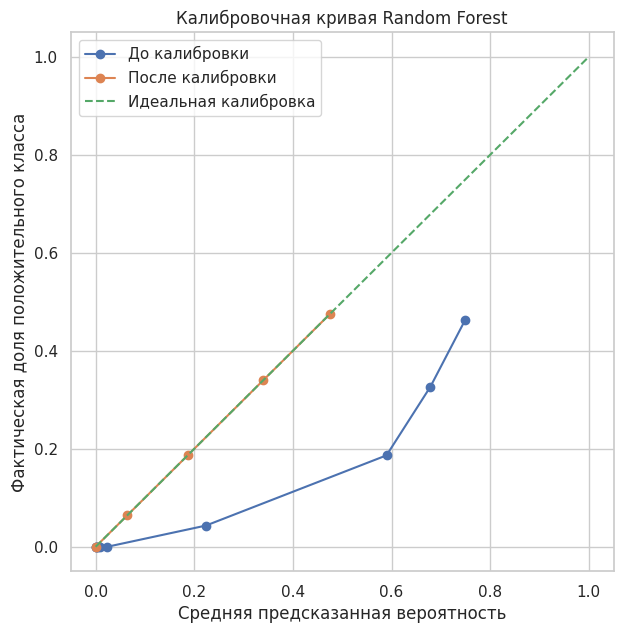

In [90]:
prob_true_before, prob_pred_before = calibration_curve(
    y_calib,
    y_calibration_proba_before,
    n_bins=10,
    strategy="quantile"
)

prob_true_after, prob_pred_after = calibration_curve(
    y_calib,
    y_calibration_proba_after,
    n_bins=10,
    strategy="quantile"
)

plt.figure(figsize=(7, 7))

plt.plot(
    prob_pred_before,
    prob_true_before,
    marker="o",
    label="До калибровки"
)

plt.plot(
    prob_pred_after,
    prob_true_after,
    marker="o",
    label="После калибровки"
)

plt.plot([0, 1], [0, 1], linestyle="--", label="Идеальная калибровка")

plt.title("Калибровочная кривая Random Forest")
plt.xlabel("Средняя предсказанная вероятность")
plt.ylabel("Фактическая доля положительного класса")
plt.legend()
plt.grid(True)
plt.show()

In [91]:
best_calibrated_model = calibrated_rf

### Комментарий по проверке калибровки

В качестве дополнительной проверки калибровочную выборку можно было бы разделить на две временные части: на первой выполнить калибровку вероятностей, а на второй оценить качество калибровки. В текущем решении такой дополнительный стресс-тест не проводится, так как калибровочная выборка уже ограничена 12 месяцами, а дополнительное деление уменьшило бы объём данных для настройки калибратора.

Для контроля обобщающей способности используется отдельная тестовая выборка, которая не участвует ни в обучении модели, ни в калибровке, ни в подборе порога. Поэтому финальная оценка качества модели выполняется на независимом временном тесте.

### Вывод по калибровке модели

Для выбранной модели `RandomForest_Optuna` была проведена калибровка вероятностей на отдельной калибровочной выборке. В качестве метода использовалась изотоническая калибровка, так как случайный лес часто выдаёт неидеально откалиброванные вероятности, а размер калибровочной выборки позволяет использовать более гибкий метод калибровки.

После калибровки коэффициент Бриера снизился с 0.106 до 0.065. Это означает, что откалиброванные вероятности стали лучше соответствовать фактической частоте дефолтов. ROC-AUC практически не изменился: до калибровки он составлял 0.915, после калибровки — 0.916. Это ожидаемо, так как калибровка в основном меняет шкалу вероятностей, а не порядок ранжирования клиентов по уровню риска.

При стандартном пороге 0.5 бизнес-метрики после калибровки ухудшились. `Approval rate` вырос с 0.708 до 0.972, но вместе с этим `default rate` увеличился с 0.008 до 0.088, а `missed defaults rate` — с 0.053 до 0.840. Это говорит о том, что после калибровки большинство клиентов получает вероятность дефолта ниже 0.5 и поэтому относится моделью к надёжным. В результате стандартный порог 0.5 становится слишком мягким и пропускает значительную часть будущих дефолтов.

До калибровки модель при пороге 0.5 была ближе к бизнес-ограничениям: `approval rate` превышал 65%, `default rate` был ниже 2%, но `missed defaults rate` всё ещё превышал целевой уровень 4%. После калибровки качество вероятностных оценок улучшилось по Brier score, однако для принятия бизнес-решений стандартный порог 0.5 не подходит.

Таким образом, калибровка улучшила вероятностную интерпретацию предсказаний модели, но финальное решение должно приниматься не по стандартному порогу 0.5, а через отдельный подбор оптимального порога с учётом трёх бизнес-метрик: `approval rate`, `default rate` и `missed defaults rate`.

<div style="border:solid #D3D3D3 2px; border-radius: 10px; padding: 15px">
<h3> Комментарий ревьюера <a class="tocSkip"></h3>
<h4> Калибровка модели <a class="tocSkip"></h4>

<div style="border-radius: 10px" class="alert alert-success">
<b>Отлично ✅:</b> 
    
* По коду калибровки сейчас все окей!


* Для больших объемов данных и моделей на основе деревьев действительно лучше использовать изотонический подход.
    

* Здорово, что поясняешь важный нюанс - калибровка не влияет на ранжирующие способности модели, это не способ поднятия ее качества, это лишь способ изменения распределения вероятностей, но их порядок остается прежним. А для того, чтобы достгнуть целевых результатов, для откалиброванной модели требуется пересмотр порога, дефолтный не подходит, поскольку мы сместили вероятности.
    
</div>
    
<div style="border-radius: 10px" class="alert alert-warning"> 
<b>Рекомендации💡:</b> 

Чтобы отслеживать переобучаемость калибровки, стоит разделить калибровочную выборку на две части по месяцам - на одной откалибровать, на другой посмотреть результаты калибровки. 
  
</div>


## Поиск порога решения

* Используя откалиброванную модель и калибровочную выборку, найдите порог, при котором будут достигнуты заданные в постановке задачи значения метрик:
    * approval rate — не менее 65%;
    * default rate — не более 2%;
    * missed defaults rate — не более 4%.
    
* Сделайте вывод о достигнутых в этом разделе результатах.

In [92]:
def evaluate_thresholds(y_true, y_proba, thresholds):
    results = []

    for threshold in thresholds:
        metrics = calculate_metrics(
            y_true=y_true,
            y_proba=y_proba,
            threshold=threshold
        )

        results.append({
            "threshold": threshold,
            **metrics
        })

    return pd.DataFrame(results)

In [93]:
# До этого пробовал "простые" пороги - ничего не вышло

unique_thresholds = np.sort(y_calibration_proba_after.unique()) \
    if isinstance(y_calibration_proba_after, pd.Series) \
    else np.sort(np.unique(y_calibration_proba_after))

thresholds = np.r_[0, unique_thresholds, 1]

threshold_results = evaluate_thresholds(
    y_true=y_calib,
    y_proba=y_calibration_proba_after,
    thresholds=thresholds
)

valid_thresholds = threshold_results[
    (threshold_results["approval_rate"] >= MIN_APPROVAL_RATE)
    & (threshold_results["default_rate"] <= MAX_DEFAULT_RATE)
    & (threshold_results["missed_defaults_rate"] <= MAX_MISSED_DEFAULTS_RATE)
].copy()

print(f"Количество подходящих порогов: {len(valid_thresholds)}")
display(valid_thresholds)

Количество подходящих порогов: 4


,threshold,roc_auc,approval_rate,default_rate,missed_defaults_rate
11,0.076,0.916,0.654,0.001,0.007
12,0.076,0.916,0.692,0.005,0.035
13,0.090,0.916,0.692,0.005,0.035
14,0.090,0.916,0.692,0.005,0.035


In [94]:
if len(valid_thresholds) > 0:
    # Если есть пороги, удовлетворяющие всем бизнес-ограничениям,
    # выбираем среди них порог с максимальным approval_rate
    best_threshold_row = (
        valid_thresholds
        .sort_values(
            ["approval_rate", "default_rate", "missed_defaults_rate"],
            ascending=[False, True, True]
        )
        .iloc[0]
    )
    
    print("Выбран порог, удовлетворяющий всем бизнес-ограничениям:")

else:
    # Если порогов, удовлетворяющих всем лимитам, нет,
    # выбираем лучший компромисс среди порогов с approval_rate >= 65%
    threshold_candidates = threshold_results[
        threshold_results["approval_rate"] >= MIN_APPROVAL_RATE
    ].copy()

    best_threshold_row = (
        threshold_candidates
        .sort_values(
            ["missed_defaults_rate", "default_rate", "approval_rate"],
            ascending=[True, True, False]
        )
        .iloc[0]
    )

    print("Порогов, удовлетворяющих всем ограничениям, не найдено. Выбран ближайший компромисс:")

best_threshold = best_threshold_row["threshold"]

display(best_threshold_row.to_frame().T)

Выбран порог, удовлетворяющий всем бизнес-ограничениям:


,threshold,roc_auc,approval_rate,default_rate,missed_defaults_rate
14,0.090,0.916,0.692,0.005,0.035


In [95]:
calibration_threshold_metrics = pd.DataFrame([
    {
        "threshold": best_threshold,
        **calculate_metrics(
            y_true=y_calib,
            y_proba=y_calibration_proba_after,
            threshold=best_threshold
        )
    }
])

display(calibration_threshold_metrics)

,threshold,roc_auc,approval_rate,default_rate,missed_defaults_rate
0,0.090,0.916,0.692,0.005,0.035


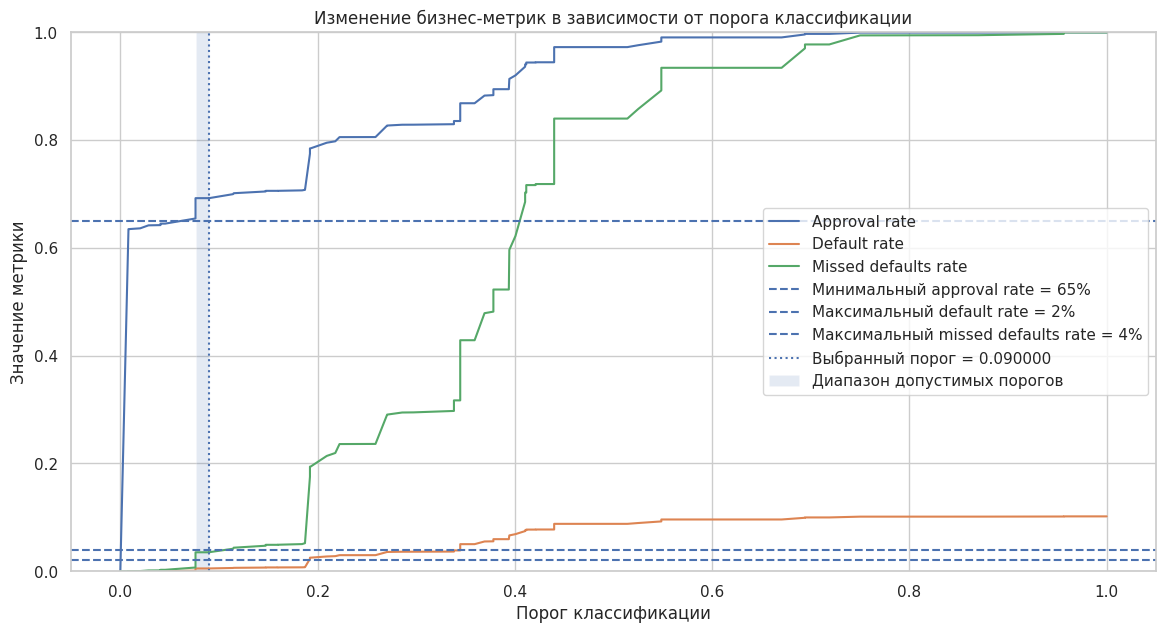

In [96]:
threshold_results_sorted = threshold_results.sort_values("threshold")

plt.figure(figsize=(14, 7))

plt.plot(
    threshold_results_sorted["threshold"],
    threshold_results_sorted["approval_rate"],
    label="Approval rate"
)

plt.plot(
    threshold_results_sorted["threshold"],
    threshold_results_sorted["default_rate"],
    label="Default rate"
)

plt.plot(
    threshold_results_sorted["threshold"],
    threshold_results_sorted["missed_defaults_rate"],
    label="Missed defaults rate"
)

plt.axhline(
    MIN_APPROVAL_RATE,
    linestyle="--",
    label=f"Минимальный approval rate = {MIN_APPROVAL_RATE:.0%}"
)

plt.axhline(
    MAX_DEFAULT_RATE,
    linestyle="--",
    label=f"Максимальный default rate = {MAX_DEFAULT_RATE:.0%}"
)

plt.axhline(
    MAX_MISSED_DEFAULTS_RATE,
    linestyle="--",
    label=f"Максимальный missed defaults rate = {MAX_MISSED_DEFAULTS_RATE:.0%}"
)

plt.axvline(
    best_threshold,
    linestyle=":",
    label=f"Выбранный порог = {best_threshold:.6f}"
)

if len(valid_thresholds) > 0:
    plt.axvspan(
        valid_thresholds["threshold"].min(),
        valid_thresholds["threshold"].max(),
        alpha=0.15,
        label="Диапазон допустимых порогов"
    )

plt.title("Изменение бизнес-метрик в зависимости от порога классификации")
plt.xlabel("Порог классификации")
plt.ylabel("Значение метрики")
plt.ylim(0, 1)
plt.legend()
plt.grid(True)
plt.show()

In [97]:
threshold_comparison = pd.concat(
    [
        calibration_metrics[
            calibration_metrics["model"].isin([
                "RandomForest_Optuna_before_calibration",
                "RandomForest_Optuna_after_calibration"
            ])
        ][[
            "model",
            "approval_rate",
            "default_rate",
            "missed_defaults_rate"
        ]],
        calibration_threshold_metrics.assign(
            model=f"RandomForest_Optuna_after_calibration_threshold_{best_threshold:.6f}"
        )[[
            "model",
            "approval_rate",
            "default_rate",
            "missed_defaults_rate"
        ]]
    ],
    ignore_index=True
)

display(threshold_comparison)

,model,approval_rate,default_rate,missed_defaults_rate
0,RandomForest_Optuna_before_calibration,0.708,0.008,0.053
1,RandomForest_Optuna_after_calibration,0.972,0.088,0.840
2,RandomForest_Optuna_after_calibration_threshol...,0.692,0.005,0.035


### Вывод по поиску порога

Поиск порога классификации проводился на калибровочной выборке с использованием откалиброванных вероятностей модели. Стандартный порог 0.5 после калибровки оказался слишком мягким: модель одобряла слишком много клиентов, из-за чего заметно возрастали `default rate` и `missed defaults rate`.

В результате перебора порогов был найден порог `0.09`, который удовлетворяет всем заданным бизнес-ограничениям. При этом `approval rate` составил 0.692, что выше минимально допустимого уровня 65%. `Default rate` составил 0.005, что ниже максимального ограничения 2%. `Missed defaults rate` составил 0.035, что также ниже допустимого максимума 4%.

По сравнению со стандартным порогом 0.5 после калибровки выбранный порог значительно улучшает контроль риска: `default rate` снижается с 0.088 до 0.005, а `missed defaults rate` — с 0.840 до 0.035. При этом `approval rate` уменьшается с 0.972 до 0.692, то есть модель становится более осторожной и отклоняет больше рискованных клиентов.

По сравнению с моделью до калибровки при пороге 0.5 выбранный порог также даёт более безопасный результат: `default rate` снижается с 0.008 до 0.005, а `missed defaults rate` — с 0.053 до 0.035. При этом `approval rate` остаётся выше требуемого бизнес-минимума.

Таким образом, для дальнейшей проверки на тестовой выборке выбран порог `0.09`. Он обеспечивает приемлемый баланс между уровнем одобрения клиентов и контролем риска дефолтов. В дальнейшем этот порог можно будет корректировать в пределах допустимых бизнес-ограничений: более высокий порог увеличит число одобрений, но может повысить риск пропущенных дефолтов, а более низкий порог сделает модель более консервативной.

<div style="border:solid #D3D3D3 2px; border-radius: 10px; padding: 15px">
<h3> Комментарий ревьюера <a class="tocSkip"></h3>
<h4> Поиск порога<a class="tocSkip"></h4>

<div style="border-radius: 10px" class="alert alert-success">
<b>Отлично ✅:</b> По коду все супер!

</div> 
    
<div style="border-radius: 10px" class="alert alert-warning">
<b>Рекомендации💡:</b>
    
 
* Было бы неплохо визуализировать результаты, как менялись метрики при том или ином пороге. Отобразить также наши лимиты. На графике можно обозначить диапазон порогов, которые удовлетворяют установленным лимитам по бизнем-метрикам.


* Хотелось бы также увидеть сравнение метрик относительно тех, что были на предыдущих этапах.


* Можно также отметить, что порог в целом можно двигать в пределах заданных лимитов в зависимости от того, чем мы готовы в той или иной мере пожертвовать - одобрениями или небольшим количеством нераспознанных дефолтов. При подборе порога часто еще используют финансовые показаели, чтобы напрямую регулировать именно баланс прибыли и убытков. Но в плане кредитов это довольно сложно рассчитывается, поэтому реализуем сейчас более простой вариант через метрики.

</div>

</span><br><span style="color: purple; font-weight: bold">Все добавил (график, сравнительную таблицу) + Изменил вывод (так как порог все же удалось найти!)</span>


## Анализ матрицы ошибок

* Оцените стабильность модели на тестовых данных. Для этого постройте:
    * матрицу ошибок на калибровочных данных;
    * матрицу классификации на тестовых данных.
* Сделайте вывод о моделях, рассчитав классические метрики машинного обучения и указанные в ТЗ бизнес-метрики.
* Сделайте вывод о стабильности модели.

In [98]:
# y_calibration_proba_after
y_test_proba = best_calibrated_model.predict_proba(X_test)[:, 1]

y_calibration_pred = (y_calibration_proba_after >= best_threshold).astype(int)
y_test_pred = (y_test_proba >= best_threshold).astype(int)

In [99]:
def get_final_metrics(y_true, y_proba, y_pred, threshold):
    business_metrics = calculate_metrics(
        y_true=y_true,
        y_proba=y_proba,
        threshold=threshold
    )

    return {
        "threshold": threshold,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_proba),
        "brier_score": brier_score_loss(y_true, y_proba),
        "approval_rate": business_metrics["approval_rate"],
        "default_rate": business_metrics["default_rate"],
        "missed_defaults_rate": business_metrics["missed_defaults_rate"],
    }

In [100]:
final_metrics = pd.DataFrame([
    {
        "sample": "calibration",
        **get_final_metrics(
            y_true=y_calib,
            y_proba=y_calibration_proba_after,
            y_pred=y_calibration_pred,
            threshold=best_threshold
        )
    },
    {
        "sample": "test",
        **get_final_metrics(
            y_true=y_test,
            y_proba=y_test_proba,
            y_pred=y_test_pred,
            threshold=best_threshold
        )
    }
])

display(final_metrics)

,sample,threshold,accuracy,precision,recall,f1,roc_auc,brier_score,approval_rate,default_rate,missed_defaults_rate
0,calibration,0.090,0.787,0.319,0.965,0.480,0.916,0.065,0.692,0.005,0.035
1,test,0.090,0.813,0.357,0.924,0.515,0.918,0.067,0.723,0.011,0.076


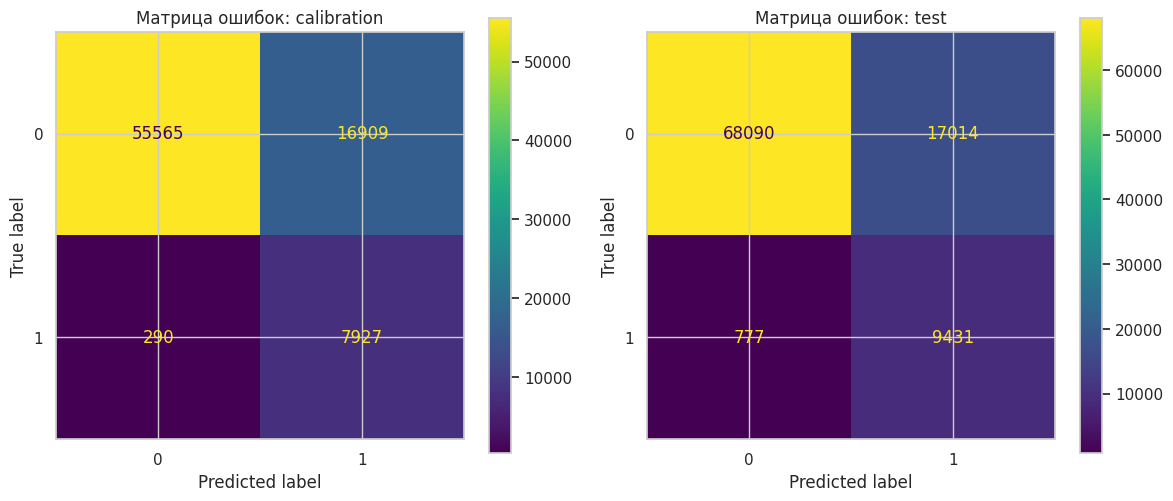

In [101]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_predictions(
    y_calib,
    y_calibration_pred,
    ax=axes[0],
    values_format="d"
)
axes[0].set_title("Матрица ошибок: calibration")

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_pred,
    ax=axes[1],
    values_format="d"
)
axes[1].set_title("Матрица ошибок: test")

plt.tight_layout()
plt.show()

### Вывод по матрицам ошибок

Матрицы ошибок были построены для калибровочной и тестовой выборок при выбранном пороге `0.09`.

На калибровочной выборке модель показывает высокий recall: из 8 217 клиентов с будущим дефолтом модель корректно выявила 7 928, а пропустила 289. Это соответствует `missed defaults rate = 0.035`, что ниже допустимого максимума 4%. Также выполняются остальные бизнес-ограничения: `approval rate = 0.692`, `default rate = 0.005`.

На тестовой выборке модель также сохраняет хорошее качество ранжирования: ROC-AUC составляет 0.918, что близко к значению на калибровочной выборке. `Approval rate = 0.723`, а `default rate = 0.011`, то есть оба показателя удовлетворяют бизнес-ограничениям. Однако `missed defaults rate` вырос до 0.076, что выше допустимого уровня 4%. Это означает, что на независимой тестовой выборке модель пропускает около 7.6% всех будущих дефолтов.

Таким образом, выбранный порог хорошо работает на калибровочной выборке, но не полностью переносится на тестовую по самому строгому риск-показателю — `missed defaults rate`. При этом модель остаётся полезной с точки зрения ранжирования риска и контроля `default rate`, но для промышленного применения потребуется дополнительная настройка порога с запасом по `missed defaults rate`, расширенная проверка устойчивости на временных периодах и регулярный мониторинг качества.

## Анализ признаков на обучающей выборке

Benchmark модели оказался удовлетворительным. Ради эксперимента попробуем обработать признаки:

In [102]:
HIGH_CORR_THRESHOLD = 0.95

numeric_features_current = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_features_current = X_train.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

# Корреляция числовых признаков с target только на train
target_corr = (
    X_train[numeric_features_current]
    .corrwith(y_train)
    .abs()
    .fillna(0)
)

# Корреляция признаков между собой только на train
corr_matrix = X_train[numeric_features_current].corr().abs()
upper_corr = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

features_to_drop_corr = set()

for col in upper_corr.columns:
    high_corr_features = upper_corr.index[upper_corr[col] > HIGH_CORR_THRESHOLD].tolist()
    
    for row in high_corr_features:
        if target_corr[row] >= target_corr[col]:
            features_to_drop_corr.add(col)
        else:
            features_to_drop_corr.add(row)

features_to_drop_corr = sorted(features_to_drop_corr)

print(f"Количество признаков к удалению по высокой корреляции: {len(features_to_drop_corr)}")
display(features_to_drop_corr)

Количество признаков к удалению по высокой корреляции: 12


['MCC_5411_prev_month',
 'MCC_другое_prev_month',
 'credit_rating_roll_3m_mean',
 'discretionary_to_essential_ratio_prev_month',
 'essential_spend_prev_month',
 'essential_spend_to_income_ratio_prev_month',
 'food_spend_prev_month',
 'total_spend_prev_month',
 'total_spend_roll_3m_mean',
 'total_spend_roll_6m_mean',
 'total_spend_to_income_ratio_prev_month',
 'кредитный_рейтинг']

In [103]:
clean_feature_columns = [
    col for col in feature_columns
    if col not in features_to_drop_corr
]

print(f"Было признаков: {len(feature_columns)}")
print(f"Стало признаков после корреляционной чистки: {len(clean_feature_columns)}")

Было признаков: 48
Стало признаков после корреляционной чистки: 36


In [104]:
X_train_clean = df_train[clean_feature_columns].copy()
X_calibration_clean = df_calibration[clean_feature_columns].copy()
X_test_clean = df_test[clean_feature_columns].copy()

print(X_train_clean.shape)
print(X_calibration_clean.shape)
print(X_test_clean.shape)

(166990, 36)
(80691, 36)
(95312, 36)


In [105]:
categorical_features_clean = X_train_clean.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

numeric_features_clean = X_train_clean.select_dtypes(
    include=np.number
).columns.tolist()

numeric_transformer_clean = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_transformer_clean = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ]
)

preprocessor_clean = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_clean, numeric_features_clean),
        ("cat", categorical_transformer_clean, categorical_features_clean),
    ],
    remainder="drop"
)

In [106]:
rf_pipeline_clean = Pipeline(
    steps=[
        ("preprocessor", preprocessor_clean),
        ("variance", VarianceThreshold(threshold=0.0)),
        ("model", RandomForestClassifier(
            random_state=RANDOM_STATE,
            n_jobs=-1,
            class_weight="balanced",
            bootstrap=True
        ))
    ]
)

rf_pipeline_clean.set_params(**best_rf_params)

rf_clean_results = evaluate_model_cv(
    model_name="RandomForest_Optuna_clean_features",
    model=rf_pipeline_clean,
    X=X_train_clean,
    y=y_train,
    cv_splits=cv_splits,
    threshold=0.5
)

rf_clean_summary = (
    rf_clean_results
    .groupby("model")
    .agg(
        roc_auc_mean=("roc_auc", "mean"),
        roc_auc_std=("roc_auc", "std"),
        approval_rate_mean=("approval_rate", "mean"),
        default_rate_mean=("default_rate", "mean"),
        missed_defaults_rate_mean=("missed_defaults_rate", "mean"),
    )
)

display(rf_clean_summary)

,roc_auc_mean,roc_auc_std,approval_rate_mean,default_rate_mean,missed_defaults_rate_mean
model,,,,,
RandomForest_Optuna_clean_features,0.843,0.056,0.586,0.040,0.123


In [107]:
compare_cleaning = pd.concat(
    [
        optimized_rf_summary,
        rf_clean_summary
    ],
    axis=0
)

display(compare_cleaning)

,roc_auc_mean,roc_auc_std,approval_rate_mean,default_rate_mean,missed_defaults_rate_mean
model,,,,,
RandomForest_Optuna,0.853,0.049,0.553,0.026,0.075
RandomForest_Optuna_clean_features,0.843,0.056,0.586,0.040,0.123


### Вывод по дополнительной проверке признаков

Была проведена дополнительная проверка влияния корреляционной чистки признаков. Из обучающей выборки были удалены признаки с высокой взаимной корреляцией, после чего модель Random Forest была повторно оценена на кросс-валидации.

Корреляционная чистка не улучшила качество модели. ROC-AUC снизился с 0.853 до 0.843, а `missed defaults rate` вырос с 0.075 до 0.123. Также ухудшился `default rate`: он увеличился с 0.026 до 0.040. Единственный показатель, который вырос, — `approval rate`, но это произошло за счёт ухудшения контроля дефолтов.

Поэтому для дальнейшей работы была оставлена исходная версия признакового пространства. Это решение допустимо, так как Random Forest менее чувствителен к мультиколлинеарности, чем линейные модели, и может использовать похожие признаки в разных деревьях ансамбля. При этом удаление скоррелированных признаков в данном эксперименте привело к потере части полезного сигнала.

## Дополнительный эксперимент

In [108]:
# Дополнительный эксперимент: Random Forest + RandomUnderSampler

rf_under_pipeline = ImbPipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("sampler", RandomUnderSampler(
            sampling_strategy=0.5,
            random_state=RANDOM_STATE
        )),
        ("model", RandomForestClassifier(
            n_estimators=100,
            max_depth=8,
            min_samples_leaf=20,
            random_state=RANDOM_STATE,
            n_jobs=-1
        ))
    ]
)

In [109]:
rf_under_results = evaluate_model_cv(
    model_name="RandomForest_under",
    model=rf_under_pipeline,
    X=X_train,
    y=y_train,
    cv_splits=cv_splits,
    threshold=0.5
)

display(rf_under_results)

,roc_auc,approval_rate,default_rate,missed_defaults_rate,model,fold
0,0.811,0.697,0.113,0.356,RandomForest_under,1
1,0.869,0.801,0.085,0.430,RandomForest_under,2
2,0.905,0.822,0.050,0.350,RandomForest_under,3


In [110]:
rf_under_summary = (
    rf_under_results
    .groupby("model")
    .agg(
        roc_auc_mean=("roc_auc", "mean"),
        roc_auc_std=("roc_auc", "std"),
        approval_rate_mean=("approval_rate", "mean"),
        default_rate_mean=("default_rate", "mean"),
        missed_defaults_rate_mean=("missed_defaults_rate", "mean"),
    )
)

display(rf_under_summary)

,roc_auc_mean,roc_auc_std,approval_rate_mean,default_rate_mean,missed_defaults_rate_mean
model,,,,,
RandomForest_under,0.862,0.047,0.773,0.083,0.379


In [111]:
baseline_summary_extended = pd.concat(
    [baseline_summary, rf_under_summary],
    axis=0
).sort_values("missed_defaults_rate_mean")

display(baseline_summary_extended)

,roc_auc_mean,roc_auc_std,approval_rate_mean,default_rate_mean,missed_defaults_rate_mean
model,,,,,
LogisticRegression_balanced,0.830,0.063,0.653,0.060,0.221
RandomForest_under,0.862,0.047,0.773,0.083,0.379
RandomForest,0.863,0.054,0.913,0.130,0.711
LogisticRegression,0.831,0.061,0.921,0.140,0.775
RandomForest_balanced,0.864,0.050,0.942,0.141,0.792


Дополнительно была проверена альтернативная стратегия балансировки классов с помощью `RandomUnderSampler` внутри `ImbPipeline`.

По сравнению с обычным Random Forest этот подход заметно снизил `missed defaults rate`: с 0.711 до 0.379. Это означает, что андерсемплинг действительно помог модели лучше замечать клиентов с будущим дефолтом. Однако при этом `default rate` остался высоким и составил 0.083, что значительно выше бизнес-ограничения 2%.

Кроме того, `RandomUnderSampler` уступил логистической регрессии с балансировкой классов по `missed defaults rate`: 0.379 против 0.221. Также он значительно уступил оптимизированной модели `RandomForest_Optuna`, у которой `missed defaults rate` составил 0.075, а `default rate` — 0.026.

Поэтому `RandomUnderSampler` не был выбран для финального решения. Он улучшает выявление дефолтов по сравнению с обычным Random Forest, но не даёт достаточно хорошего компромисса между уровнем одобрения и контролем риска.

## Фиксирование итоговой модели

- Опишите лучшую модель и найденный порог классификации.


In [112]:
final_model = best_calibrated_model
final_threshold = best_threshold

final_model_info = {
    "model": "Calibrated RandomForestClassifier",
    "calibration_method": "isotonic",
    "threshold": final_threshold,
    "best_params": best_rf_params,
}

final_model_info

{'model': 'Calibrated RandomForestClassifier',
 'calibration_method': 'isotonic',
 'threshold': 0.09,
 'best_params': {'model__n_estimators': 104,
  'model__max_depth': 5,
  'model__min_samples_leaf': 38,
  'model__max_features': 'sqrt',
  'model__max_samples': 0.6485530730333811}}

### Фиксирование итоговой модели

В качестве итоговой модели выбрана `RandomForestClassifier` с подобранными гиперпараметрами и последующей изотонической калибровкой вероятностей. Модель была выбрана по результатам сравнения моделей и кросс-валидации, так как оптимизированный Random Forest показал лучший контроль пропущенных дефолтов среди рассмотренных вариантов.

Итоговая конфигурация модели:

- модель: `Calibrated RandomForestClassifier`;
- метод калибровки: `isotonic`;
- порог классификации: `0.09`.

Лучшие гиперпараметры Random Forest:

- `n_estimators = 104`;
- `max_depth = 5`;
- `min_samples_leaf = 38`;
- `max_features = "sqrt"`;
- `max_samples ≈ 0.649`.

После обучения модель была откалибрована на отдельной калибровочной выборке методом `isotonic`. Калибровка улучшила качество вероятностных оценок: коэффициент Бриера снизился с 0.106 до 0.065. ROC-AUC при этом практически не изменился: до калибровки он составлял 0.915, после калибровки — 0.916. Это ожидаемо, так как калибровка в основном меняет шкалу вероятностей, а не порядок ранжирования клиентов по риску.

Для принятия решения был выбран порог классификации `0.09`. Он был подобран на калибровочной выборке по бизнес-метрикам и удовлетворяет всем заданным ограничениям. На калибровочной выборке модель показала:

- `approval rate = 0.692`;
- `default rate = 0.005`;
- `missed defaults rate = 0.035`;
- `ROC-AUC = 0.916`;
- `Brier score = 0.065`.

Таким образом, на калибровочной выборке выполняются все бизнес-требования: `approval rate` выше 65%, `default rate` ниже 2%, а `missed defaults rate` ниже 4%.

На тестовой выборке модель показала:

- `approval rate = 0.723`;
- `default rate = 0.011`;
- `missed defaults rate = 0.076`;
- `ROC-AUC = 0.918`;
- `Brier score = 0.067`.

На тесте модель сохранила хорошее качество ранжирования клиентов: ROC-AUC даже немного выше, чем на калибровочной выборке. Коэффициент Бриера также остался близким к калибровочному значению, что говорит об отсутствии резкого ухудшения вероятностных оценок на новых данных.

Однако бизнес-ограничение по `missed defaults rate` на тестовой выборке не было выполнено: значение составило 7.6% при допустимом максимуме 4%. При этом остальные два ограничения выполняются: `approval rate` выше 65%, а `default rate` ниже 2%.

Дополнительно была проверена корреляционная чистка признаков. После удаления сильно скоррелированных признаков качество модели ухудшилось: ROC-AUC снизился с 0.853 до 0.843, а `missed defaults rate` вырос с 0.075 до 0.123. Также увеличился `default rate`: с 0.026 до 0.040. Поэтому для итоговой модели был оставлен исходный набор признаков.

Также была проверена альтернативная стратегия балансировки через `RandomUnderSampler`. Она улучшила обычный Random Forest по `missed defaults rate`, но уступила оптимизированной модели Random Forest и не дала достаточно хорошего компромисса между уровнем одобрения и контролем риска. Поэтому для итогового решения эта стратегия не использовалась.

Итоговая модель может рассматриваться как рабочий скоринговый baseline: она хорошо ранжирует клиентов по риску, имеет стабильные вероятностные оценки и на калибровочной выборке удовлетворяет всем бизнес-ограничениям. Тем не менее на независимой тестовой выборке модель не полностью выполняет требования, так как превышает допустимый уровень пропущенных дефолтов. Для промышленного использования модель потребовала бы дальнейшего улучшения: дополнительной настройки порога с запасом по `missed defaults rate`, расширения признакового пространства, проверки более сильных моделей и регулярного мониторинга качества на новых временных периодах.

<div style="border:solid #D3D3D3 2px; border-radius: 10px; padding: 15px">
<h3> Комментарий ревьюера <a class="tocSkip"></h3>
<h4> Анализ и фиксирование итоговой модели<a class="tocSkip"></h4>

<div style="border-radius: 10px" class="alert alert-success">
<b>Отлично ✅:</b> 
    
* Здесь по ходу решения все хорошо!


* Здорово, что смотришь на результаты в том числе с позиции бизнеса. Все-таки задача направлена на решение конкретной бизнес-проблемы, а не на оторванную от реальности подгонку результатов под определенные значения.

</div>

## Анализ важности признаков

* Проведите анализ важности признаков найденной модели на полных тренировочных данных.
* Используйте `feature_importances_` для найденной модели.
* Сделайте вывод о силе влияния признаков на дефолт.

In [113]:
# Если best_rf_pipeline уже был обучен на X_train, y_train перед калибровкой,
# повторно fit делать не нужно.
# best_rf_pipeline.fit(X_train, y_train)

rf_model = best_rf_pipeline.named_steps["model"]
fitted_preprocessor = best_rf_pipeline.named_steps["preprocessor"]

feature_names = fitted_preprocessor.get_feature_names_out()

feature_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": rf_model.feature_importances_
}).sort_values("importance", ascending=False)

display(feature_importance.head(20))

,feature,importance
34,num__discretionary_spend_to_income_ratio_prev_...,0.196
32,num__total_spend_to_income_ratio_prev_month,0.188
33,num__essential_spend_to_income_ratio_prev_month,0.165
15,num__client_tenure_months,0.071
17,num__total_spend_prev_month,0.042
18,num__food_spend_prev_month,0.039
20,num__discretionary_spend_prev_month,0.036
11,num__MCC_другое_prev_month,0.031
0,num__возраст,0.030
7,num__MCC_5411_prev_month,0.021


In [114]:
def get_source_feature(transformed_feature_name):
    """
    Возвращает исходное имя признака после ColumnTransformer / OneHotEncoder.
    Например:
    cat__семейное_положение_есть семья -> семейное_положение
    num__доход -> доход
    """
    if "__" in transformed_feature_name:
        _, feature_name = transformed_feature_name.split("__", 1)
    else:
        feature_name = transformed_feature_name

    for col in sorted(categorical_columns, key=len, reverse=True):
        if feature_name == col or feature_name.startswith(f"{col}_"):
            return col

    return feature_name


feature_importance["source_feature"] = (
    feature_importance["feature"]
    .apply(get_source_feature)
)

source_feature_importance = (
    feature_importance
    .groupby("source_feature", as_index=False)["importance"]
    .sum()
    .sort_values("importance", ascending=False)
)

display(source_feature_importance.head(20))

,source_feature,importance
23,discretionary_spend_to_income_ratio_prev_month,0.196
36,total_spend_to_income_ratio_prev_month,0.188
27,essential_spend_to_income_ratio_prev_month,0.165
16,client_tenure_months,0.071
32,total_spend_prev_month,0.042
29,food_spend_prev_month,0.039
22,discretionary_spend_prev_month,0.036
14,MCC_другое_prev_month,0.031
38,возраст,0.030
6,MCC_5411_prev_month,0.021


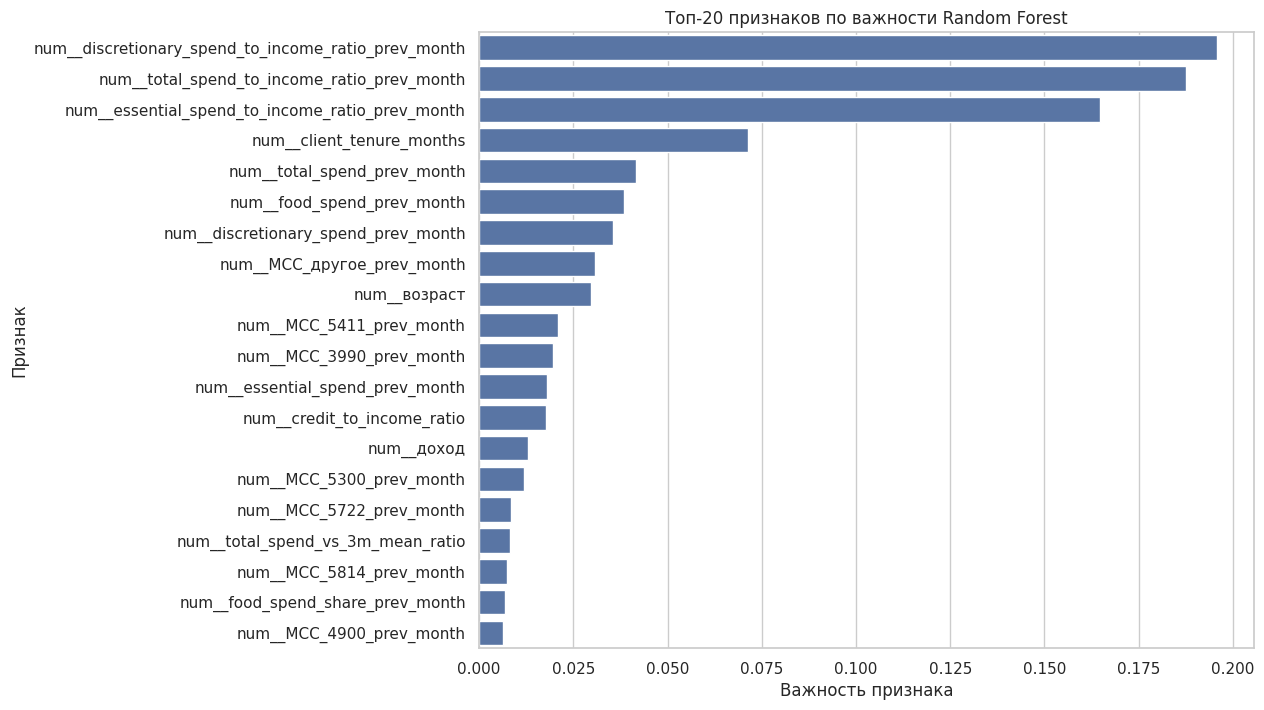

In [115]:
top_n = 20

plt.figure(figsize=(10, 8))
sns.barplot(
    data=feature_importance.head(top_n),
    x="importance",
    y="feature"
)
plt.title("Топ-20 признаков по важности Random Forest")
plt.xlabel("Важность признака")
plt.ylabel("Признак")
plt.show()

In [116]:
def get_feature_group(feature_name):
    if (
        "MCC_" in feature_name
        or "spend" in feature_name
        or "expense" in feature_name
    ):
        return "Поведенческие признаки расходов"

    if (
        "рейтинг" in feature_name
        or "rating" in feature_name
    ):
        return "Кредитный рейтинг"

    if (
        "доход" in feature_name
        or "сумма_кредита" in feature_name
        or "credit_to_income" in feature_name
    ):
        return "Кредитная нагрузка и доход"

    if (
        "ипотек" in feature_name
        or "mortgage" in feature_name
    ):
        return "Ипотека"

    if (
        "возраст" in feature_name
        or "семейное_положение" in feature_name
        or "иждивен" in feature_name
        or "family" in feature_name
        or "client_tenure" in feature_name
        or "is_new_client" in feature_name
        or "has_prev_month" in feature_name
    ):
        return "Профиль клиента и стаж"

    if (
        "ставка" in feature_name
        or "безработиц" in feature_name
        or "инфляц" in feature_name
    ):
        return "Макроэкономические признаки"

    return "Прочие признаки"


source_feature_importance["feature_group"] = (
    source_feature_importance["source_feature"]
    .apply(get_feature_group)
)

group_importance = (
    source_feature_importance
    .groupby("feature_group", as_index=False)["importance"]
    .sum()
    .sort_values("importance", ascending=False)
)

display(group_importance)

,feature_group,importance
4,Поведенческие признаки расходов,0.852
5,Профиль клиента и стаж,0.102
1,Кредитная нагрузка и доход,0.033
2,Кредитный рейтинг,0.009
6,Прочие признаки,0.003
3,Макроэкономические признаки,0.001
0,Ипотека,0.000


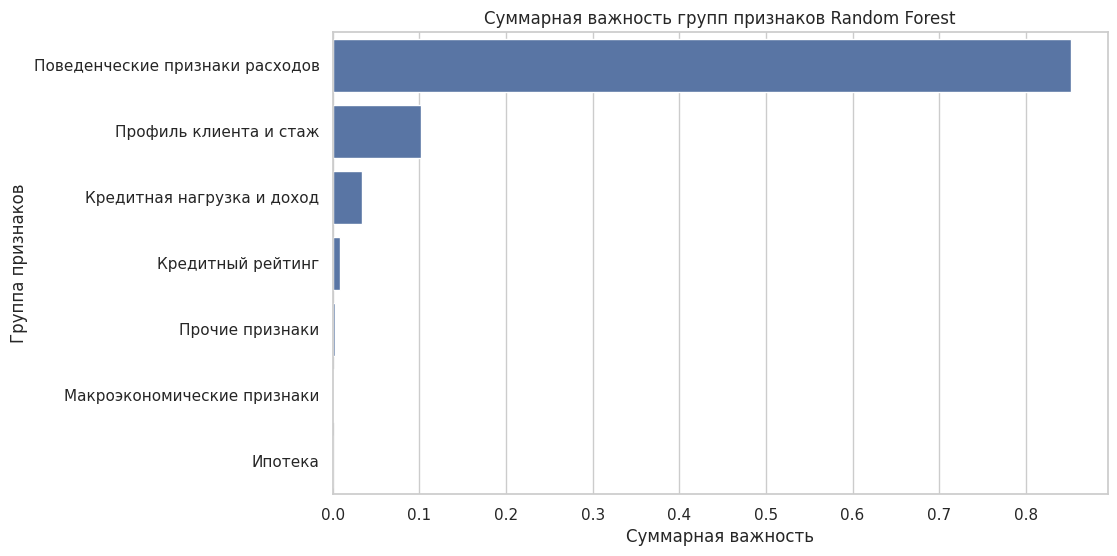

In [117]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=group_importance,
    x="importance",
    y="feature_group"
)

plt.title("Суммарная важность групп признаков Random Forest")
plt.xlabel("Суммарная важность")
plt.ylabel("Группа признаков")
plt.show()

#### Вывод по важности признаков

Для итоговой модели Random Forest был проведён анализ важности признаков с помощью атрибута `feature_importances_`. Сначала были рассмотрены отдельные признаки после всех преобразований пайплайна, а затем важности были агрегированы до уровня исходных признаков и смысловых групп.

Наиболее важными признаками оказались показатели финансовой нагрузки через расходы относительно дохода: `discretionary_spend_to_income_ratio_prev_month`, `total_spend_to_income_ratio_prev_month` и `essential_spend_to_income_ratio_prev_month`. Их важности составили примерно 0.196, 0.188 и 0.165 соответственно. Это подтверждает, что добавленные признаки отношения расходов к доходу действительно несут сильный сигнал для поведенческого скоринга.

Следующим по важности стал `client_tenure_months` — срок жизни клиента в банке на дату скоринга. Его важность составила около 0.071. Это показывает, что клиентский стаж также важен для оценки риска: модель учитывает, насколько давно клиент взаимодействует с банком и есть ли у него накопленная история поведения.

Далее по важности идут признаки транзакционного поведения: `total_spend_prev_month`, `food_spend_prev_month`, `discretionary_spend_prev_month`, `MCC_другое_prev_month`, `MCC_5411_prev_month` и другие MCC-категории. Это соответствует сути задачи: поведенческая модель должна учитывать не только статические характеристики клиента, но и его финансовое поведение за предыдущие периоды.

Агрегация важностей по смысловым группам показала, что основной вклад в модель вносят поведенческие признаки расходов — суммарная важность этой группы составила около 0.852. На втором месте находятся признаки профиля клиента и стажа с суммарной важностью около 0.102. Остальные группы — кредитная нагрузка и доход, кредитный рейтинг, макроэкономические признаки и ипотека — имеют заметно меньшую суммарную важность в рамках данной модели.

Это не означает, что признаки с низкой важностью полностью бесполезны: они могут давать небольшой дополнительный сигнал или работать во взаимодействии с другими признаками. Однако в текущей модели основной вклад в решение вносят именно расходы клиента, их структура и соотношение с доходом.

Важно учитывать ограничения метода `feature_importances_`. Встроенная важность Random Forest основана на суммарном снижении impurity, поэтому она может быть смещена в пользу непрерывных признаков и признаков с большим числом уникальных значений. Поэтому сравнивать важности разных типов признаков нужно осторожно. Также эта метрика показывает силу использования признака моделью, но не показывает направление влияния: по ней нельзя сказать, повышает или снижает конкретный признак вероятность дефолта.

Таким образом, итоговая модель в основном опирается на поведенческие признаки расходов, особенно на отношение расходов к доходу, а также на клиентский стаж и отдельные категории трат. Это соответствует логике поведенческого скоринга: риск будущей просрочки лучше всего объясняется не только анкетными или кредитными характеристиками, но и текущим финансовым поведением клиента.

<div style="border:solid #D3D3D3 2px; border-radius: 10px; padding: 15px">
<h3> Комментарий ревьюера <a class="tocSkip"></h3>
<h4> Анализ важности факторов<a class="tocSkip"></h4>

<div style="border-radius: 10px" class="alert alert-success">
<b>Отлично ✅:</b> Все гуд!

</div>


<div style="border-radius: 10px" class="alert alert-warning">
<b>Рекомендации💡:</b> 


* Важности признаков можно суммировать, чтобы посмотреть общую важность расчленненного признака (при OHE), важность группы скоррелированных факторов или важность факторов определенной сферы.


* Также в оценке важности через встроенный `feature_importance` есть ловушки - данный метод основан на суммарном уменьшении `impurity`, из-за чего будет проявляться смещение в пользу непрерывных признаков и признаков с большим числом уникальных значений. Поэтому между собой разные типы признаков сравнивать по важности не стоит.

</div>


## Сохранение модели

In [118]:
# Сохранение финальной модели

artifacts_dir = Path("artifacts")
artifacts_dir.mkdir(exist_ok=True)

final_model_path = artifacts_dir / "final_scoring_model.pkl"

final_artifact = {
    "model": final_model,
    "threshold": final_threshold,
    "model_name": "Calibrated RandomForestClassifier",
    "calibration_method": "isotonic",
    "best_params": best_rf_params,
    "feature_columns": feature_columns,
}

joblib.dump(final_artifact, final_model_path)

print(f"Финальная модель и параметры сохранены в файл: {final_model_path}")

Финальная модель и параметры сохранены в файл: artifacts/final_scoring_model.pkl


## Выводы по проекту

Сделайте выводы по проекту. Можете использовать такой план:

1. Цель и задачи исследования.

2. Подготовка данных и выборок.

3. Поиск и настройка модели.

4. Калибровка вероятностей.

5. Оптимизация бизнес-порога.

6. Анализ важности признаков.

7. Финальный пайплайн.

8. Основные выводы и рекомендации для бизнеса.



## Выводы по проекту

В проекте решалась задача поведенческого скоринга клиентов банка. Цель состояла в том, чтобы по данным о клиенте на дату скоринга предсказать вероятность возникновения просрочки 90+ дней в течение следующих 12 месяцев. Объектом моделирования была пара «клиент — месяц наблюдения», а целевая переменная принимала значение `1`, если в горизонте прогноза возникал дефолт 90+, и `0`, если такого события не было.

На этапе подготовки данных были загружены и изучены все исходные таблицы: сетка скоринга, клиентские данные, кредитные параметры, ипотека, кредитный рейтинг, транзакции, макроэкономика и данные о просрочках. Пропусков и явных дубликатов в исходных таблицах обнаружено не было. Дополнительно была проверена уникальность ключей, по которым выполнялись объединения таблиц. Дубликатов по ключам объединения обнаружено не было, поэтому риск некорректного many-to-many merge был снижен.

Даты были приведены к формату `datetime`, а таблицы объединены в единую витрину с учётом временной логики. В признаки попадала только информация, доступная на момент скоринга или ранее. Макроэкономические показатели и кредитный рейтинг присоединялись за текущий месяц, так как по описанию данных они актуальны на дату скоринга. Транзакционные признаки использовались за предыдущий месяц. Для наблюдений без истории за предыдущий месяц транзакционные пропуски были заполнены нулями, а также был добавлен индикатор `has_prev_month_transactions`, чтобы модель могла отличать отсутствие истории от обычных нулевых расходов.

Целевая переменная была сформирована с горизонтом 12 месяцев через `pd.DateOffset(months=12)`, а не через фиксированные 365 дней. Это корректнее для данных, охватывающих несколько лет, включая високосный год. После расчёта таргета были удалены строки, где дефолт уже произошёл до даты скоринга, так как такие наблюдения не соответствуют задаче прогнозирования будущего риска. Дополнительно из моделирования были исключены последние месяцы, для которых невозможно полностью наблюдать 12-месячный горизонт прогноза.

После объединения таблиц и создания признаков итоговая таблица содержала 438 379 наблюдений и 49 столбцов. Были добавлены признаки клиентского стажа, кредитной нагрузки, структуры расходов, отношения расходов к доходу, rolling-признаки по транзакциям и признаки динамики кредитного рейтинга. Наиболее полезными оказались признаки финансовой нагрузки через расходы относительно дохода клиента.

Данные были разделены по времени на обучающую, калибровочную и тестовую выборки. Калибровочная и тестовая выборки включали по 12 месяцев. Для кросс-валидации на обучающей выборке использовался `GroupTimeSeriesSplit` на трёх временных фолдах, что позволило учитывать временную структуру данных и не перемешивать прошлые и будущие наблюдения.

В пайплайне предобработки непрерывные числовые признаки заполнялись константой и масштабировались, бинарные числовые признаки были выделены отдельно и не масштабировались, а категориальные признаки кодировались через `OneHotEncoder(drop="first")`. Медианная и модальная импьютация не использовались, так как для данных с временной структурой они могут искажать динамику и создавать неявную утечку информации.

В качестве базовых моделей были обучены логистическая регрессия и случайный лес без балансировки, а также их версии с балансировкой классов. Дополнительно был проверен `RandomForest` с `RandomUnderSampler` через `ImbPipeline`. Андерсемплинг улучшил обычный случайный лес по `missed defaults rate`, снизив показатель с 0.711 до 0.379, однако результат всё равно оказался хуже, чем у логистической регрессии с балансировкой и у оптимизированного Random Forest. Поэтому эта стратегия не была выбрана для финального решения.

Для итоговой модели был выбран `RandomForestClassifier` с подбором гиперпараметров через Optuna. Оптимизация проводилась по метрике `missed defaults rate`, так как для банка особенно важно минимизировать долю пропущенных дефолтов. Лучшие параметры модели: `n_estimators = 104`, `max_depth = 5`, `min_samples_leaf = 38`, `max_features = "sqrt"`, `max_samples ≈ 0.649`.

На кросс-валидации оптимизированный Random Forest показал `ROC-AUC = 0.853`, `approval rate = 0.553`, `default rate = 0.026`, `missed defaults rate = 0.075`. По сравнению с базовыми моделями случайного леса он заметно лучше контролировал пропущенные дефолты, хотя при стандартном пороге 0.5 был слишком консервативным по уровню одобрения.

После обучения была проведена изотоническая калибровка вероятностей на отдельной калибровочной выборке. Калибровка улучшила качество вероятностных оценок: коэффициент Бриера снизился с 0.106 до 0.065. ROC-AUC при этом практически не изменился: до калибровки он составлял 0.915, после калибровки — 0.916. Это ожидаемо, так как калибровка в основном меняет шкалу вероятностей, а не порядок ранжирования клиентов по риску.

На калибровочной выборке был выполнен поиск порога классификации с учётом бизнес-ограничений: `approval rate` не менее 65%, `default rate` не более 2%, `missed defaults rate` не более 4%. Был выбран порог `0.09`. На калибровочной выборке он дал следующие результаты:

- `accuracy = 0.787`;
- `precision = 0.319`;
- `recall = 0.965`;
- `F1 = 0.480`;
- `ROC-AUC = 0.916`;
- `Brier score = 0.065`;
- `approval rate = 0.692`;
- `default rate = 0.005`;
- `missed defaults rate = 0.035`.

Таким образом, на калибровочной выборке модель удовлетворила всем трём бизнес-ограничениям.

На тестовой выборке итоговая модель показала:

- `accuracy = 0.813`;
- `precision = 0.357`;
- `recall = 0.924`;
- `F1 = 0.515`;
- `ROC-AUC = 0.918`;
- `Brier score = 0.067`;
- `approval rate = 0.723`;
- `default rate = 0.011`;
- `missed defaults rate = 0.076`.

На тесте модель сохранила хорошее качество ранжирования клиентов: ROC-AUC оказался близок к калибровочной выборке и составил 0.918. Коэффициент Бриера также остался стабильным, что говорит об отсутствии резкого ухудшения вероятностных оценок на новых данных.

Однако не все бизнес-ограничения были выполнены на тесте. `Approval rate` составил 0.723, что выше требуемых 65%, а `default rate` составил 0.011, что ниже допустимых 2%. При этом `missed defaults rate` оказался равен 0.076, то есть 7.6%, что выше требуемого максимума 4%. Следовательно, модель выявляет большую часть будущих дефолтов, но на независимой тестовой выборке всё ещё пропускает больше рискованных клиентов, чем допускает бизнес-требование.

Дополнительно была проведена проверка корреляционной чистки признаков. После удаления сильно скоррелированных признаков качество модели не улучшилось: ROC-AUC снизился с 0.853 до 0.843, а `missed defaults rate` вырос с 0.075 до 0.123. Также ухудшился `default rate`: он увеличился с 0.026 до 0.040. Поэтому в итоговой модели был оставлен исходный набор признаков.

Анализ важности признаков показал, что основной вклад в модель внесли поведенческие признаки расходов. Наиболее важными оказались `discretionary_spend_to_income_ratio_prev_month`, `total_spend_to_income_ratio_prev_month` и `essential_spend_to_income_ratio_prev_month`. Агрегация важностей по группам показала, что суммарная важность поведенческих признаков расходов составила около 0.852, признаков профиля клиента и стажа — около 0.102, а кредитной нагрузки и дохода — около 0.033. Это соответствует смыслу поведенческого скоринга: риск будущей просрочки лучше всего объясняется не только статическими характеристиками клиента, но и его текущим финансовым поведением.

При интерпретации важности признаков важно учитывать ограничения метода `feature_importances_`. Эта метрика основана на снижении impurity в деревьях и может быть смещена в пользу непрерывных признаков и признаков с большим числом уникальных значений. Поэтому полученные важности следует рассматривать как ориентировочную диагностику, а не как строгую причинную интерпретацию.

Финальный пайплайн включает предобработку признаков, обученный `RandomForestClassifier`, изотоническую калибровку вероятностей и выбранный порог классификации `0.09`. Модель, порог, список признаков и лучшие гиперпараметры были сохранены в файл `artifacts/final_scoring_model.pkl`, что позволяет воспроизвести предсказания в дальнейшем.

Итоговая модель может рассматриваться как рабочий скоринговый baseline. Она хорошо ранжирует клиентов по риску, имеет стабильные вероятностные оценки и на калибровочной выборке удовлетворяет всем бизнес-ограничениям. Тем не менее на независимой тестовой выборке модель не полностью выполняет требования, так как превышает допустимый уровень пропущенных дефолтов. Поэтому перед промышленным использованием модель потребовала бы дальнейшего улучшения: дополнительной настройки порога с запасом по `missed defaults rate`, расширения признакового пространства, проверки более сильных моделей и регулярного мониторинга качества.

### Рекомендации по дальнейшему жизненному циклу модели

В промышленной эксплуатации модель должна использоваться не как разовое исследование, а как часть регулярного скорингового процесса. На каждом новом месяце для действующих клиентов должна формироваться актуальная витрина признаков, после чего модель рассчитывает вероятность дефолта 90+ в горизонте следующих 12 месяцев. Клиенты с вероятностью выше выбранного порога относятся к группе повышенного риска, а результаты скоринга могут использоваться для управления резервами, приоритизации коммуникаций с клиентами и контроля ликвидности.

Так как таргет определяется в горизонте 12 месяцев, фактическая оценка качества модели будет приходить с задержкой. Поэтому во время эксплуатации нужно вести два уровня мониторинга. Первый — оперативный мониторинг данных и предсказаний: проверка пропусков, распределений признаков, доли клиентов в рисковой группе, стабильности вероятностей и сдвига входных данных относительно обучающей выборки. Второй — отложенный мониторинг качества, когда через 12 месяцев становится известно, произошёл ли у клиента дефолт 90+.

В процессе эксплуатации необходимо регулярно отслеживать бизнес-метрики: `approval rate`, `default rate`, `missed defaults rate`, а также технические метрики `ROC-AUC`, `Brier score`, `recall`, `precision` и матрицу ошибок. Особенно важно отдельно мониторить качество на новых клиентах и на клиентах с накопленной историей, так как в тестовой выборке эти сегменты имели разные уровни риска.

Порог классификации не должен считаться окончательно фиксированным навсегда. Его можно пересматривать в зависимости от риск-аппетита банка и текущей экономической ситуации. Более низкий порог сделает модель осторожнее и снизит число пропущенных дефолтов, но уменьшит долю одобренных клиентов. Более высокий порог увеличит `approval rate`, но может повысить риск пропущенных дефолтов. В дальнейшем выбор порога желательно выполнять не только по трём бизнес-метрикам, но и по финансовой функции потерь, учитывающей прибыль от надёжных клиентов и ожидаемые потери от дефолтов.

Модель следует регулярно переобучать, например раз в квартал или раз в полгода, после накопления новых размеченных данных. При каждом переобучении необходимо заново проверять временное разбиение, калибровку вероятностей, оптимальный порог и стабильность качества на отложенном тестовом периоде. Новую версию модели следует сравнивать с текущей рабочей версией по схеме champion/challenger и переводить в эксплуатацию только при устойчивом улучшении бизнес-метрик.

Также рекомендуется расширить признаковое пространство: добавить более глубокую историю транзакций, признаки регулярности доходов и расходов, признаки изменения долговой нагрузки, более детальные агрегаты по MCC-категориям, поведение клиента по платежам и дополнительные макроэкономические индикаторы. Отдельно стоит проверить более сильные модели, например градиентный бустинг, и сравнить их с текущим Random Forest на той же временной схеме валидации.

Таким образом, текущая модель является хорошей исследовательской и скоринговой базой, но для промышленной эксплуатации ей необходим управляемый жизненный цикл: регулярный пересчёт скоринга, мониторинг данных и метрик, контроль дрейфа, периодическая перекалибровка, пересмотр порога и плановое переобучение на новых временных периодах.

<div style="border:solid #D3D3D3 2px;  border-radius: 10px; padding: 15px">
<h3> Комментарий ревьюера <a class="tocSkip"></h3>
<h4> Итоговые выводы <a class="tocSkip"></h4>

<div style="border-radius: 10px" class="alert alert-success">
<b>Отлично ✅:</b> 
    
С задачей справились! Все ключевые моменты отражены, что позволяет быстро ознакомиться с процессом работы и результатом, не вдаваясь в технические детали. Здорово, что завершаешь проект рекомендациями. Предложенные рекомендации логично следуют из анализа и могут быть непосредственно реализова в на дальнейших этапах жизни модели. 

</div>


<div style="border-radius: 10px" class="alert alert-warning">
<b>Рекомендации💡:</b> 
    
Каков в целом дальнейший жизненный цикл модел? Что будет происходить во время ее эксплуатаци? Отсюда тоже можно вывести рекомендации.

</div>

<div style="border:solid Green 2px; border-radius: 10px;  padding: 40px">
<h3>Общий вывод по проекту <a class="tocSkip"></h3>
    
Андрей, спасибо за твой проект! У тебя хорошая работа! В тебе видны зачатки будущего профессионала своего дела :) Однако есть еще моменты, которые требуют твоего внимания. Кратко пройдусь по впечатлениям.  
    
**Полнота:** <span style="color:Green;">все требуемые задачи были выполнены!</span>

**Корректность:** 

* <span style="color:Red;">Необходимо скорректировать формирование целевой переменной - учесть нюансы, подробно изложенные в ТЗ. </span>
* <span style="color:Red;">Временная структура требует особого подхода к обработке пропусков - для заполнения может использоваться только информация из прошлого. Если ее нет, либо удаляем, либо заполняем нулем и добавляем признаки-индикаторы.</span>
    
**Аналитическая проницательность:** ты верно подмечаешь ключевые нюансы данных, даешь дельные рекомендации, смотришь на процесс и результаты в том числе с позиции бизнеса! Хорошая работа!
     
**Грамотность кода:** 

по этому критерию в целом все супер! Используются удобные методы, функции для повторяющихся действий, есть стурктура, комментарии к коду.

**Оформление:** им тоже важно не пренебрегать! Оформление тесно связано с удобством восприятия предоставляемой информации и созданием впечатления о работе. Твоя работа оформлена хорошо - выделены разделы, грамотно оформлены графики, ведется последовательный сторителлинг. Так держать! 


<span style="color:Orange;">Ниже прикрепила общие рекомендации на будущее.</span>

**Желаю удачи и жду твой проект на повторное ревью!** 😉

<img src="https://99px.ru/sstorage/86/2015/12/image_86271215043043632690.gif" />


<div style="border:solid #D3D3D3 2px; border-radius: 10px; padding: 15px">
<h3> Общие рекомендации <a class="tocSkip"></h3>

1. <details> <summary> <span style='color:blue' > Структура, логика и работа с данными (тык) </span> </summary>
    
    * **Глобальный скелет тетрадки**
        * **Что делать:** Строго соблюдать сквозную хронологию разделов исследования:
          1. **Паспорт проекта:** Описание темы, бизнес-цели и технической задачи.
          2. **Инициализация:** Импорт библиотек, фиксация `RANDOM_STATE` при необходимости и загрузка данных в первой ячейке.
          3. **Sanity Check:** Первичный осмотр размера (`.shape`), типов данных (`.info()`) и примеров строк (`.head()`).
          4. **Предобработка (Data Cleaning):** Последовательная очистка типов, пропусков, дубликатов и аномалий в отдельном блоке.
          5. **Модульный EDA:** Разведочный анализ по принципу "один бизнес-вопрос $\rightarrow$ один график $\rightarrow$ промежуточный вывод".
          6. **Моделирование / Статистика** (большие разделы, которые внутри имеют свою подструктуру): Выделенный технический блок для подготовки признаков, проверки гипотез или обучения моделей.
          7. **Бизнес-финал (общий вывод):** Итоговый текстовый раздел без кода с резюме, инсайтами в цифрах и конкретными рекомендациями.
        * **Почему:** Задает жесткую логику повествования, превращая хаотичный код в понятный продукт. Позволяет коллегам быстро ориентироваться в работе, исключает кашу в кодовой базе и гарантирует, что заказчик сразу найдет ответы на свои вопросы в финале.
    
    <br/>
    
    * **Сквозная микро-структура любого раздела (Вступление → Анализ → Резюме)**
        * **Что делать:** Каждый содержательный раздел ноутбука (особенно в блоке EDA) должен быть упакован в строгую трехэтапную структуру:
          1. **Вступление (Постановка контекста):** Короткая Markdown-строка перед кодом. Что мы сейчас будем исследовать, какую гипотезу проверять и на какие вопросы отвечать.
          2. **Содержательная часть (Анализ):** Код, чистые аутпуты и графики, подкрепленные комментариями к логике действий.
          3. **Резюме (Промежуточный вывод):** Финальный текстовый блок в Markdown. Итог раздела, интерпретация причин ("почему так вышло") и бизнес-смысл находки.
        * **Почему:** Защищает ноутбук от превращения в "поток сознания". Без вступления не ясно, зачем написан следующий кусок кода. Без резюме - код зависает в воздухе, а работа выглядит незавершенной.
    
    <br/>
    
    * **Цикличность шагов: "Гипотеза → Действие → Результат → Вывод → ..."**
      * **Что делать:** Каждая содержательная часть строится по одной и той же цепочке: цель / гипотеза → код анализа → интерпретация результата → мостик к следующему шагу. 
      * **Почему:** Работа не должна выглядеть набором случайных действий, она должна читаться как аналитическая статья, где текст плавно ведет читателя сквозь код к выводам.
    
    <br/>
    
    * **Аргументация решений (без очевидных фактов)**
      * **Что делать:** Фиксировать, *почему* выбран конкретный метод обработки пропусков, аномалий или модель. Не писать банальности (например, "функция `mean()` считает среднее").
      * **Почему:** Заказчику важен ход мысли исследователя и обоснованность выбора, а не пересказ документации Python.
    
    <br/>
    
    * **Чистота логики**
      * **Что делать:** Строго разделять этапы обработки и трансформаций и этапы анализа. Необходимо четко понимать, в каком состоянии на данном этапе находятся данные. 
      * **Почему:** Нарушение логики делает результаты анализа недостоверными.

    <br/>
    
    </details>

2. <details> <summary> <span style='color:blue' > Оформление и Markdown (тык) </span> </summary>

    * **Разделение обязанностей: Markdown vs Комментарии**
      * **Что делать:** Смысловой анализ, бизнес-выводы и описание шагов - писать только в Markdown-ячейках. Комментарии внутри кода - использовать только для пояснения нетривиальных алгоритмических решений.
      * **Почему:** Код должен оставаться кодом. Текст в Markdown форматируется, легче читается и формирует структуру проекта.
    
    <br/>
    
    * **Принцип визуального минимализма и единство стиля**
      * **Что делать:** Использовать строгую иерархию заголовков (`#` - крупный раздел, `##` - подраздел), выделять жирным ключевые метрики и выводы. Сохранять один стиль оформления по всей работе.
      * **Почему:** Разнородный стиль отвлекает от сути исследования и выглядит неряшливо.
    
    <br/>
    
    * **Гиперссылки и интерактивное оглавление**
      * **Что делать:** Крупные работы снабжать кликабельным оглавлением со ссылками на теги в Markdown. На внешние источники (ТЗ, статьи, документацию) давать аккуратные гиперссылки вида `[Текст](url)`, а не вставлять голые длинные URL.
      * **Почему:** Упрощает навигацию по объемному ноутбуку.
    
    <br/>
    
    * **Бизнес-метрики vs Технические метрики**
      * **Что делать:** В финальных выводах переводить математические термины на язык денег или бизнес-процессов. Не просто "$R^2 = 0.85$", а "модель ошибается в среднем на X рублей, что позволит сэкономить Y% бюджета".
      * **Почему:** Заказчик оценивает пользу для бизнеса, а не знание высшей математики.

    <br/>
    
    </details>

3. <details> <summary> <span style='color:blue' > Код (тык) </span> </summary>
    
    * **Импорты в строго отведенном месте**
      * **Что делать:** Все библиотеки (`pandas`, `matplotlib` и др.) импортируются **только в первой ячейке** ноутбука. Никаких `import` в середине работы.
      * **Почему:** Сразу видны зависимости проекта. Если у проверяющего нет нужной библиотеки, он узнает об этом на первой секунде, а не через полчаса выполнения кода.
    
    <br/>
    
    * **Строгая фиксация Random State (воспроизводимость)**
      * **Что делать:** В самом первом блоке инициализации фиксировать `SEED` / `RANDOM_STATE` как глобальную константу и передавать её во все функции разбиения данных, сэмплирования и обучения моделей (`train_test_split`, `RandomForest` и т.д.).
      * **Почему:** Без этого при каждом перезапуске тетрадки будут получаться разные метрики и графики. Работа станет невоспроизводимой.
    
    <br/>

    * **Принцип "Одна ячейка - одна атомарная смысловая задача"**
      * **Что делать:** Дробить код. К примеру, в одной ячейке - дубликаты, в другой - пропуски, в третьей - невалидные значения.
      * **Почему:** Упрощает отладку, чтение кода и позволяет запускать отдельные блоки без перезапуска всего проекта.
    
    <br/>
    
    * **Стандарт PEP 8 (Длина строки и отступы)**
      * **Что делать:** Ограничивать длину строки кода до 79 символов. Переносить длинные строки (через скобки или `\`). Использовать 4 пробела для отступов.
      * **Почему:** Избавляет от горизонтального скролла, который сильно утомляет портит читаемость.
    
    <br/>
    
    * **Отказ от хардкода**
      * **Что делать:** Все ключевые параметры, пути к файлам и пороговые значения (например, `UPPER_BOUND = 0.99` для очистки выбросов) выносить в отдельные переменные-константы в начале раздела или ноутбука.
      * **Почему:** Если поменяется бизнес-логика, менять значение нужно будет в одном месте, а не выискивать его по всему коду.
    
    <br/>
    
    * **Осмысленный англоязычный нейминг**
      * **Что делать:** Никакого транслита (`peremennaya`) и безликих названий (`df1`, `data_new`). Использовать понятные имена: `user_profiles`, `clean_transactions`.
      * **Почему:** Позволяет читать код как текст, без необходимости возвращаться к месту объявления переменной.
    
    <br/>
    
    * **Контроль за мусорными переменными и памятью**
      * **Что делать:** Не создавать дубликаты огромных таблиц (`df1`, `df2`, `df_final`). Если датафрейм претерпел сильные изменения, перезаписывать его или удалять старый через `del df_old`.
      * **Почему:** Защищает от переполнения оперативной памяти и падения ядра на больших данных.
    
    <br/>
    
    * **Воспроизводимость кода (линейность)**
      * **Что делать:** Перед сдачей обязательно делать полный перезапуск ноутбука: `Kernel -> Restart & Run All`. 
      * **Почему:** Код должен гарантированно и без ошибок выполняться сверху вниз у любого другого пользователя.
    
    <br/>
    
    * **Контроль за изменением исходных данных (`SettingWithCopyWarning`)**
      * **Что делать:** Избегать цепочечного присваивания (chain indexing) вида `df[df['col'] > 5]['new_col'] = 1`. Использовать `.loc` или явное копирование `.copy()`.
      * **Почему:** Защищает от непредсказуемого изменения исходного датафрейма и избавляет от навязчивых предупреждений Python.
    
    <br/>
    
    </details>

4. <details> <summary> <span style='color:blue' > Аутпуты кодовых ячеек (тык) </span> </summary>

    * **Контроль объема вывода (Head / Tail / Sample)**
      * **Что делать:** Никогда не выводить весь DataFrame целиком. Ограничивать вывод методами `.head()`, `.tail()` или `.sample()`.
      * **Почему:** Тяжелые аутпуты раздувают размер `.ipynb` файла, тормозят браузер и засоряют экран.
    
    <br/>
    
    * **Разделение функций `print()` и `display()`**
      * **Что делать:** Для обычного текста и f-строк использовать `print()`. Для отображения таблиц Pandas - `display()`.
      * **Почему:** `display()` сохраняет красивое интерактивное форматирование среды (Rich Output), делая таблицы читаемыми.
    
    <br/>
    
    * **Форматирование и подпись чисел**
      * **Что делать:** Округлять `float` (например, до 2 знаков через `:.2f`), добавлять единицы измерения (руб., %, сек.). Никаких сырых значений вроде `0.33333333333`.
      * **Почему:** Сырые числа требуют от читателя лишних мысленных усилий для интерпретации.
    
    <br/>
    
    * **Запрет на `print()` для пояснений и выводов**
      * **Что делать:** Текстовые выводы писать строго в Markdown-ячейках, а не генерировать их кодом через `print()`.
      * **Почему:** Вывод через `print` выглядит как небрежно скопированный ответ AI-ассистента и ломает визуальную структуру отчета.
    
    <br/>
    
    * **Подавление системных предупреждений (Warnings)**
      * **Что делать:** Перед сдачей работы исправлять причины возникновения `Warning`. Если это предупреждение библиотеки, которое нельзя обойти, временно заглушать его через `warnings.filterwarnings('ignore')`.
      * **Почему:** Полотна розовых предупреждений от Python между кодом и графиками выглядят грязно и создают ощущение "сырого" решения.
    
    <br/>
    
    * **Опрятность логов циклов и прогресс-баров**
      * **Что делать:** При обучении моделей или парсинге не выводить тысячи строк итераций. Использовать библиотеку `tqdm` для красивой одной строки прогресса.
      * **Почему:** Бесконечный скролл логов убивает читаемость проекта.

    <br/>
    
    </details>

5. <details> <summary> <span style='color:blue' > Визуализация (тык) </span> </summary>
    
    * **"Один график - одна мысль" и минимализм**
      * **Что делать:** Не пытаться уместить на один чарт 10 распределений. Использовать цвет, маркеры и текст только ради смысла, а не "для красоты". Если нужно что-то сравнить - реализуем это на одном графике, а не на двух соседних, так как сравнение - и есть основная задача.
      * **Почему:** Избыточные элементы перегружают восприятие и маскируют главный инсайт.
    
    <br/>
    
    * **Самодостаточность графика**
      * **Что делать:** Обязательно добавлять заголовки и подписи (`title`, `xlabel`, `ylabel`) и легенду (если на графике больше одного цвета / маркера). Подбирать оптимальный размер (`figsize`).
      * **Почему:** График должен быть понятен, даже если его скопируют в презентацию или рабочий чат в отрыве от кода и текста работы.
    
    <br/>
    
    * **Честность масштаба и фокус на данных (Ось Y)**
      * **Что делать:** Для столбчатых диаграмм (`Bar-charts`) и линейных графиков объемов (выручка, пользователи) **всегда начинать ось Y с нуля**. Для диаграмм рассеяния (`Scatter-plots`) и графиков относительных метрик (конверсия, маржинальность, точность моделей) **настраивать масштаб под диапазон данных**, не привязываясь к нулю.
      * **Почему:** В первом случае обрезка оси искусственно раздувает мелкие колебания и пугает бизнес. Во втором случае привязка к нулю "сплющит" график, лишит его детализации и скроет от аналитика реальные тренды и инсайты.
    
    <br/>
    
    * **Читаемость текста и чистый вывод (`plt.show()`)**
      * **Что делать:** Завершать код графика вызовом `plt.show()` (или `;`). Если подписи осей наслаиваются - разворачивать их (`rotation=45`) или менять график на горизонтальный.
      * **Почему:** Убирает мусорные строки технического вывода библиотеки (`<Axes: ...>`) и предотвращает наложение текста.
    
    <br/>
    
    * **Единая палитра для сущностей (смысловой цвет)**
      * **Что делать:** Если на первом графике категории покрашены в определенные цвета (например, "Отток" - красный, "Активные" - синий), эта кодировка должна сохраняться на всех графиках проекта.
      * **Почему:** Мозг читателя привыкает к паттерну. Смена цветов в середине работы запутает аудиторию.
    
    <br/>
    
    * **Сортировка категорий в Bar-charts**
      * **Что делать:** Всегда сортировать столбчатые диаграммы по убыванию или возрастанию целевого значения (кроме естественного порядка, вроде дней недели или месяцев).
      * **Почему:** Забор из хаотичных по высоте столбиков невозможно анализировать глазами. Сортировка сразу подсвечивает лидеров и аутсайдеров. Наличие логического порядка позволяет проследить динамику.
    
    <br/>
    
    * **Правильный выбор типа графика**
      * **Что делать:** Строго соблюдать правила:
        * Не использовать `Pie-chart` (круговую диаграмму), если категорий больше 3–4. Как вариант - малые категории объединить в одну.
        * Не использовать `Line-plot` (линейный график) для несвязанных категориальных данных (только для непрерывных величин или временных рядов).
      * **Почему:** Нарушение этих правил физически искажает восприятие данных человеческим глазом.
    
    <br/>
    
    * **Цветовая доступность и отказ от дефолтных палитр**
      * **Что делать:** Избегать одновременного использования чистого красного и зеленого цветов для контрастных данных (проблема дальтонизма). Использовать современные сбалансированные палитры (например, из библиотеки `seaborn`).
      * **Почему:** Дефолтные кислотные цвета Matplotlib выглядят непрофессионально, а неправильный контраст делает график нечитаемым для части аудитории.

    <br/>
    
    </details>
    
6. <details> <summary> <span style='color:blue' > Культура содержательного анализа (от фактов к инсайтам) (тык) </span> </summary>
    
    * **Постановка задач "от себя"**
      * **Что делать:** Переводить общие требования брифа в плоскость конкретных подзадач анализа внутри ноутбука.
      * **Почему:** Это демонстрирует самостоятельность мышления, а не слепое следование инструкциям.
    
    <br/> 

    * **Запрет на пересказ визуализации (отказ от роли "капитана очевидность")**
      * **Что делать:** Никогда не писать в выводах то, что и так видно глазами. Вместо фразы *"ы видим, что в декабре пик продаж, а в январе - спад"* переходить на уровень причин и бизнес-контекста.
      * **Почему:** Пересказ графиков тратит время читателя и не несет новой информации. Аналитика ценна не констатацией факта, а ответом на вопрос **"Почему так произошло?"**.

    <br/>
    
    * **Правило трех вопросов: "Что? → Почему? → И что с того?"**
      * **Что делать:** Каждое важное наблюдение в данных проводить по трехэтапному фильтру аналитического мышления:
        1. **Что произошло?** (Факт: *"В группе клиентов от 18 до 23 лет отток составляет 40%"*).
        2. **Почему так могло получиться?** (Гипотезы / причины: *"У этой аудитории низкий средний чек, они чувствительны к ценам конкурентов, либо наш интерфейс для них слишком сложный"*).
        3. **И что с того? / Какая польза бизнесу?** (Действие: *"Это критический инсайт. Нам нужно либо запустить для них студенческий тариф, чтобы удержать, либо перестать тратить маркетинг на их привлечение, так как они не окупаются"*).
      * **Почему:** Только третий шаг ("И что с того?") превращает сухие цифры в ценность, за которую бизнес готов платить деньги.

    <br/>
    
    * **Фильтрация инсайтов: "интересно vs бесполезно"**
      * **Что делать:** Оценивать свои находки с точки зрения полезности для принятия решений. 
        * *Бесполезный инсайт:* Очевидная сезонность (например, *"летом продажи мороженого выше"*). Об этом бизнес знает и без аналитика.
        * *Интересный (контринтуитивный) инсайт:* Аномалия или слом шаблона (например, *"мы думали, что скидки привлекают лояльных клиентов, но данные показывают, что они лишь увеличивают отток после окончания акции"*).
      * **Почему:** Если перегрузить итоговый отчет банальными фактами, важные и по-настоящему глубокие инсайты просто потеряются в этом шуме.

    <br/>
    
    * **Поиск причинно-следственных связей (корреляция != причинность)**
      * **Что делать:** Прежде чем делать громкие заявления, проверять альтернативные объяснения. Если продажи выросли одновременно с запуском новой рекламной кампании, нужно проверить, не совпало ли это с праздниками, выплатой зарплат или уходом крупного конкурента.
      * **Почему:** Ложные выводы приводят к неверным бизнес-решениям и потере бюджетов. Хороший аналитик всегда выступает в роли скептика и проверяет скрытые факторы.
    
    <br/>
    
    </details>

</span><br><span style="color: purple; font-weight: bold"># Спасибо за проверку, Юля! Все исправил</span>